# Дипломная работа по NLP

«Разработка модели обработки естественного языка для образовательной диалоговой системы университета»

Выполнил студент группы МО24-1м, Валяев Георгий Анатольевич

В этом скрипте будут реализованы процессы:
- загрузки датасета файлов РПД и учебных планов
- формирования структуры данных для модели
- создания NLP модели на основе подхода RAG
- использования LLM Qwen2.5-3B для генерации ответа на вопросы
- тестирования модели на выборке вопросов 3 видов по РПД и учебе в целом

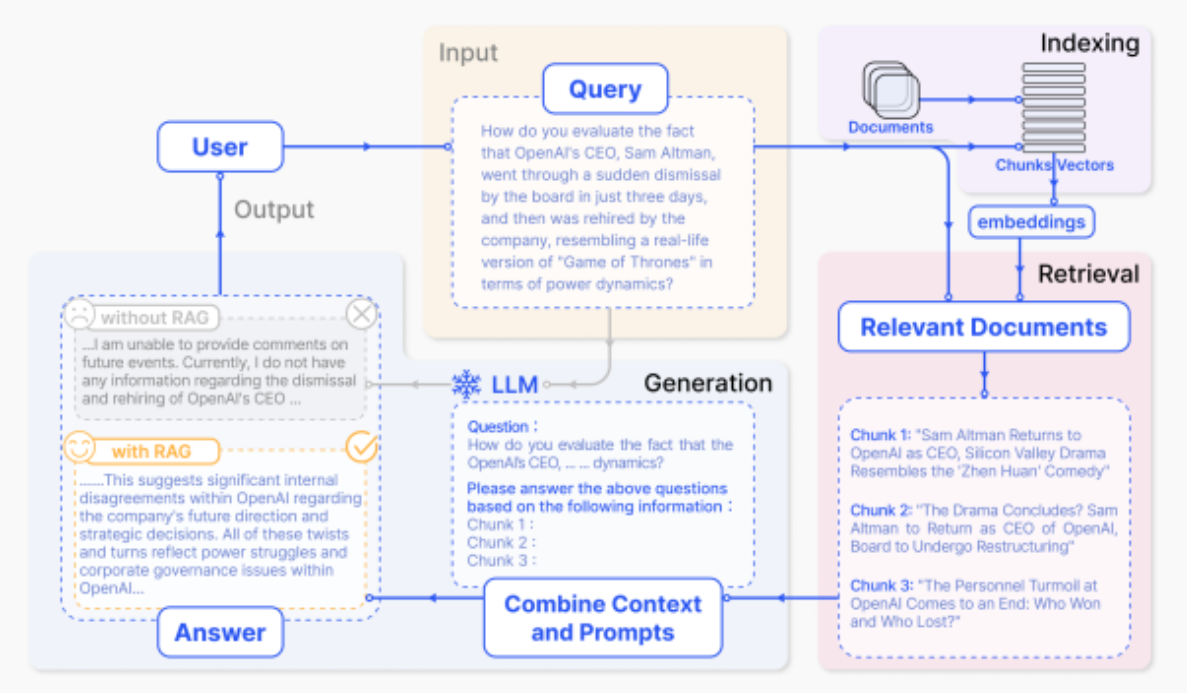

**Все изменения и версии ноутбуков хранятся на репозитории GitHub:
https://github.com/Valyaevgeorgiy/RAG_EdTech_system**

## Импорт библиотек

In [ ]:
!pip install faiss-cpu rank-bm25 transformers torch tiktoken
!pip install spacy && python -m spacy download ru_core_news_sm
!pip install python-docx networkx numpy openpyxl
!pip install -U safetensors accelerate huggingface_hub sentencepiece protobuf
!pip install -U torch torchvision torchaudio

  Using cached faiss_cpu-1.13.2-cp310-abi3-macosx_14_0_arm64.whl.metadata (7.6 kB)
  Using cached rank_bm25-0.2.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached transformers-5.1.0-py3-none-any.whl.metadata (31 kB)
  Using cached torch-2.10.0-2-cp311-none-macosx_11_0_arm64.whl.metadata (31 kB)
  Using cached numpy-2.4.2-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached huggingface_hub-1.4.1-py3-none-any.whl.metadata (13 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached regex-2026.1.15-cp311-cp311-macosx_11_0_arm64.whl.metadata (40 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached typer_slim-0.23.1-py3-none-any.whl.metadata (4.2 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached filelock-3.24.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached fsspec-2026.2.0

In [ ]:
# Скачивание Qwen2.5-3B-Instruct локально
!hf download Qwen/Qwen2.5-3B-Instruct --local-dir ./models/Qwen2.5-3B-Instruct

Fetching 13 files: 100%|████████████████████████| 13/13 [19:20<00:00, 89.30s/it]
Download complete: : 16.1GB [19:20, 103MB/s]              /Users/evexponencial/Downloads/NLP_dipplom/models/YandexGPT-5-Lite-8B-instruct
Download complete: : 16.1GB [19:20, 13.8MB/s]


In [ ]:
!pip uninstall -y faiss-cpu
!pip install -U hnswlib

# !pip uninstall -y hnswlib
# !pip install -U faiss-cpu

In [ ]:
import os
import sys
import re
import json
import uuid
import math
import uuid
import pickle
import zipfile
import difflib
import unicodedata
from enum import Enum
import datetime as dt
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional

from openpyxl import load_workbook
from openpyxl.utils.cell import column_index_from_string
import hashlib
import shutil
from collections import Counter, defaultdict

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from rank_bm25 import BM25Okapi
from transformers.tokenization_utils_base import BatchEncoding
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from transformers import AutoModelForCausalLM
import torch, safetensors, sentencepiece

from docx import Document as Docx
from docx.table import Table
from docx.text.paragraph import Paragraph
from docx.oxml.text.paragraph import CT_P
from docx.oxml.table import CT_Tbl

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

torch.set_num_threads(1)

print(sentencepiece.__version__)
print(sys.executable)
print("safetensors:", safetensors.__version__)

/Users/evexponencial/Downloads/NLP_dipplom/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.2.1
/Users/evexponencial/Downloads/NLP_dipplom/.venv/bin/python
safetensors: 0.7.0


## Выбор устройства запуска и семантических движков

In [ ]:
# Централизованный runtime: выбор устройства, FAISS/HNSW и spaCy
class RuntimeResources:
  def __init__(self, default_spacy_model="ru_core_news_sm"):
    self.default_spacy_model = default_spacy_model
    self.faiss = None
    self.hnswlib = None
    self.spacy_module = None
    self.faiss_available = False
    self.hnsw_available = False
    self._spacy_cache = {}
    self._init_vector_backend()
    self._ensure_spacy_package()

  def _init_vector_backend(self):
    try:
      import faiss as faiss_module
      self.faiss = faiss_module
      self.faiss_available = True
      self.hnsw_available = False
      print("faiss доступен, используем его для векторного поиска")
      return
    except Exception as e:
      self.faiss = None
      print("faiss недоступен, пробуем hnswlib:", type(e).__name__, e)

    try:
      import hnswlib as hnswlib_module
      self.hnswlib = hnswlib_module
      self.hnsw_available = True
      print("используем hnswlib для векторного поиска")
    except Exception as e:
      self.hnswlib = None
      self.hnsw_available = False
      print("hnswlib тоже недоступен, останется brute-force fallback:", type(e).__name__, e)

  def _ensure_spacy_package(self):
    try:
      import spacy as spacy_module
      import subprocess
      try:
        spacy_module.load(self.default_spacy_model)
        print(f"spaCy модель {self.default_spacy_model} доступна")
      except Exception:
        subprocess.check_call([sys.executable, "-m", "spacy", "download", self.default_spacy_model])
        print(f"{self.default_spacy_model} скачан и доступен")
      self.spacy_module = spacy_module
    except Exception as e:
      self.spacy_module = None
      print("spaCy недоступен:", type(e).__name__, e)

  def pick_device(self, requested_device=None):
    if requested_device:
      return requested_device
    if torch.cuda.is_available():
      return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
      return "mps"
    return "cpu"

  def load_spacy(self, model_name=None):
    model_name = model_name or self.default_spacy_model
    if self.spacy_module is None:
      return None
    if model_name in self._spacy_cache:
      return self._spacy_cache[model_name]
    try:
      nlp = self.spacy_module.load(model_name)
      self._spacy_cache[model_name] = nlp
      return nlp
    except Exception:
      return None


runtime = RuntimeResources()
faiss = runtime.faiss
hnswlib = runtime.hnswlib
spacy = runtime.spacy_module
FAISS_AVAILABLE = runtime.faiss_available
HNSW_AVAILABLE = runtime.hnsw_available

print(FAISS_AVAILABLE, HNSW_AVAILABLE)

faiss недоступен, пробуем hnswlib: ModuleNotFoundError No module named 'faiss'
используем hnswlib для векторного поиска
spaCy модель ru_core_news_sm доступна
False True


## Парсинг датасета

### Инициализация датаклассов

In [ ]:
@dataclass
class Chunk:
  id: str
  doc_id: str
  title: str
  text: str
  meta: Dict[str, Any] = field(default_factory=dict)

@dataclass
class RAGConfig:
  # chunking
  max_chunk_chars: int = 1400
  chunk_overlap_chars: int = 150 # overlap для параграфов (не таблиц)
  table_row_block_size: int = 15
  keep_table_header: bool = True
  chunk_drop_leading_fragments: bool = True
  chunk_fragment_min_token_len: int = 5

  # embeddings / retrieval
  embed_model_name: str = "intfloat/multilingual-e5-base"
  faiss_batch_size: int = 32
  hybrid_rrf_k: int = 60

  # graph/entities
  spacy_model: str = "ru_core_news_sm"
  entity_min_df: int = 2
  entity_max_df_ratio: float = 0.16 # умеренно ослабляем фильтр слишком частых сущностей
  max_entities_per_chunk: int = 14 # слегка расширяем набор сущностей на чанк
  entity_min_len: int = 3

  graph_enabled: bool = True
  graph_neighbors_per_seed: int = 5
  graph_max_seed_entities: int = 8
  graph_max_extra_chunks: int = 3
  graph_max_degree: int = 120
  graph_visual_max_nodes: int = 28
  graph_label_max_len: int = 20

  graph_use_table_entities: bool = False
  graph_edge_min_cooc: int = 2
  graph_edge_min_score: float = 0.08
  graph_max_pairs_per_chunk: int = 36
  graph_hub_degree_prune: int = 260
  graph_use_lemma_entities: bool = True
  graph_drop_noise_isolates: bool = True
  graph_drop_all_isolates: bool = True

  # scoring tweaks
  boost_tables: bool = False
  table_boost: float = 0.25

  # logging
  log_jsonl_path: Optional[str] = None

# Logger
class JSONLLogger:
  def __init__(self, path):
    self.path = path
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)

  def log(self, record):
    record = dict(record)
    record["ts"] = dt.datetime.now().isoformat()
    with open(self.path, "a", encoding="utf-8") as f:
      f.write(json.dumps(record, ensure_ascii=False) + "\n")

In [ ]:
_WORD_RE = re.compile(r"[A-Za-zА-Яа-яЁё0-9]+(?:[-_][A-Za-zА-Яа-яЁё0-9]+)*", re.UNICODE)
_COMP_CODE_RE = re.compile(r"\b(УК|ОПК|ПК)\s*-\s*\d+(?:\.\d+)?\b", re.IGNORECASE)

RU_STOPWORDS = {
  # базовые русские стоп-слова (укороченный список; можно расширять)
  "и","в","во","на","по","с","со","к","ко","о","об","от","до","из","за","у","для","при","это","то","а","но",
  "как","так","же","не","ни","или","ли","бы","что","чтобы","который","которая","которые","которых","этот","эта",
  "эти","этих","тот","та","те","тех","его","ее","их","мы","вы","они","я","ты","он","она","оно",
  "будет","есть","является","являются","являться","может","могут","должен","должны","следует","необходимо",
  "данных","данные","работа","работы","обучение","обучения","таблица","таблицы","рисунок","рисунки","раздел","разделы",
  "цель","цели","задача","задачи","тема","темы","дисциплина","дисциплины","программа","программы"
}
EN_STOPWORDS = {"the","a","an","and","or","to","of","in","on","for","is","are","was","were","be","been","with","by"}

GENERIC_ENTITY_PATTERNS = [
  re.compile(r"^перечень(?:\s+\w+){0,3}$", re.IGNORECASE),
  re.compile(r"^наименование(?:\s+\w+){0,3}$", re.IGNORECASE),
  re.compile(r"^формы?(?:\s+\w+){0,4}$", re.IGNORECASE),
  re.compile(r"^код компетенции(?:\s+\w+){0,3}$", re.IGNORECASE),
  re.compile(r"^индикаторы?(?:\s+\w+){0,4}$", re.IGNORECASE),
  re.compile(r"^результаты?(?:\s+\w+){0,4}$", re.IGNORECASE),
  re.compile(r"^дата обращения$", re.IGNORECASE),
  re.compile(r"^url$", re.IGNORECASE),
  re.compile(r"^эбс$", re.IGNORECASE),
  re.compile(r"^перечень вопросов$", re.IGNORECASE),
  re.compile(r"^наименование тем$", re.IGNORECASE),
  re.compile(r"^фамилия\s+и\.?о\.?$", re.IGNORECASE),
  re.compile(r"^аннотация$", re.IGNORECASE),
  re.compile(r"^(гиа|гэк|иоп)$", re.IGNORECASE),
]

GENERIC_ENTITY_TOKENS = {
  "наименование", "перечень", "форма", "формы", "индикатор", "индикаторы",
  "результат", "результаты", "код", "компетенция", "компетенции",
  "тема", "темы", "вопрос", "вопросы", "дата", "обращение", "url",
  "эбс", "юрайт", "лань", "ресурс", "ресурсы", "таблица", "строка",
  "всего", "итого", "освоение", "дисциплина", "дисциплины",
  "знание", "умение", "навык", "владение", "оценка", "способность",
  "направление", "аннотация", "фамилия", "гиа", "гэк", "иоп"
}

DOMAIN_STOPWORDS = {
  # шумные доменные слова — часто встречаются и мало помогают графу
  "студент","студенты","обучающийся","обучающиеся","семестр","час","часов","зачет","экзамен",
  "лекция","лекции","практика","практические","самостоятельная","работа","работы",
  "наименование","перечень","формы","индикаторы","результаты","компетенции","дата",
  "обращения","url","эбс","тема","темы","вопрос","вопросы","код",
  "знание","умение","навык","владение","оценка","способность","направление",
  "аннотация","фамилия","гиа","гэк","иоп"
}

def normalize_text(text):
  text = text.replace("\u00a0", " ")
  text = re.sub(r"[ \t]+", " ", text)
  text = re.sub(r"\n{3,}", "\n\n", text)
  return text.strip()

def tokenize(text):
  tokens = [t.lower() for t in _WORD_RE.findall(text)]
  return tokens

def first_token(text):
  m = _WORD_RE.search(text or "")
  return m.group(0).lower() if m else ""

_BOUNDARY_RE = re.compile(r"""[\s\n\r\t,.;:!?()\[\]{}<>/\\|"\'«»]+""")

CLIPPED_TOKEN_STEMS = (
  "ограм", "грамм", "дготов", "зучен", "азлич", "ветств", "полнитель",
  "дстав", "бучен", "остоян", "ежден", "тронно", "иотеч", "ознакомл",
  "ленност", "льтант", "едствен", "дствен", "посредств", "ования",
  "нного", "сного", "ункц", "работок", "iblioclub", "cholarship"
)

def _is_wordish_char(ch):
  return ch.isalnum() or ch in {"_", "-"}

def looks_like_clipped_token(token):
  token = normalize_text(str(token or "")).strip("-–— ").lower()
  if not token:
    return False
  if len(token) < 5:
    return False
  if _COMP_CODE_RE.fullmatch(token):
    return False
  if any(ch.isdigit() for ch in token):
    return False
  if not re.fullmatch(r"[a-zа-яё-]+", token):
    return False
  if token in RU_STOPWORDS or token in EN_STOPWORDS or token in DOMAIN_STOPWORDS:
    return False
  return any(token.startswith(stem) for stem in CLIPPED_TOKEN_STEMS)

def strip_leading_fragment(text, min_remaining_chars=40):
  text = normalize_text(text or "")
  if not text:
    return text

  work = text
  for _ in range(2):
    m = _WORD_RE.match(work)
    if not m:
      break
    tok = m.group(0)
    if not looks_like_clipped_token(tok):
      break
    rest = work[m.end():].lstrip(" ,.;:!?-–—)\n\t")
    if len(rest) < min_remaining_chars:
      break
    work = rest

  return normalize_text(work)

def safe_overlap_suffix(text, max_chars):
  text = normalize_text(text or "")
  if not text or max_chars <= 0:
    return ""
  if len(text) <= max_chars:
    return text

  start = max(0, len(text) - max_chars)
  if start > 0 and _is_wordish_char(text[start - 1]) and _is_wordish_char(text[start]):
    m = _BOUNDARY_RE.search(text[start:])
    if not m:
      return ""
    start = start + m.end()

  return text[start:].lstrip()

def _advance_start_to_safe_boundary(text, start):
  n = len(text)
  start = max(0, min(start, n))
  while start < n and text[start].isspace():
    start += 1

  if 0 < start < n and _is_wordish_char(text[start - 1]) and _is_wordish_char(text[start]):
    m = _BOUNDARY_RE.search(text[start:])
    if m:
      start = start + m.end()

  while start < n and text[start].isspace():
    start += 1

  if start < n:
    frag = _WORD_RE.match(text[start:])
    if frag and looks_like_clipped_token(frag.group(0)):
      cand = start + frag.end()
      while cand < n and text[cand] in " ,.;:!?-–—)\n\t":
        cand += 1
      if cand < n:
        start = cand

  return start

def split_text_word_safe(text, max_chars, overlap_chars=0):
  text = normalize_text(text or "")
  if not text:
    return []
  if max_chars <= 0 or len(text) <= max_chars:
    piece = strip_leading_fragment(text)
    return [piece] if piece else []

  pieces = []
  start = 0
  n = len(text)

  while start < n:
    start = _advance_start_to_safe_boundary(text, start)
    if start >= n:
      break

    target_end = min(start + max_chars, n)
    if target_end >= n:
      piece = strip_leading_fragment(text[start:n])
      if piece:
        pieces.append(piece)
      break

    min_cut = max(start + int(max_chars * 0.60), start + 1)
    window = text[min_cut:target_end]
    cut = None

    for m in _BOUNDARY_RE.finditer(window):
      cut = min_cut + m.start()

    if cut is None:
      extra_end = min(n, target_end + 48)
      m = _BOUNDARY_RE.search(text[target_end:extra_end])
      if m:
        cut = target_end + m.start()
      else:
        cut = target_end

    piece = strip_leading_fragment(text[start:cut])
    if piece:
      pieces.append(piece)

    if cut >= n:
      break

    overlap = safe_overlap_suffix(piece, overlap_chars)
    next_start = cut - len(overlap) if overlap else cut
    next_start = max(next_start, start + 1)
    next_start = _advance_start_to_safe_boundary(text, next_start)

    if next_start <= start:
      next_start = cut

    start = next_start

  return pieces

### Парсер документов

In [ ]:
# Парсер структуры DOCX: заголовки, оглавление, порядок блоков
class DocxStructureParser:
  DISC_HEADINGS = [
    '1. Наименование дисциплины',
    '2. Перечень планируемых результатов освоения образовательной программы (перечень компетенций) с указанием индикаторов их достижения и планируемых результатов обучения по дисциплине',
    '3. Место дисциплины в структуре образовательной программы',
    '4. Объем дисциплины (модуля) в зачетных единицах и в академических часах с выделением объема аудиторной (лекции, семинары) и самостоятельной работы обучающихся',
    '5. Содержание дисциплины, структурированное по темам (разделам) дисциплины с указанием их объемов (в академических часах) и видов учебных занятий',
    '5.1. Содержание дисциплины',
    '5.2. Учебно–тематический план',
    '5.3. Содержание семинаров, практических занятий',
    '6. Перечень учебно-методического обеспечения для самостоятельной работы обучающихся по дисциплине',
    '6.1. Перечень вопросов, отводимых на самостоятельное освоение дисциплины, формы внеаудиторной самостоятельной работы',
    '6.2. Перечень вопросов, заданий, тем для подготовки к текущему контролю',
    '7. Фонд оценочных средств для проведения промежуточной аттестации обучающихся по дисциплине',
    '8. Перечень основной и дополнительной учебной литературы, необходимой для освоения дисциплины',
    '9. Перечень ресурсов информационно-телекоммуникационной сети «Интернет», необходимых для освоения дисциплины',
    '10. Методические указания для обучающихся по освоению дисциплины',
    '11. Перечень информационных технологий, используемых при осуществлении образовательного процесса по дисциплине, включая перечень необходимого программного обеспечения и информационных справочных систем',
    '12. Описание материально-технической базы, необходимой для осуществления образовательного процесса по дисциплине'
  ]

  PRACTICE_HEADINGS = [
    '1. Наименование вида и типов практики, способа и формы (форм) ее проведения',
    '2. Цели и задачи практики',
    '3. Перечень планируемых результатов освоения образовательной программы (перечень компетенций) с указанием индикаторов их достижения и планируемых результатов обучения при прохождении практики',
    '4. Место практики в структуре образовательной программы',
    '5. Объём практики в зачетных единицах и ее продолжительностьв неделях либо в академических часах',
    '6. Содержание практики',
    '7. Формы отчетности  по практике',
    '8. Фонд оценочных средств для проведения промежуточной аттестации обучающихся по практике',
    '9. Перечень учебной литературы и ресурсов сети «Интернет», необходимых для проведения практики',
    '10. Перечень информационных технологий, используемых при проведении практики, включая перечень необходимого программного обеспечения и информационных справочных систем',
    '11. Описание материально- технической базы, необходимой для проведения практики'
  ]

  HEADING_ANCHORS = [
    "наименование дисциплины",
    "перечень планируемых результатов",
    "место дисциплины",
    "объем дисциплины",
    "трудоемк",
    "содержание дисциплины",
    "учебно-тематический план",
    "содержание семинаров",
    "практических занятий",
    "фонд оценочных средств",
    "перечень основной и дополнительной учебной литературы",
    "перечень ресурсов информационно-телекоммуникационной сети",
    "перечень ресурсов сети интернет",
    "перечень информационных технологий",
    "описание материально-технической базы",
    "место практики",
    "объем практики",
    "содержание практики",
    "формы отчетности",
  ]

  NUM_HEADING_RE = re.compile(r"^\s*(\d{1,2})(?:\.(\d{1,2}))?(?:\.(\d{1,2}))?\.(?:\s+|$)")
  NUM_HEADING_SOFT_RE = re.compile(r"^\s*(\d{1,2})\.(\d{1,2})\s+(.+)$")

  def __init__(self):
    self.disc_headings_n = {self.normalize_heading_text(x) for x in self.DISC_HEADINGS}
    self.practice_headings_n = {self.normalize_heading_text(x) for x in self.PRACTICE_HEADINGS}

  def iter_block_items(self, doc):
    parent = doc.element.body
    for child in parent.iterchildren():
      if isinstance(child, CT_P):
        yield ("p", Paragraph(child, doc))
      elif isinstance(child, CT_Tbl):
        yield ("t", Table(child, doc))

  def style_name(self, paragraph):
    try:
      return (paragraph.style.name or "")
    except Exception:
      return ""

  def is_style_toc(self, paragraph):
    return self.style_name(paragraph).strip().lower().startswith("toc")

  def is_heading_paragraph(self, paragraph):
    name_l = self.style_name(paragraph).strip().lower()
    return name_l.startswith("heading") or name_l.startswith("заголовок")

  def looks_like_toc_line(self, text):
    t = (text or "").strip()
    if not t:
      return False
    if re.search(r"((?:\.){3,}|(?:…){3,}|(?:·){3,})\s*\d+\s*$", t):
      return True
    if re.search(r"\s\d+\s*$", t) and re.search(r"((?:\.){5,}|(?:…){5,})", t):
      return True
    return False

  def normalize_heading_text(self, text):
    t = (text or "").strip()
    t = t.replace("ё", "е").replace("Ё", "Е")
    t = unicodedata.normalize("NFKC", t)
    t = re.sub(r"\s+", " ", t).strip().lower()
    t = t.replace("–", "-").replace("—", "-")
    return t.strip(" \t\n\r,;:.'«»")

  def fix_heading_candidate(self, text):
    t = (text or "").strip()
    if not t:
      return t
    t = unicodedata.normalize("NFKC", t)
    t = t.replace("–", "-").replace("—", "-").replace("−", "-").replace("‑", "-")
    t = re.sub(
      r"^\s*(\d{1,2})(?:\.(\d{1,2}))?(?:\.(\d{1,2}))?\)\s*",
      lambda m: (
        m.group(1)
        + (("." + m.group(2)) if m.group(2) else "")
        + (("." + m.group(3)) if m.group(3) else "")
        + ". "
      ),
      t
    )
    t = re.sub(r"^\s*(\d{1,2})\s*-\s+", r"\1. ", t)
    t = re.sub(r"^(\s*\d{1,2}(?:\.\d{1,2}){0,2}\.)(?=\S)", r"\1 ", t)
    return t.strip()

  def detect_heading(self, text, p_style_is_heading, doc_kind, current_top_section=""):
    txt = (text or "").strip()
    if not txt:
      return (False, None, None, None)

    if self.looks_like_toc_line(txt):
      return (False, None, None, None)

    normalized = self.normalize_heading_text(txt)
    allow = self.practice_headings_n if doc_kind == "practice" else self.disc_headings_n

    if p_style_is_heading:
      if normalized == "оглавление":
        return (True, txt, 1, None)
      return (True, txt, 1, None)

    match = self.NUM_HEADING_RE.match(txt)
    if match:
      top = int(match.group(1))
      if current_top_section in ("8", "9"):
        return (False, None, None, None)

      if normalized in allow or any(anchor in normalized for anchor in self.HEADING_ANCHORS):
        level = 1 + (1 if match.group(2) else 0) + (1 if match.group(3) else 0)
        return (True, txt, level, top)

      if 1 <= top <= 12 and any(anchor in normalized for anchor in self.HEADING_ANCHORS):
        level = 1 + (1 if match.group(2) else 0) + (1 if match.group(3) else 0)
        return (True, txt, level, top)

      return (False, None, None, None)

    match = self.NUM_HEADING_SOFT_RE.match(txt)
    if match:
      top = int(match.group(1))
      if current_top_section in ("8", "9"):
        return (False, None, None, None)
      tail_n = self.normalize_heading_text(match.group(0))
      if tail_n in allow or any(anchor in tail_n for anchor in self.HEADING_ANCHORS):
        return (True, txt, 2, top)
      return (False, None, None, None)

    if normalized in allow or any(anchor in normalized for anchor in self.HEADING_ANCHORS):
      return (True, txt, 1, None)

    return (False, None, None, None)

In [ ]:
class TableBlockParser:
  CANON_DISC_VOL = "4. Объем дисциплины (модуля) в зачетных единицах и в академических часах с выделением объема аудиторной (лекции, семинары) и самостоятельной работы обучающихся"
  CANON_PRAC_VOL = "5. Объём практики в зачетных единицах и ее продолжительностьв неделях либо в академических часах"

  def __init__(self, cfg):
    self.cfg = cfg

  def table_to_rows(self, table):
    rows = []
    for row in table.rows:
      values = []
      for cell in row.cells:
        values.append(normalize_text(cell.text or ""))
      if any(values):
        rows.append(values)
    return rows

  def format_table_block(self, rows):
    return "\n".join(["\t".join(row).strip() for row in rows if any(row)]).strip()

  def detect_table_type(self, table_text):
    t = (table_text or "").lower().replace("ё", "е")
    if ("общая трудоемк" in t or "общая трудоёмк" in t) and ("самостоятельная работа" in t) and ("контактная работа" in t or "аудиторные занятия" in t):
      return "volume"
    return None

### Парсер метаданных

In [ ]:
# Извлечение doc-level метаданных из титульного листа
@dataclass
class DocMeta:
  doc_id: str
  doc_kind: str
  practice_kind: str = ""
  discipline_name: str = ""
  direction_code: str = ""
  direction_name: str = ""
  op_name: str = ""
  doc_year: int = 0

class DocMetaExtractor:
  DIR_LINE_RE = re.compile(r"\b(\d{2}\.\d{2}\.\d{2})\s*[-—–−]\s*([^\n]+)", re.I)
  OP_RE = re.compile(r"\bОП\s*[«\"'](.{2,180}?)[»\"']", re.I)
  PROG_FOCUS_RE = re.compile(r"направленност[ьи]\s+(?:образовательной\s+)?программы\s*:\s*(.*)$", re.I)
  MOSCOW_YEAR_RE = re.compile(r"\bмосква\b[^\d]{0,20}\b((?:19|20)\d{2})\b", re.I)

  def collect_head_text(self, doc, max_paragraphs=120, max_tables=4):
    out = []
    for paragraph in doc.paragraphs[:max_paragraphs]:
      text = (paragraph.text or "").strip()
      if text:
        out.append(text)
    for table in doc.tables[:max_tables]:
      for row in table.rows:
        for cell in row.cells:
          text = (cell.text or "").strip()
          if text:
            out.append(text)
    return out

  def extract(self, doc, doc_id):
    lines = self.collect_head_text(doc, max_paragraphs=140, max_tables=6)
    head = "\n".join(lines)
    meta = DocMeta(doc_id=doc_id, doc_kind="discipline")

    low = head.lower().replace("ё", "е")
    if re.search(r"\bпрограмма\s+(?:учебн\w*|производственн\w*)\s+практик", low):
      meta.doc_kind = "practice"
      meta.practice_kind = "учебная" if "учебн" in low else ("производственная" if "производствен" in low else "")
    elif re.search(r"\bпрограмма\s+практик", low) or re.search(r"\bпо\s+практик", low):
      meta.doc_kind = "practice"
      if re.search(r"учебн\w*\s+практик", low):
        meta.practice_kind = "учебная"
      elif re.search(r"производственн\w*\s+практик", low):
        meta.practice_kind = "производственная"

    m = self.DIR_LINE_RE.search(head)
    if m:
      meta.direction_code = (m.group(1) or "").strip()
      direction_name = (m.group(2) or "").strip()
      direction_name = direction_name.split(",")[0].strip(" \t\n\r,;:.'«»")
      meta.direction_name = direction_name

    if not meta.direction_code or not meta.direction_name:
      code_m = re.search(r"\b(\d{2}\.\d{2}\.\d{2})\b", head)
      if code_m:
        meta.direction_code = meta.direction_code or code_m.group(1)
        for i, line in enumerate(lines[:160]):
          if meta.direction_code in line:
            m_inline = re.search(rf"\b{re.escape(meta.direction_code)}\b\s*[-—–−]\s*(.+)$", line)
            if m_inline:
              direction_name = m_inline.group(1).strip().split(",")[0].strip(" \t\n\r,;:.'«»")
              if direction_name:
                meta.direction_name = direction_name
                break
            for j in range(i + 1, min(i + 5, len(lines))):
              candidate = (lines[j] or "").strip()
              if re.search(r"\b(москва|г\.|год)\b", candidate.lower()):
                continue
              if re.search(r"\d{2}\.\d{2}\.\d{2}", candidate):
                continue
              if len(candidate) >= 4:
                meta.direction_name = candidate.split(",")[0].strip(" \t\n\r,;:.'«»")
                break
            if meta.direction_name:
              break

    m = self.OP_RE.search(head)
    if m:
      meta.op_name = (m.group(1) or "").strip().strip(" \t\n\r,;:.'«»")
    else:
      for i, line in enumerate(lines[:120]):
        match = self.PROG_FOCUS_RE.search(line)
        if not match:
          continue
        tail = match.group(1).strip()
        m2 = re.search(r"[«\"'](.{2,180}?)[»\"']", tail)
        if m2:
          meta.op_name = m2.group(1).strip().strip(" \t\n\r,;:.'«»")
          break
        for j in range(i + 1, min(i + 6, len(lines))):
          candidate = (lines[j] or "").strip()
          m3 = re.search(r"[«\"'](.{2,180}?)[»\"']", candidate)
          if m3:
            meta.op_name = m3.group(1).strip().strip(" \t\n\r,;:.'«»")
            break
        break

    m = self.MOSCOW_YEAR_RE.search(head)
    if m:
      try:
        meta.doc_year = int(m.group(1))
      except Exception:
        meta.doc_year = 0
    else:
      m2 = re.search(r"\b((?:19|20)\d{2})\b", head)
      if m2:
        try:
          meta.doc_year = int(m2.group(1))
        except Exception:
          meta.doc_year = 0

    if meta.doc_kind == "discipline":
      idx = None
      for i, line in enumerate(lines[:80]):
        if re.search(r"рабочая\s+программа\s+дисциплины", line, re.I):
          idx = i
          break
      if idx is not None:
        for j in range(max(0, idx - 8), idx)[::-1]:
          candidate = (lines[j] or "").strip()
          if len(candidate) >= 4 and not re.search(r"(утверждаю|согласовано|протокол|федеральное|министерств|департамент)", candidate, re.I):
            meta.discipline_name = candidate.strip(" \t\n\r,;:.'«»")
            break

    if meta.doc_kind == "practice" and not meta.discipline_name:
      for line in lines[:60]:
        if re.search(r"\bпрактик", line, re.I) and len(line) < 120:
          meta.discipline_name = line.strip(" \t\n\r,;:.'«»")
          break

    return meta

In [ ]:
class DocxDocumentParser:
  def __init__(self, cfg, structure_parser=None, table_parser=None, meta_extractor=None):
    self.cfg = cfg
    self.structure = structure_parser or DocxStructureParser()
    self.table_parser = table_parser or TableBlockParser(cfg)
    self.meta_extractor = meta_extractor or DocMetaExtractor()

  def parse(self, path):
    doc = Docx(path)
    doc_id = os.path.basename(path)

    doc_meta = self.meta_extractor.extract(doc, doc_id=doc_id)
    doc_meta_flat = {
      "doc_kind": doc_meta.doc_kind,
      "practice_kind": doc_meta.practice_kind,
      "discipline_name": doc_meta.discipline_name,
      "direction_code": doc_meta.direction_code,
      "direction_name": doc_meta.direction_name,
      "op_name": doc_meta.op_name,
      "doc_year": doc_meta.doc_year,
    }

    chunks = []
    section_stack = []
    current_title = "Документ"
    current_top_section = ""
    started = False
    preface_blocks = 0
    max_preface_blocks = 240
    skip_section10 = False
    paragraph_buf = []
    order = 0
    last_nonempty_para = ""

    def _emit_text_chunk(text_piece):
      nonlocal order
      text_piece = normalize_text(text_piece or "")
      if getattr(self.cfg, "chunk_drop_leading_fragments", True):
        text_piece = strip_leading_fragment(
          text_piece,
          min_remaining_chars=max(30, int(self.cfg.max_chunk_chars * 0.15))
        )
      if not text_piece:
        return
      chunks.append(Chunk(
        id=str(uuid.uuid4()),
        doc_id=doc_id,
        title=current_title,
        text=text_piece,
        meta={
          "path": os.path.basename(path),
          "section_path": list(section_stack),
          "order": order,
          "table": False,
          **doc_meta_flat
        }
      ))
      order += 1

    def flush_paragraph_buffer():
      nonlocal paragraph_buf, order
      if not paragraph_buf:
        return
      raw = normalize_text("\n".join(paragraph_buf))
      if not raw:
        paragraph_buf = []
        return

      pieces = split_text_word_safe(
        raw,
        max_chars=self.cfg.max_chunk_chars,
        overlap_chars=self.cfg.chunk_overlap_chars,
      ) or [raw]

      for piece in pieces:
        _emit_text_chunk(piece)

      tail = safe_overlap_suffix(pieces[-1], self.cfg.chunk_overlap_chars) if self.cfg.chunk_overlap_chars > 0 else ""
      paragraph_buf = [tail] if tail else []

    def add_paragraph_text(text):
      nonlocal paragraph_buf
      if not text:
        return
      paragraph_buf.append(text)
      if sum(len(part) for part in paragraph_buf) >= self.cfg.max_chunk_chars:
        flush_paragraph_buffer()

    def add_table_chunks(table):
      nonlocal order, current_title, section_stack
      rows = self.table_parser.table_to_rows(table)
      if not rows:
        return

      n_rows = len(rows)
      n_cols = max((len(r) for r in rows), default=0)
      caption = ""
      if last_nonempty_para and re.search(r"\bтаблиц", last_nonempty_para.lower()):
        caption = last_nonempty_para

      block_size = self.cfg.table_row_block_size
      header = rows[0] if (self.cfg.keep_table_header and rows) else None

      for start in range(0, n_rows, block_size):
        part = rows[start:start + block_size]
        if header is not None and start > 0:
          part = [header] + part

        table_text = self.table_parser.format_table_block(part)
        if not table_text:
          continue

        prefix = []
        if caption:
          prefix.append(caption)
        prefix.append(f"Таблица ({n_rows}x{n_cols}), строки {start + 1}-{min(start + block_size, n_rows)}:")
        full = normalize_text("\n\n".join(prefix) + "\n" + table_text)

        meta = {
          "path": os.path.basename(path),
          "section_path": list(section_stack),
          "order": order,
          "table": True,
          "rows": n_rows,
          "cols": n_cols,
          "row_block": [start, min(start + block_size, n_rows)],
          **doc_meta_flat
        }

        table_type = self.table_parser.detect_table_type(full)
        if table_type == "volume":
          meta["table_type"] = "volume"
          forced = self.table_parser.CANON_PRAC_VOL if doc_meta.doc_kind == "practice" else self.table_parser.CANON_DISC_VOL
          meta["forced_section"] = True
          meta["section_path"] = [forced]
          title = forced + " — таблица"
        else:
          title = f"{current_title} — таблица"

        chunks.append(Chunk(
          id=str(uuid.uuid4()),
          doc_id=doc_id,
          title=title,
          text=full,
          meta=meta
        ))
        order += 1

    in_toc = False

    for kind, obj in self.structure.iter_block_items(doc):
      if kind == "p":
        paragraph = obj
        text = normalize_text(paragraph.text or "")
        heading_candidate = self.structure.fix_heading_candidate(text)
        if text:
          last_nonempty_para = text

        if self.structure.is_style_toc(paragraph) or self.structure.looks_like_toc_line(text):
          continue

        if self.structure.normalize_heading_text(text) == "оглавление":
          in_toc = True
          continue

        if in_toc:
          is_heading, title, level, top = self.structure.detect_heading(
            heading_candidate,
            p_style_is_heading=self.structure.is_heading_paragraph(paragraph),
            doc_kind=doc_meta.doc_kind,
            current_top_section=current_top_section
          )
          if is_heading and top is not None:
            in_toc = False
          else:
            continue

        is_heading, title, level, top = self.structure.detect_heading(
          heading_candidate,
          p_style_is_heading=self.structure.is_heading_paragraph(paragraph),
          doc_kind=doc_meta.doc_kind,
          current_top_section=current_top_section
        )

        if is_heading and title:
          flush_paragraph_buffer()

          if top is not None:
            current_top_section = str(top)
          if not started:
            started = True

          normalized_title = self.structure.normalize_heading_text(title)
          if doc_meta.doc_kind == "discipline" and (top == 10 or "методические указания" in normalized_title):
            skip_section10 = True
            continue

          if skip_section10 and top is not None and top >= 11:
            skip_section10 = False
          if skip_section10:
            continue

          level = level or 1
          if level <= 1:
            section_stack = [title]
          else:
            section_stack = section_stack[:level - 1] + [title]
          current_title = title
          continue

        if skip_section10:
          continue

        if not started:
          preface_blocks += 1
          if preface_blocks < max_preface_blocks:
            continue
          started = True

        if text:
          add_paragraph_text(text)

      elif kind == "t":
        if skip_section10 or in_toc or not started:
          continue
        flush_paragraph_buffer()
        add_table_chunks(obj)

    flush_paragraph_buffer()
    chunks = [chunk for chunk in chunks if chunk.text and chunk.text.strip()]
    return chunks, doc_meta

### Загрузчик документов

In [ ]:
class DocumentCorpusLoader:
  def __init__(self, cfg, document_parser=None):
    self.cfg = cfg
    self.document_parser = document_parser or DocxDocumentParser(cfg)

  def load(self, paths):
    chunks: List[Chunk] = []
    docs_meta: Dict[str, Dict[str, Any]] = {}

    for path in paths:
      doc_id = os.path.basename(path)
      try:
        doc_chunks, meta = self.document_parser.parse(path)
        chunks.extend(doc_chunks)
        docs_meta[doc_id] = {
          "doc_id": doc_id,
          "doc_kind": meta.doc_kind,
          "practice_kind": meta.practice_kind,
          "discipline_name": meta.discipline_name,
          "direction_code": meta.direction_code,
          "direction_name": meta.direction_name,
          "op_name": meta.op_name,
          "doc_year": meta.doc_year,
        }
      except Exception as e:
        try:
          doc = Docx(path)
          raw = "\n".join([normalize_text(x.text or "") for x in doc.paragraphs if normalize_text(x.text or "")])
          raw = normalize_text(raw)
          if raw:
            chunks.append(Chunk(
              id=str(uuid.uuid4()),
              doc_id=doc_id,
              title="Документ",
              text=raw,
              meta={
                "path": doc_id,
                "section_path": [],
                "order": 0,
                "table": False,
                "fallback": True,
                "doc_kind": "discipline",
                "practice_kind": "",
                "discipline_name": "",
                "direction_code": "",
                "direction_name": "",
                "op_name": "",
                "doc_year": 0
              }
            ))
            docs_meta.setdefault(doc_id, {"doc_id": doc_id, "doc_kind": "discipline"})
        except Exception:
          raise RuntimeError(f"Ошибка парсинга {path}: {e}") from e

    return chunks, docs_meta

## Эмбеддинг чанков

In [ ]:
# Embeddings (E5-style)
def _mean_pool(last_hidden, attention_mask):
  mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
  summed = torch.sum(last_hidden * mask, dim=1)
  denom = torch.clamp(mask.sum(dim=1), min=1e-9)
  return summed / denom

class Embedder:
  def __init__(self, model_name, device, local_files_only=True, runtime_resources=None):
    self.model_name = model_name
    self.runtime = runtime_resources or runtime
    self.device = self.runtime.pick_device(device)
    self.local_files_only = bool(local_files_only)

    self.tokenizer = AutoTokenizer.from_pretrained(
      model_name,
      trust_remote_code=False,
      local_files_only=self.local_files_only,
      use_fast=True
    )
    self.model = AutoModel.from_pretrained(
      model_name,
      torch_dtype=(torch.float16 if self.device in ("cuda", "mps") else torch.float32),
      trust_remote_code=False,
      local_files_only=self.local_files_only,
    )
    self.model.eval().to(self.device)

  def encode(self, texts, batch_size=32, is_query=False):
    if isinstance(texts, str):
      texts = [texts]
    pref = "query: " if is_query else "passage: "
    data = [pref + normalize_text(t) for t in texts]
    all_vecs = []

    with torch.inference_mode():
      for i in range(0, len(data), batch_size):
        batch = data[i:i + batch_size]
        enc = self.tokenizer(
          batch,
          padding=True,
          truncation=True,
          max_length=512,
          return_tensors="pt"
        )
        enc = {k: v.to(self.device) for k, v in enc.items()}
        out = self.model(**enc)
        vec = _mean_pool(out.last_hidden_state, enc["attention_mask"])
        vec = torch.nn.functional.normalize(vec, p=2, dim=1)
        all_vecs.append(vec.detach().cpu().numpy().astype("float32"))

    return np.vstack(all_vecs)

## Индексы эмбеддингов

In [ ]:
class IndexTextBuilder:
  def build(self, chunk):
    meta = getattr(chunk, "meta", {}) or {}

    doc_id = getattr(chunk, "doc_id", "") or meta.get("path", "") or ""
    discipline = meta.get("discipline_name", "") or ""
    direction = meta.get("direction_name", "") or ""
    direction_code = meta.get("direction_code", "") or ""
    op_name = meta.get("op_name", "") or ""
    year = meta.get("doc_year", "") or ""
    doc_kind = meta.get("doc_kind", "") or ""
    practice_kind = meta.get("practice_kind", "") or ""

    section_path = meta.get("section_path") or meta.get("section") or ""
    if isinstance(section_path, list):
      section_path = " > ".join(str(x) for x in section_path)
    title = getattr(chunk, "title", "") or meta.get("title", "") or ""
    text = getattr(chunk, "text", "") or ""

    parts = [
      doc_id,
      discipline,
      direction,
      direction_code,
      op_name,
      str(year) if year else "",
      doc_kind,
      practice_kind,
      section_path,
      title,
      text,
    ]
    return normalize_text("\n".join([part for part in parts if part]))

In [ ]:
# Hybrid Index (BM25 + Vector Search) + RRF
class HybridIndex:
  def __init__(self, cfg, runtime_resources=None, text_builder=None, local_files_only=True):
    self.cfg = cfg
    self.runtime = runtime_resources or runtime
    self.text_builder = text_builder or IndexTextBuilder()
    self.local_files_only = bool(local_files_only)
    self.embedder = None

    self.faiss_index = None
    self.hnsw_index = None
    self.emb_matrix = None
    self.vec_backend = None

    self.bm25 = None
    self.chunks = []
    self._tokenized = []

  def build(self, chunks, device=None):
    self.chunks = chunks

    texts = [self.text_builder.build(chunk) for chunk in chunks]
    self._tokenized = [tokenize(text) for text in texts]
    self.bm25 = BM25Okapi(self._tokenized)

    self.embedder = Embedder(
      self.cfg.embed_model_name,
      device=device,
      local_files_only=self.local_files_only,
      runtime_resources=self.runtime
    )
    embs = self.embedder.encode(texts, batch_size=self.cfg.faiss_batch_size, is_query=False)
    dim = int(embs.shape[1])

    if self.runtime.faiss_available and self.runtime.faiss is not None:
      self.vec_backend = "faiss"
      self.faiss_index = self.runtime.faiss.IndexFlatIP(dim)
      self.faiss_index.add(embs)
    elif self.runtime.hnsw_available and self.runtime.hnswlib is not None:
      self.vec_backend = "hnsw"
      index = self.runtime.hnswlib.Index(space="cosine", dim=dim)
      index.init_index(max_elements=len(chunks), ef_construction=200, M=16)
      index.add_items(embs, ids=np.arange(len(chunks)))
      index.set_ef(128)
      self.hnsw_index = index
    else:
      self.vec_backend = "bruteforce"
      self.emb_matrix = embs

  def _vec_search(self, query, k, device=None):
    if self.embedder is None:
      self.embedder = Embedder(
        self.cfg.embed_model_name,
        device=device,
        local_files_only=self.local_files_only,
        runtime_resources=self.runtime
      )
    q_emb = self.embedder.encode([query], batch_size=1, is_query=True)

    if self.vec_backend == "faiss" and self.faiss_index is not None:
      D, I = self.faiss_index.search(q_emb, k)
      return [int(x) for x in I[0].tolist() if int(x) >= 0]

    if self.vec_backend == "hnsw" and self.hnsw_index is not None:
      labels, _distances = self.hnsw_index.knn_query(q_emb, k=k)
      return [int(x) for x in labels[0].tolist() if int(x) >= 0]

    if self.vec_backend == "bruteforce" and self.emb_matrix is not None:
      sims = (self.emb_matrix @ q_emb[0].reshape(-1, 1)).reshape(-1)
      idxs = np.argsort(sims)[::-1][:k]
      return [int(x) for x in idxs.tolist()]

    return []

  def search(self, query, top_k=8, bm25_k=None, vec_k=None, device=None, boost_tables=None, table_boost=None):
    bm25_k = bm25_k or max(50, top_k * 8)
    vec_k = vec_k or max(50, top_k * 8)

    boost_tables = self.cfg.boost_tables if boost_tables is None else bool(boost_tables)
    table_boost = self.cfg.table_boost if table_boost is None else float(table_boost)

    bm25_rank = {}
    vec_rank = {}

    if self.bm25 is not None:
      q_tokens = tokenize(query)
      scores = self.bm25.get_scores(q_tokens)
      idxs = np.argsort(scores)[::-1][:bm25_k]
      for r, idx in enumerate(idxs, start=1):
        bm25_rank[int(idx)] = r

    vec_idxs = self._vec_search(query, vec_k, device=device)
    for r, idx in enumerate(vec_idxs, start=1):
      vec_rank[int(idx)] = r

    fused: Dict[int, float] = {}
    k_rrf = self.cfg.hybrid_rrf_k

    for idx, rank in bm25_rank.items():
      fused[idx] = fused.get(idx, 0.0) + 1.0 / (k_rrf + rank)
    for idx, rank in vec_rank.items():
      fused[idx] = fused.get(idx, 0.0) + 1.0 / (k_rrf + rank)

    if boost_tables and table_boost:
      for idx in list(fused.keys()):
        if self.chunks[idx].meta.get("table"):
          fused[idx] += table_boost

    ranked = sorted(fused.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return [(self.chunks[i], float(score)) for i, score in ranked]

  def save_vector_index(self, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    meta = {"backend": self.vec_backend, "dim": None, "n": len(self.chunks), "embed_model_name": self.cfg.embed_model_name}

    if self.vec_backend == "faiss" and self.faiss_index is not None and self.runtime.faiss is not None:
      self.runtime.faiss.write_index(self.faiss_index, os.path.join(out_dir, "faiss.index"))
      meta["dim"] = int(self.faiss_index.d)
    elif self.vec_backend == "hnsw" and self.hnsw_index is not None:
      self.hnsw_index.save_index(os.path.join(out_dir, "hnsw.index"))
      meta["dim"] = int(self.hnsw_index.dim)
    elif self.vec_backend == "bruteforce" and self.emb_matrix is not None:
      np.save(os.path.join(out_dir, "embeddings.npy"), self.emb_matrix)
      meta["dim"] = int(self.emb_matrix.shape[1])

    with open(os.path.join(out_dir, "vector_meta.json"), "w", encoding="utf-8") as f:
      json.dump(meta, f, ensure_ascii=False, indent=2)

  def load_vector_index(self, in_dir, device=None):
    meta_path = os.path.join(in_dir, "vector_meta.json")
    if not os.path.exists(meta_path):
      return

    with open(meta_path, "r", encoding="utf-8") as f:
      meta = json.load(f)

    backend = meta.get("backend")
    self.vec_backend = backend

    if backend == "faiss" and self.runtime.faiss is not None:
      self.faiss_index = self.runtime.faiss.read_index(os.path.join(in_dir, "faiss.index"))
    elif backend == "hnsw" and self.runtime.hnswlib is not None:
      dim = int(meta.get("dim") or 768)
      index = self.runtime.hnswlib.Index(space="cosine", dim=dim)
      index.load_index(os.path.join(in_dir, "hnsw.index"))
      index.set_ef(128)
      self.hnsw_index = index
    elif backend == "bruteforce":
      emb_path = os.path.join(in_dir, "embeddings.npy")
      if os.path.exists(emb_path):
        self.emb_matrix = np.load(emb_path)

## Граф сущностей

In [ ]:
class EntityGraphService:
  def __init__(self, cfg, runtime_resources=None):
    self.cfg = cfg
    self.runtime = runtime_resources or runtime
    self._nlp = None

  def get_nlp(self):
    if self._nlp is None:
      try:
        self._nlp = self.runtime.load_spacy(self.cfg.spacy_model)
      except Exception:
        self._nlp = None
    return self._nlp

  def _is_short_abbrev(self, text):
    text = (text or "").strip().lower()
    return bool(re.fullmatch(r"[a-zа-я]{2,4}", text))

  def _is_single_english_token(self, text):
    text = (text or "").strip().lower()
    return bool(re.fullmatch(r"[a-z]{2,}", text))

  def _looks_like_clipped_entity(self, text):
    text = normalize_text(str(text or "")).lower()
    if not text:
      return False
    toks = tokenize(text)
    if not toks:
      return False
    return any(looks_like_clipped_token(tok) for tok in toks)

  def _is_noise_isolate(self, ent):
    ent = normalize_text(str(ent or "")).lower()
    if not ent:
      return True
    if re.search(r"\bи\.?о\.?\b", ent):
      return True
    if self._looks_like_clipped_entity(ent):
      return True
    for pat in GENERIC_ENTITY_PATTERNS:
      if pat.fullmatch(ent):
        return True
    toks = tokenize(ent)
    if not toks:
      return True
    if len(toks) == 1:
      t = toks[0]
      if t in GENERIC_ENTITY_TOKENS or t in DOMAIN_STOPWORDS:
        return True
      if self._is_short_abbrev(t):
        return True
      if self._is_single_english_token(t):
        return True
    return False

  def _normalize_entity_text(self, text, nlp=None):
    text = normalize_text(str(text or ""))
    if not text:
      return None

    text = text.replace("ё", "е")
    text = re.sub(r"[\"'`«»“”]", "", text)
    text = re.sub(r"\s*[-–—]\s*", " - ", text)
    text = re.sub(r"\s+", " ", text).strip(" -:;,.")
    if not text:
      return None

    if _COMP_CODE_RE.fullmatch(text):
      return re.sub(r"\s+", "", text).upper()

    if self._looks_like_clipped_entity(text):
      return None

    low = text.lower()

    if "http://" in low or "https://" in low or "www." in low:
      return None
    if low in RU_STOPWORDS or low in EN_STOPWORDS or low in DOMAIN_STOPWORDS:
      return None
    if re.fullmatch(r"\d+(?:[.,]\d+)?", low):
      return None
    if len(low) < self.cfg.entity_min_len:
      return None
    if low.endswith("-") or low.startswith("-"):
      return None
    if re.search(r"\bи\.?о\.?\b", low):
      return None

    toks = tokenize(low)
    if len(toks) == 1:
      t = toks[0]
      if t in GENERIC_ENTITY_TOKENS or t in DOMAIN_STOPWORDS:
        return None
      if self._is_short_abbrev(t):
        return None
      if self._is_single_english_token(t):
        return None

    for pat in GENERIC_ENTITY_PATTERNS:
      if pat.fullmatch(low):
        return None

    if not toks:
      return None

    content_toks = [t for t in toks if t not in RU_STOPWORDS and t not in EN_STOPWORDS and t not in DOMAIN_STOPWORDS]
    if not content_toks:
      return None

    noisy_ratio = sum(1 for t in toks if t in GENERIC_ENTITY_TOKENS) / max(1, len(toks))
    if noisy_ratio >= 0.6:
      return None

    if self.cfg.graph_use_lemma_entities and nlp is not None:
      try:
        doc = nlp(text)
        lemmas = []
        for tok in doc:
          if tok.is_space or tok.is_punct:
            continue
          lemma = normalize_text((tok.lemma_ or tok.text).lower())
          if not lemma:
            continue
          if lemma in RU_STOPWORDS or lemma in EN_STOPWORDS:
            continue
          lemmas.append(lemma)
        if lemmas:
          text = " ".join(lemmas)
      except Exception:
        pass

    text = normalize_text(text)
    low = text.lower()
    toks = tokenize(low)
    if not toks:
      return None

    if len(low) < self.cfg.entity_min_len:
      return None
    if low in DOMAIN_STOPWORDS:
      return None
    if re.search(r"\bи\.?о\.?\b", low):
      return None

    for pat in GENERIC_ENTITY_PATTERNS:
      if pat.fullmatch(low):
        return None

    content_toks = [t for t in toks if t not in RU_STOPWORDS and t not in EN_STOPWORDS and t not in DOMAIN_STOPWORDS]
    if not content_toks:
      return None

    if len(toks) == 1:
      t = toks[0]
      if t in GENERIC_ENTITY_TOKENS or t in DOMAIN_STOPWORDS:
        return None
      if self._is_short_abbrev(t):
        return None
      if self._is_single_english_token(t):
        return None

    if self._looks_like_clipped_entity(text):
      return None

    return text

  def _meta_entities(self, chunk, nlp=None):
    meta = getattr(chunk, "meta", {}) or {}
    items = []
    for key in ["discipline_name", "direction_name", "op_name", "practice_kind"]:
      value = meta.get(key)
      if value:
        norm = self._normalize_entity_text(value, nlp=nlp)
        if norm:
          items.append((norm, 2.6))
    return items

  def _extract_codes(self, text):
    out = []
    for m in _COMP_CODE_RE.finditer(text or ""):
      code = re.sub(r"\s+", "", m.group(0)).upper()
      out.append((code, 3.0))
    return out

  def _extract_text_entities(self, text, nlp=None):
    results = []
    text = normalize_text(text or "")
    if not text:
      return results

    nlp = nlp if nlp is not None else self.get_nlp()
    if nlp is None:
      return results

    try:
      doc = nlp(text[:4000])
    except Exception:
      return results

    for ent in getattr(doc, "ents", []):
      norm = self._normalize_entity_text(ent.text, nlp=nlp)
      if norm:
        results.append((norm, 2.0))

    toks = [t for t in doc if not t.is_space and not t.is_punct]
    spans = []
    start = 0
    allowed_pos = {"ADJ", "NOUN", "PROPN"}

    while start < len(toks):
      if toks[start].pos_ not in allowed_pos:
        start += 1
        continue
      end = start
      while end < len(toks) and toks[end].pos_ in allowed_pos and (end - start + 1) <= 4:
        end += 1

      for j in range(start + 1, end + 1):
        span = toks[start:j]
        if not span:
          continue
        if not any(t.pos_ in {"NOUN", "PROPN"} for t in span):
          continue

        # мягко режем слишком служебные или однословные шумные спаны
        span_tokens = [normalize_text(t.text.lower()) for t in span if normalize_text(t.text.lower())]
        if len(span_tokens) == 1 and (self._is_short_abbrev(span_tokens[0]) or self._is_single_english_token(span_tokens[0])):
          continue

        raw = " ".join(t.text for t in span)
        norm = self._normalize_entity_text(raw, nlp=nlp)
        if norm:
          spans.append((norm, 1.0 + 0.15 * len(span)))

      start = end

    uniq = {}
    for ent, score in results + spans:
      if ent not in uniq or score > uniq[ent]:
        uniq[ent] = score

    filtered = []
    for ent, score in uniq.items():
      toks = tokenize(ent)
      if len(toks) == 1 and toks[0] in GENERIC_ENTITY_TOKENS:
        continue
      filtered.append((ent, score))
    return filtered

  def extract_entities(self, text, nlp=None):
    nlp = nlp if nlp is not None else self.get_nlp()
    text = normalize_text(text or "")
    if not text:
      return []

    out = []
    seen = set()

    def add(ent):
      if not ent:
        return
      if ent in seen:
        return
      seen.add(ent)
      out.append(ent)

    direct = self._normalize_entity_text(text, nlp=nlp)
    add(direct)

    for ent, _score in self._extract_codes(text):
      add(ent)
    for ent, _score in self._extract_text_entities(text, nlp=nlp):
      add(ent)

    return out

  def extract_entities_from_chunk(self, chunk, nlp=None):
    nlp = nlp if nlp is not None else self.get_nlp()
    text = getattr(chunk, "text", "") or ""
    text = strip_leading_fragment(text, min_remaining_chars=30)
    meta = getattr(chunk, "meta", {}) or {}
    is_table = bool(meta.get("table", False))

    scored = {}

    def add(ent, score):
      if not ent:
        return
      prev = scored.get(ent, 0.0)
      if score > prev:
        scored[ent] = score

    for ent, score in self._meta_entities(chunk, nlp=nlp):
      add(ent, score)

    for ent, score in self._extract_codes(text):
      add(ent, score)

    if is_table and not getattr(self.cfg, "graph_use_table_entities", False):
      return list(scored.items())

    for ent, score in self._extract_text_entities(text, nlp=nlp):
      add(ent, score)

    return list(scored.items())

  def build(self, chunks):
    nlp = self.get_nlp()

    chunk_entities = []
    df = defaultdict(int)

    for chunk in chunks:
      ents_scored = self.extract_entities_from_chunk(chunk, nlp=nlp)
      if not ents_scored:
        chunk_entities.append([])
        continue

      uniq = {}
      for ent, score in ents_scored:
        if ent not in uniq or score > uniq[ent]:
          uniq[ent] = score

      ents_scored = list(uniq.items())
      chunk_entities.append(ents_scored)

      for ent, _score in ents_scored:
        df[ent] += 1

    n_chunks = max(1, len(chunks))
    max_df = max(1, int(self.cfg.entity_max_df_ratio * n_chunks))

    allowed = {
      ent for ent, cnt in df.items()
      if cnt >= self.cfg.entity_min_df and cnt <= max_df
    }

    def idf(ent):
      return math.log((n_chunks + 1) / (df.get(ent, 0) + 1)) + 1.0

    ent2chunks = defaultdict(list)
    raw_edges = defaultdict(float)
    graph = nx.Graph()

    for chunk, ents_scored in zip(chunks, chunk_entities):
      filtered = [(ent, score) for ent, score in ents_scored if ent in allowed]
      if not filtered:
        continue

      filtered.sort(key=lambda x: (idf(x[0]) * x[1], len(x[0])), reverse=True)
      filtered = filtered[:self.cfg.max_entities_per_chunk]

      for ent, _score in filtered:
        graph.add_node(ent)
        ent2chunks[ent].append(chunk.id)

      pair_candidates = []
      for i in range(len(filtered)):
        a, sa = filtered[i]
        for j in range(i + 1, len(filtered)):
          b, sb = filtered[j]
          if a == b:
            continue

          ta = set(tokenize(a))
          tb = set(tokenize(b))
          inter = ta & tb

          if inter and all(tok in GENERIC_ENTITY_TOKENS for tok in inter):
            continue

          local_score = (sa + sb) / 2.0
          # небольшой бонус, если одна из сущностей — код компетенции
          if _COMP_CODE_RE.fullmatch(a) or _COMP_CODE_RE.fullmatch(b):
            local_score *= 1.08

          pair_candidates.append((a, b, local_score))

      pair_candidates.sort(key=lambda x: x[2], reverse=True)
      pair_candidates = pair_candidates[:self.cfg.graph_max_pairs_per_chunk]

      norm = 1.0 / math.log2(2 + len(filtered))
      for a, b, local_score in pair_candidates:
        raw_edges[(a, b)] += norm * local_score

    for (a, b), cooc in raw_edges.items():
      raw_cooc = float(cooc)
      if raw_cooc < self.cfg.graph_edge_min_cooc:
        continue

      score = raw_cooc / math.sqrt(df[a] * df[b])
      if score < self.cfg.graph_edge_min_score:
        continue

      graph.add_edge(a, b, weight=float(score), raw_cooc=float(raw_cooc))

    # жёсткие хабы удаляем полностью
    to_drop = []
    for node, degree in graph.degree():
      if degree > self.cfg.graph_hub_degree_prune:
        to_drop.append(node)
    if to_drop:
      graph.remove_nodes_from(to_drop)
      for node in to_drop:
        ent2chunks.pop(node, None)

    # изоляты не помогают graph-assisted retrieval и только засоряют lookup/визуализацию
    if getattr(self.cfg, "graph_drop_all_isolates", False):
      iso_drop = [node for node, degree in graph.degree() if degree == 0]
      if iso_drop:
        graph.remove_nodes_from(iso_drop)
        for node in iso_drop:
          ent2chunks.pop(node, None)
    elif getattr(self.cfg, "graph_drop_noise_isolates", True):
      iso_drop = []
      for node, degree in graph.degree():
        if degree == 0 and self._is_noise_isolate(node):
          iso_drop.append(node)
      if iso_drop:
        graph.remove_nodes_from(iso_drop)
        for node in iso_drop:
          ent2chunks.pop(node, None)

    return graph, dict(ent2chunks)

## LLM-модель

In [ ]:
def build_context(contexts, max_chars=8000):
  """Возвращает контекст-строку для LLM и
  список источников (dict) для автоподстановки в ответ."""
  parts = []
  sources = []

  total = 0
  for c, score in contexts:
    header = f"[Источник: {c.doc_id} | {c.title} | score={score:.4f}"
    if c.meta.get("table"):
      header += " | TABLE"
    header += "]"
    body = c.text.strip()
    block = header + "\n" + body

    if total + len(block) > max_chars:
      break
    parts.append(block)
    total += len(block)

    sources.append({
      "doc_id": c.doc_id,
      "title": c.title,
      "path": c.meta.get("path"),
      "section_path": c.meta.get("section_path", []),
      "order": c.meta.get("order"),
      "table": bool(c.meta.get("table")),
      "score": float(score)
    })

  return "\n\n---\n\n".join(parts), sources

def append_sources(answer, sources, max_sources=8):
  # deduplicate by doc_id + title + order
  seen = set()
  uniq = []
  for s in sources:
    key = (s.get("doc_id"), s.get("title"), s.get("order"))
    if key in seen:
      continue
    seen.add(key)
    uniq.append(s)

  uniq = uniq[:max_sources]
  lines = []
  for s in uniq:
    sp = " > ".join(s.get("section_path") or [])
    extra = f" | {sp}" if sp else ""
    lines.append(f"- {s.get('doc_id')} — {s.get('title')}{extra}")

  block = "\n".join(lines) if lines else "- (нет источников)"
  return answer.rstrip() + "\n\nИСТОЧНИКИ:\n" + block

In [ ]:
class QwenChatLLM:
    """Локальный чат-враппер для Qwen2.5-Instruct через Hugging Face Transformers.
    Основан на официальном способе загрузки Qwen через AutoTokenizer /
    AutoModelForCausalLM и apply_chat_template. Поддерживает:
    - локальную загрузку из Hugging Face cache или папки ./models/...
    - 4-bit на CUDA при load_in_4bit=True
    - MPS / CPU без bitsandbytes
    """
    def __init__(self, model_name="Qwen/Qwen2.5-3B-Instruct", device="cpu", load_in_4bit=False, local_files_only=True):
        self.model_name = model_name
        self.device = device
        self.load_in_4bit = load_in_4bit
        self.local_files_only = local_files_only

        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name,
            trust_remote_code=False,
            local_files_only=local_files_only
        )

        if getattr(self.tokenizer, "pad_token_id", None) is None and getattr(self.tokenizer, "eos_token_id", None) is not None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        self.tokenizer.padding_side = "left"

        model_kwargs = dict(
            local_files_only=local_files_only,
            trust_remote_code=False,
        )

        if load_in_4bit:
            model_kwargs.update(dict(load_in_4bit=True, device_map="auto"))
            self.model = AutoModelForCausalLM.from_pretrained(model_name, **model_kwargs)
            self._uses_device_map = True
        else:
            self._uses_device_map = False
            if torch.cuda.is_available():
                model_kwargs.update(dict(torch_dtype="auto", device_map="auto"))
                self.model = AutoModelForCausalLM.from_pretrained(model_name, **model_kwargs)
                self._uses_device_map = True
            elif "mps" in str(device):
                model_kwargs.update(dict(torch_dtype=torch.float16))
                self.model = AutoModelForCausalLM.from_pretrained(model_name, **model_kwargs).to(device)
            else:
                model_kwargs.update(dict(torch_dtype=torch.float32))
                self.model = AutoModelForCausalLM.from_pretrained(model_name, **model_kwargs).to(device)

        self.model.eval()

        self.generation_presets = {
            "factual": {
                "max_new_tokens": 220,
                "do_sample": False,
                "repetition_penalty": 1.03,
            },
            "interpretive": {
                "max_new_tokens": 320,
                "do_sample": True,
                "temperature": 0.35,
                "top_p": 0.90,
                "repetition_penalty": 1.05,
            },
            "contextual": {
                "max_new_tokens": 360,
                "do_sample": True,
                "temperature": 0.40,
                "top_p": 0.90,
                "repetition_penalty": 1.05,
            },
        }

    def _normalize_mode(self, mode=None):
        mode = str(mode or "factual").strip().lower()
        if mode not in self.generation_presets:
            mode = "factual"
        return mode

    def get_generation_config(self, mode="factual", max_new_tokens=None, do_sample=None,
                              temperature=None, top_p=None, repetition_penalty=None):
        mode = self._normalize_mode(mode)
        cfg = dict(self.generation_presets[mode])

        if max_new_tokens is not None:
            cfg["max_new_tokens"] = int(max_new_tokens)
        if do_sample is not None:
            cfg["do_sample"] = bool(do_sample)
        if temperature is not None:
            cfg["temperature"] = float(temperature)
        if top_p is not None:
            cfg["top_p"] = float(top_p)
        if repetition_penalty is not None:
            cfg["repetition_penalty"] = float(repetition_penalty)

        if not cfg.get("do_sample", False):
            cfg.pop("temperature", None)
            cfg.pop("top_p", None)

        return cfg

    def _safe_decode(self, ids):
        if isinstance(ids, torch.Tensor):
            ids = ids.detach().cpu().tolist()

        text = self.tokenizer.decode(ids, skip_special_tokens=True)
        text = text.replace("<unk>", " ")
        text = re.sub(r"\s+([,.;:!?])", r"\1", text)
        text = re.sub(r"\s+([)\]])", r"\1", text)
        text = re.sub(r"([([])\s+", r"\1", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def _fallback_chatml(self, messages):
        parts = []
        for msg in messages:
            role = (msg.get("role") or "user").strip()
            content = (msg.get("content") or "").strip()
            parts.append(f"<|im_start|>{role}\n{content}<|im_end|>")
        parts.append("<|im_start|>assistant\n")
        return "\n".join(parts)

    def _prepare_inputs(self, messages):
        try:
            enc = self.tokenizer.apply_chat_template(
                messages,
                add_generation_prompt=True,
                tokenize=True,
                return_tensors="pt"
            )
        except Exception:
            fallback_prompt = self._fallback_chatml(messages)
            enc = self.tokenizer(fallback_prompt, return_tensors="pt")

        attention_mask = None
        if torch.is_tensor(enc):
            input_ids = enc
        elif isinstance(enc, BatchEncoding) or (hasattr(enc, "__getitem__") and "input_ids" in enc):
            input_ids = enc["input_ids"]
            attention_mask = enc.get("attention_mask", None)
        elif isinstance(enc, list):
            input_ids = torch.tensor([enc])
        else:
            raise TypeError(f"Unexpected chat template output type: {type(enc)}")

        target_device = self.model.device if self._uses_device_map else self.device
        input_ids = input_ids.to(target_device)
        if attention_mask is not None:
            attention_mask = attention_mask.to(target_device)

        return input_ids, attention_mask

    @torch.no_grad()
    def generate(self, messages, mode="factual", max_new_tokens=None, do_sample=None,
                 temperature=None, top_p=None, repetition_penalty=None):
        input_ids, attention_mask = self._prepare_inputs(messages)
        prompt_len = input_ids.shape[1]
        cfg = self.get_generation_config(
            mode=mode,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=temperature,
            top_p=top_p,
            repetition_penalty=repetition_penalty,
        )

        gen_kwargs = dict(
            max_new_tokens=cfg.get("max_new_tokens", 220),
            do_sample=cfg.get("do_sample", False),
            repetition_penalty=cfg.get("repetition_penalty", 1.0),
            eos_token_id=self.tokenizer.eos_token_id,
            pad_token_id=self.tokenizer.pad_token_id,
            use_cache=True,
        )
        if attention_mask is not None:
            gen_kwargs["attention_mask"] = attention_mask
        if gen_kwargs["do_sample"]:
            gen_kwargs.update(dict(
                temperature=cfg.get("temperature", 0.35),
                top_p=cfg.get("top_p", 0.90),
            ))

        out = self.model.generate(input_ids=input_ids, **gen_kwargs)
        gen_ids = out[0][prompt_len:]
        return self._safe_decode(gen_ids)

## Компоненты RAG-системы

### Анализ запроса

In [ ]:
# Анализ запроса + интент + scope (маршрутизация по типу документов)
class Intent(str, Enum):
  ADMISSION = "admission"      # поступление/ЕГЭ — обычно вне РПД
  HOURS = "hours"              # трудоёмкость/часы/з.е.
  ASSESSMENT = "assessment"    # зачёт/экзамен/аттестация
  TOPICS = "topics"            # темы/содержание
  WHERE = "where"              # "где указано"
  GENERAL = "general"          # остальное

class Scope(str, Enum):
  """Куда в первую очередь направлять поиск."""
  RPD_COURSE = "rpd_course"         # РПД дисциплин
  PRACTICE = "practice"             # программы практик (учебная/производственная)
  CURRICULUM = "curriculum"         # учебный план/семестры/модули (если появятся такие документы)
  REGULATION = "regulation"         # положения/правила/переводы (если появятся такие документы)
  RECOMMENDATION = "recommendation" # “что лучше/под рынок” (обычно вне корпуса РПД)
  UNKNOWN = "unknown"

class ReasoningMode(str, Enum):
  OFF = "off"
  INTERPRETIVE = "interpretive"
  CONTEXTUAL = "contextual"

@dataclass
class QueryAnalysis:
  query: str
  query_norm: str
  intent: Intent
  topic: Optional[str] = None          # нормализованное «название дисциплины/темы»
  audience: str = "auto"               # auto/student/teacher/admin/abiturient
  scope: Scope = Scope.RPD_COURSE      # rpd_course/practice/...
  program: Optional[str] = None        # «направление/программа» из запроса (например, “программная инженерия”)
  year: Optional[int] = None           # год из запроса (если явно указан)
  reasoning_mode: ReasoningMode = ReasoningMode.OFF
  query_expanded: Optional[str] = None

class ScopeRouter:
  """Грубая маршрутизация запроса по домену документов"""
  PRACTICE_QUERY_RE = re.compile(r"(длится|продолжител|сколько)\s+.*практик|учебн\w*\s+практик|производственн\w*\s+практик|прохождени\w*\s+практик", re.I)
  PRACTICAL_CLASSES_RE = re.compile(r"практическ\w*\s+занят|семинар\w*\s*,?\s*практическ\w*\s+занят", re.I)

  CURRICULUM_RE = re.compile(r"(сколько\s+семестр|на\s+каком\s+курс|модул(ь|я)\s+по\s+выбору|сколько\s+дисциплин\s+в\s+модул|длится\s+обучен|бакалавриат|магистратур|вечерн\w*\s+форм|втор(ой|ого)\s+диплом)", re.I)
  REGULATION_RE = re.compile(r"(перевест(ись|и)|академ(разниц|ическая)|перезач(ет|ёт)|отчисл|порядок\s+перевод|заявлени\w*)", re.I)
  RECOMMEND_RE = re.compile(r"(что\s+лучше|под\s+рынок|актуальн\w*|в\s+предпринимательств|карьер|трудоустройств)", re.I)

  PROGRAM_RE = re.compile(r"(?:на\s+(?:направлени\w*|программ\w*|профил\w*)\s+)([^?.!,;\n]{3,120})", re.I)
  YEAR_RE = re.compile(r"\b((?:19|20)\d{2})\b")

  @classmethod
  def infer_scope(cls, q):
    qn = (q or "")
    if cls.REGULATION_RE.search(qn):
      return Scope.REGULATION
    if cls.CURRICULUM_RE.search(qn):
      return Scope.CURRICULUM
    if cls.RECOMMEND_RE.search(qn):
      return Scope.RECOMMENDATION
    if cls.PRACTICE_QUERY_RE.search(qn) and not cls.PRACTICAL_CLASSES_RE.search(qn):
      return Scope.PRACTICE
    return Scope.RPD_COURSE

  @classmethod
  def extract_program(cls, q):
    m = cls.PROGRAM_RE.search(q or "")
    if not m:
      return None
    t = QueryAnalyzer._norm_text(m.group(1))
    t = re.sub(r"\s+(и|или|по|о|на|в)\b.*$", "", t, flags=re.I).strip()
    return t if len(t) >= 3 else None

  @classmethod
  def extract_year(cls, q):
    m = cls.YEAR_RE.search(q or "")
    if not m:
      return None
    try:
      return int(m.group(1))
    except Exception:
      return None

class QueryAnalyzer:
  ADMISSION_RE = re.compile(r"(поступлен|при[её]м|ег[эe]|вступит|проходн|балл|абитуриент|правил[аы]\s+при[её]м)", re.I)
  HOURS_RE = re.compile(r"(сколько\s+час|\bчас(ов)?\b|трудо[её]мк|\bз\.?\s*е\.?\b|зач[её]тн(ых)?\s+единиц|об[ъь]ем\s+дисциплин|контактн(ая)?\s+работ|самостоятел|аудиторн(ых)?\s+занят)", re.I)
  ASSESS_RE = re.compile(r"(зач[её]т\b|экзамен\b|промежуточн(ая)?\s+аттестаци|форма\s+контрол|вид\s+промежуточн|итогов(ая)?\s+аттестаци)", re.I)
  TOPICS_RE = re.compile(r"(тем(ы|атика)|содержан(ие|ия)\s+дисциплин|раздел(ы)?\s+дисциплин|что\s+изуча(ют|ется)|охватыва(ет|ют)|учебно-?тематическ(ий|ое)\s+план)", re.I)
  WHERE_RE = re.compile(r"(где\s+указан|в\s+каком\s+раздел|в\s+какой\s+части\s+рпд|как\s+найти|где\s+посмотрет)", re.I)

  INTERPRETIVE_RE = re.compile(
    r"(на\s+каком\s+направлени\w*\s+.*больше\s+всего|на\s+каких\s+программ\w*|"
    r"какие\s+язык\w*\s+программировани\w*|насколько\s+.*по\s+сравнени|"
    r"чем\s+отлича(ется|ются)|что\s+я\s+буду\s+изучать|какие\s+главные\s+предметы|"
    r"насколько\s+глубоко|зачем\s+нужен|куда\s+поступить,?\s+чтобы\s+стать)",
    re.I,
  )
  CONTEXTUAL_RE = re.compile(
    r"(если\s+я\s+поступил|хочу\s+перевестись|какое\s+направлени\w*\s+лучше|"
    r"часто\s+ли\s+повторя|какое\s+направлени\w*\s+готовит|для\s+студент\w*\s+физ-?мат|"
    r"под\s+запросы\s+рынка\s+труда)",
    re.I,
  )

  PROGRAM_ALIASES = {
    "пм": "прикладная математика",
    "пми": "прикладная математика и информатика",
    "пи": "прикладная информатика",
    "пе": "программная инженерия",
    "иб": "информационная безопасность",
    "би": "бизнес-информатика",
    "ит": "информационные технологии",
  }

  _STOP_TAIL_RE = re.compile(r"\s+(в|на|для|и|или|по|о)\b.*$", re.I)

  @staticmethod
  def _norm_text(s):
    s = (s or "").strip()
    s = unicodedata.normalize("NFKC", s)
    s = s.replace("ё", "е").lower()
    s = re.sub(r"\s+", " ", s)
    return s.strip()

  @classmethod
  def expand_program_aliases(cls, text):
    qn = cls._norm_text(text)
    for short, full in sorted(cls.PROGRAM_ALIASES.items(), key=lambda x: -len(x[0])):
      qn = re.sub(rf"(?<!\w){re.escape(short)}(?!\w)", full, qn, flags=re.I)
    return re.sub(r"\s+", " ", qn).strip()

  @classmethod
  def infer_reasoning_mode(cls, q):
    qn = cls._norm_text(q)
    if cls.CONTEXTUAL_RE.search(qn):
      return ReasoningMode.CONTEXTUAL
    if cls.INTERPRETIVE_RE.search(qn):
      return ReasoningMode.INTERPRETIVE
    return ReasoningMode.OFF

  @classmethod
  def infer_intent(cls, q):
    if cls.ADMISSION_RE.search(q):
      return Intent.ADMISSION
    if cls.HOURS_RE.search(q):
      return Intent.HOURS
    if cls.ASSESS_RE.search(q):
      return Intent.ASSESSMENT
    if cls.TOPICS_RE.search(q):
      return Intent.TOPICS
    if cls.WHERE_RE.search(q):
      return Intent.WHERE
    return Intent.GENERAL

  @classmethod
  def extract_topic(cls, q):
    m = re.search(r"[«\"'“”](.{3,120}?)[»\"'“”]", q)
    if m:
      return cls._norm_text(m.group(1))

    m = re.search(r"(?:по\s+(?:дисциплин\w*|курс\w*|предмет\w*)\s+)([^?.!,;\n]{3,120})", q, flags=re.I)
    if m:
      return cls._norm_text(m.group(1))

    m = re.search(r"(?:изучени[ея]\s+)([^?.!,;\n]{3,120})", q, flags=re.I)
    if m:
      t = cls._norm_text(m.group(1))
      t = cls._STOP_TAIL_RE.sub("", t).strip()
      return t if len(t) >= 3 else None

    m = re.search(r"\bпо\s+([^?.!,;\n]{3,120})", q, flags=re.I)
    if m:
      t = cls._norm_text(m.group(1))
      t = cls._STOP_TAIL_RE.sub("", t).strip()
      if re.search(r"\b(рпд|документ|програм)\b", t):
        return None
      return t if len(t) >= 3 else None
    return None

  @classmethod
  def analyze(cls, q, audience="auto"):
    q = (q or "").strip()
    q_expanded = cls.expand_program_aliases(q)
    scope = ScopeRouter.infer_scope(q_expanded)
    program = ScopeRouter.extract_program(q_expanded)
    year = ScopeRouter.extract_year(q_expanded)
    return QueryAnalysis(
      query=q,
      query_norm=cls._norm_text(q_expanded),
      intent=cls.infer_intent(q_expanded),
      topic=cls.extract_topic(q_expanded),
      audience=audience or "auto",
      scope=scope,
      program=program,
      year=year,
      reasoning_mode=cls.infer_reasoning_mode(q_expanded),
      query_expanded=q_expanded,
    )

### Блок Retrieval

In [ ]:
# Планирование Retrieve-блока
@dataclass
class RetrievalPlan:
  query_variants: List[str]
  candidate_pool_k: int
  top_k: int
  intent: Intent
  topic: Optional[str]
  target_docs: List[str]              # выбранные роутером doc_ids (может быть пусто)
  section_boost: Dict[str, float]     # подстрока - бонус к скору
  max_per_doc: int = 3
  table_bonus: float = 0.0            # бонус за таблицы (intent-aware)
  doc_bonus: float = 0.20
  allowed_doc_ids: Optional[List[str]] = None  # фильтр документов по scope/program/year (опционально)

class DocRouter:
  """
  Роутинг документов по теме (topic):
  - дешёвый и объяснимый
  - без дополнительных эмбеддингов/моделей
  """
  @staticmethod
  def _tokens(s):
    s = QueryAnalyzer._norm_text(s)
    s = re.sub(r"[^a-zа-я0-9 ]+", " ", s, flags=re.I)
    toks = [t for t in s.split() if len(t) > 1]
    return toks

  @classmethod
  def score(cls, topic, doc_id):
    if not topic or not doc_id:
      return 0.0
    t_toks = cls._tokens(topic)
    d_toks = cls._tokens(doc_id)
    if not t_toks or not d_toks:
      return 0.0

    inter = len(set(t_toks) & set(d_toks))
    jacc = inter / max(1, len(set(t_toks) | set(d_toks)))

    seq = difflib.SequenceMatcher(None, topic, QueryAnalyzer._norm_text(doc_id)).ratio()
    contain = 1.0 if set(t_toks).issubset(set(d_toks)) else 0.0

    return 0.55 * seq + 0.35 * jacc + 0.10 * contain

  @classmethod
  def route(cls, topic, all_doc_ids, top_n=3, threshold=0.45):
    if not topic:
      return []
    scored = [(doc, cls.score(topic, doc)) for doc in all_doc_ids]
    scored.sort(key=lambda x: x[1], reverse=True)
    return [doc for doc, s in scored[:top_n] if s >= threshold]

class RetrievalPlanner:
  """
  Центральное место для:
  - расширения запросов (query expansion)
  - выбора размера пула кандидатов
  - приоритетов разделов (section boost)
  """
  @staticmethod
  def _variants(q, topic, intent):
    qn = q.strip()
    vars_ = [qn]

    if topic:
      vars_.append(topic)

      focus = qn
      focus = re.sub(r"[«\"'“”].{3,120}?[»\"'“”]", "", focus)
      focus = re.sub(r"(?:по\s+(?:дисциплин\w*|курс\w*|предмет\w*)\s+)[^?.!,;\n]{3,120}", "", focus, flags=re.I)
      focus = re.sub(r"(?:изучени[ея]\s+)[^?.!,;\n]{3,120}", "", focus, flags=re.I)
      focus = re.sub(r"\s+", " ", focus).strip()
      if len(focus) >= 4:
        vars_.append(focus)

    # лёгкое расширение по интенту (без LLM)
    if intent == Intent.HOURS:
      vars_.append((topic or qn) + " объем дисциплины трудоемкость часы зачетные единицы")
    elif intent == Intent.ASSESSMENT:
      vars_.append((topic or qn) + " вид промежуточной аттестации зачет экзамен")
    elif intent == Intent.TOPICS:
      vars_.append((topic or qn) + " содержание темы учебно-тематический план")
    elif intent == Intent.WHERE:
      vars_.append(qn + " в каком разделе указано")

    seen = set()
    out = []
    for v in vars_:
      vv = v.strip()
      if not vv:
        continue
      k = vv.lower()
      if k not in seen:
        seen.add(k)
        out.append(vv)
    return out

  @staticmethod
  def _section_boost(intent):
    # Возвращает (section_boost_map, table_bonus)
    # Важно: table_bonus/boost_tables включаем ТОЛЬКО для фактологических интентов.
    if intent == Intent.HOURS:
      return ({
        "4. объем": 0.18, "объем дисциплины": 0.18, "трудоемк": 0.18, "зачетных единиц": 0.18,
        "аудиторн": 0.08, "самостоятельн": 0.08, "контактн": 0.08,
      }, 0.08)
    if intent == Intent.ASSESSMENT:
      return ({
        "вид промежуточной аттестации": 0.18, "промежуточной аттестации": 0.16,
        "форма контроля": 0.14, "фонд оценочных средств": 0.08, "7. фонд": 0.05,
        "4. объем": 0.08,
      }, 0.05)
    if intent == Intent.TOPICS:
      return ({
        "5. содержание": 0.12, "5.1": 0.10, "5.2": 0.10, "5.3": 0.10,
        "учебно-тематический план": 0.12, "содержание семинаров": 0.12, "практических занятий": 0.12,
      }, 0.0)
    if intent == Intent.WHERE:
      return ({
        "5.3": 0.10, "содержание семинаров": 0.10, "практических занятий": 0.10,
        "учебно-тематический план": 0.08, "5.2": 0.06, "5. содержание": 0.06,
      }, 0.0)
    return ({}, 0.0)

  @classmethod
  def plan(cls, analysis, all_doc_ids, top_k, candidate_pool_k=60):
    query_for_variants = analysis.query_expanded or analysis.query
    variants = cls._variants(query_for_variants, analysis.topic, analysis.intent)

    if getattr(analysis, "reasoning_mode", ReasoningMode.OFF) == ReasoningMode.INTERPRETIVE:
      variants.append((query_for_variants or analysis.query) + " сравнение направлений дисциплины программирование математика")
    elif getattr(analysis, "reasoning_mode", ReasoningMode.OFF) == ReasoningMode.CONTEXTUAL:
      variants.append((query_for_variants or analysis.query) + " направление подготовки дисциплины компетенции траектория обучения")

    dedup = []
    seen = set()
    for v in variants:
      vv = (v or "").strip()
      if not vv:
        continue
      k = vv.lower()
      if k in seen:
        continue
      seen.add(k)
      dedup.append(vv)
    variants = dedup

    section_boost, table_bonus = cls._section_boost(analysis.intent)
    target_docs = DocRouter.route(analysis.topic, all_doc_ids, top_n=3, threshold=0.45)

    max_per_doc = 3
    if analysis.intent in (Intent.HOURS, Intent.ASSESSMENT):
      max_per_doc = 4
    if getattr(analysis, "reasoning_mode", ReasoningMode.OFF) != ReasoningMode.OFF:
      max_per_doc = max(max_per_doc, 4)
      candidate_pool_k = max(candidate_pool_k, 140)
      top_k = max(top_k, 12)

    return RetrievalPlan(
      query_variants=variants,
      candidate_pool_k=candidate_pool_k,
      top_k=top_k,
      intent=analysis.intent,
      topic=analysis.topic,
      target_docs=target_docs,
      section_boost=section_boost,
      max_per_doc=max_per_doc,
      table_bonus=table_bonus,
      doc_bonus=0.22 if analysis.intent in (Intent.HOURS, Intent.ASSESSMENT) else 0.12,
      allowed_doc_ids=None,
    )

# Retrieval (hybrid -> RRF -> boosts -> diversity)
@dataclass
class Evidence:
  chunk: Any
  score: float

class Retriever:
  _TECH_QUERY_RE = re.compile(
    r"(какой\s+язык\s+программирован|какие\s+субд|какие\s+реляционн\w*\s+субд|"
    r"на\s+каком\s+фреймворк|какие\s+метод\w*|какие\s+технологи\w*|"
    r"что\s+изуча(ют|ется)\s+на\s+дисциплин|содержан(ие|ия)\s+дисциплин)",
    re.I,
  )
  _LANG_QUERY_RE = re.compile(r"язык\s+программирован", re.I)
  _DB_QUERY_RE = re.compile(r"(субд|баз\w*\s+данных|sql\b|postgres|postgresql|mysql|oracle|sql server|ms sql)", re.I)
  _FW_QUERY_RE = re.compile(r"(фреймворк|framework|spring|django|flask|fastapi|pytorch|tensorflow|keras)", re.I)
  _METHOD_QUERY_RE = re.compile(r"(какие\s+метод\w*|ключевые\s+метод\w*|какие\s+технологи\w*)", re.I)

  _NOISY_DOC_RE = re.compile(
    r"(\bгиа\b|государственн\w*\s+итогов\w*\s+аттестаци|вопросы\s+на\s+основе|"
    r"критерии\s+оценк|перечень\s+вопрос|интернет-?ресурс|литератур|методическ\w*\s+указан)",
    re.I,
  )
  _CONTENT_SECTION_RE = re.compile(
    r"(5\.\s*содержан|5\.1|5\.2|5\.3|содержан(ие|ия)\s+дисциплин|учебно-?тематическ|"
    r"тем[аы]\b|лабораторн|практическ\w*\s+занят|результат\w*\s+обучен|основное\s+содержан)",
    re.I,
  )
  _PROGRAM_GENERIC_TOKENS = {
    "прикладная", "направление", "подготовки", "образовательная", "программа",
    "бакалавриат", "магистратура", "магистерская", "профиль", "и", "по"
  }

  _LANG_TERMS = [
    "python", "java", "c++", "c#", "javascript", "js", "typescript", "kotlin",
    "go", "golang", "php", "ruby", "scala", "matlab", "r", "sql", "pl/sql", "1с"
  ]
  _DB_TERMS = [
    "postgresql", "postgres", "mysql", "oracle", "sql server", "ms sql", "sqlite",
    "mariadb", "mongodb", "neo4j", "cassandra", "redis"
  ]
  _FW_TERMS = [
    "spring", "spring boot", "django", "flask", "fastapi", "pytorch", "tensorflow",
    "keras", "sklearn", "scikit-learn", "opencv", "spark"
  ]
  _METHOD_TERMS = [
    "градиентный спуск", "обратное распространение", "дерево решений", "случайный лес",
    "кластеризация", "регрессия", "классификация", "svm", "cnn", "rnn", "lstm", "transformer"
  ]

  def __init__(self, index):
    self.index = index

  @staticmethod
  def _rrf(rank, k=60):
    return 1.0 / (k + rank)

  @staticmethod
  def _section_text(chunk):
    meta = getattr(chunk, "meta", {}) or {}
    sp = meta.get("section_path") or meta.get("section") or ""
    if isinstance(sp, list):
      sp = " > ".join([str(x) for x in sp])
    title = getattr(chunk, "title", "") or meta.get("title") or ""
    return QueryAnalyzer._norm_text(str(sp) + " " + str(title))

  @staticmethod
  def _is_table(chunk):
    meta = getattr(chunk, "meta", {}) or {}
    return bool(meta.get("table") or meta.get("is_table"))

  @staticmethod
  def _tokenize(s):
    s = QueryAnalyzer._norm_text(s or "")
    s = re.sub(r"[^a-zа-я0-9+/# ]+", " ", s, flags=re.I)
    return [t for t in s.split() if len(t) > 1]

  def _program_tokens(self, s):
    return [t for t in self._tokenize(s) if t not in self._PROGRAM_GENERIC_TOKENS]

  def _doc_hay(self, chunk):
    meta = getattr(chunk, "meta", {}) or {}
    vals = [
      getattr(chunk, "doc_id", "") or "",
      getattr(chunk, "title", "") or "",
      meta.get("path", "") or "",
      meta.get("direction_name", "") or "",
      meta.get("op_name", "") or "",
      meta.get("discipline_name", "") or "",
      self._section_text(chunk),
    ]
    return QueryAnalyzer._norm_text(" ".join([str(x) for x in vals if x]))

  def _chunk_text(self, chunk, max_chars=4000):
    txt = QueryAnalyzer._norm_text(getattr(chunk, "text", "") or "")
    title = QueryAnalyzer._norm_text(getattr(chunk, "title", "") or "")
    sec = self._section_text(chunk)
    return " ".join([x for x in [title, sec, txt[:max_chars]] if x])

  def _query_profile(self, plan):
    qtxt = QueryAnalyzer._norm_text(" ".join(
      [*(plan.query_variants or []), getattr(plan, "topic", "") or ""]
    ))
    return {
      "tech_factual": bool(plan.intent in (Intent.TOPICS, Intent.GENERAL) and self._TECH_QUERY_RE.search(qtxt)),
      "wants_language": bool(self._LANG_QUERY_RE.search(qtxt)),
      "wants_db": bool(self._DB_QUERY_RE.search(qtxt)),
      "wants_framework": bool(self._FW_QUERY_RE.search(qtxt)),
      "wants_methods": bool(self._METHOD_QUERY_RE.search(qtxt)),
    }

  def _program_match_strength(self, chunk, desired):
    desired = QueryAnalyzer._norm_text(desired or "")
    if not desired:
      return 0.0
    q_toks = self._program_tokens(desired)
    if not q_toks:
      return 0.0
    h_toks = self._program_tokens(self._doc_hay(chunk))
    if not h_toks:
      return 0.0
    inter = len(set(q_toks) & set(h_toks))
    ratio = inter / max(1, len(set(q_toks)))
    if ratio >= 0.99:
      return 1.0
    if ratio >= 0.67:
      return 0.8
    if ratio >= 0.50:
      return 0.35
    return 0.0

  @staticmethod
  def _term_hits(text, terms):
    hits = []
    for term in terms:
      pat = r"(?<!\w)" + re.escape(term.lower()) + r"(?!\w)"
      if re.search(pat, text, flags=re.I):
        hits.append(term)
    return hits

  def _direct_fact_signal(self, chunk, profile):
    txt = self._chunk_text(chunk)
    hits = []
    if profile.get("wants_language"):
      hits = self._term_hits(txt, self._LANG_TERMS)
    elif profile.get("wants_db"):
      hits = self._term_hits(txt, self._DB_TERMS)
    elif profile.get("wants_framework"):
      hits = self._term_hits(txt, self._FW_TERMS)
    elif profile.get("wants_methods"):
      hits = self._term_hits(txt, self._METHOD_TERMS)

    bonus = 0.0
    if hits:
      bonus += 0.14 + min(0.10, 0.03 * len(hits))
    if self._CONTENT_SECTION_RE.search(self._section_text(chunk)):
      bonus += 0.06
    return bonus, hits

  def retrieve(self, plan, device=None):
    profile = self._query_profile(plan)
    desired_anchor = getattr(plan, "topic", None) or None

    per_query_results = []
    for qv in plan.query_variants:
      boost_tables = plan.intent in (Intent.HOURS, Intent.ASSESSMENT)
      tb = self.index.cfg.table_boost if boost_tables else 0.0

      res = self.index.search(
        qv,
        top_k=plan.candidate_pool_k,
        device=device,
        boost_tables=boost_tables,
        table_boost=tb
      )
      norm = []
      for it in res:
        if isinstance(it, tuple) and len(it) == 2:
          norm.append((it[0], float(it[1]) if it[1] is not None else 0.0))
        else:
          norm.append((it, 0.0))
      per_query_results.append(norm)

    fused = {}
    for res in per_query_results:
      for rank, (chunk, _s) in enumerate(res):
        cid = getattr(chunk, "id", None) or (getattr(chunk, "meta", {}) or {}).get("id") or str(id(chunk))
        if cid not in fused:
          fused[cid] = {"chunk": chunk, "rrf": 0.0}
        fused[cid]["rrf"] += self._rrf(rank, k=60)

    scored = []
    for cid, obj in fused.items():
      chunk = obj["chunk"]
      score = float(obj["rrf"])

      doc_id = getattr(chunk, "doc_id", "") or (getattr(chunk, "meta", {}) or {}).get("path") or ""

      if plan.allowed_doc_ids and doc_id not in plan.allowed_doc_ids:
        continue

      if plan.target_docs and plan.intent in (Intent.HOURS, Intent.ASSESSMENT) and doc_id not in plan.target_docs:
        continue
      if plan.target_docs and doc_id in plan.target_docs:
        score += plan.doc_bonus

      sec = self._section_text(chunk)
      for key, bonus in plan.section_boost.items():
        if key in sec:
          score += float(bonus)

      if plan.table_bonus and self._is_table(chunk):
        score += plan.table_bonus

      # Точечная починка factual-content вопросов:
      # - штрафуем ГИА/служебные документы
      # - предпочитаем content-разделы
      # - усиливаем совпадение по направлению/теме
      if profile.get("tech_factual"):
        hay = self._doc_hay(chunk)
        noisy = bool(self._NOISY_DOC_RE.search(hay))
        direct_bonus, hits = self._direct_fact_signal(chunk, profile)

        if noisy:
          score -= 0.30

        if desired_anchor:
          pm = self._program_match_strength(chunk, desired_anchor)
          if pm >= 0.8:
            score += 0.18
          elif pm >= 0.35:
            score += 0.04
          else:
            score -= 0.16

        score += direct_bonus

        # Если в content-factual вопросе нет прямого фактического сигнала и chunk не из content-раздела,
        # слегка штрафуем, чтобы наверх не поднимались общие обзорные/экзаменационные куски.
        if not hits and not self._CONTENT_SECTION_RE.search(sec):
          score -= 0.06

      scored.append((chunk, score))

    scored.sort(key=lambda x: x[1], reverse=True)

    out = []
    per_doc = {}
    for chunk, s in scored:
      doc_id = getattr(chunk, "doc_id", "") or (getattr(chunk, "meta", {}) or {}).get("path") or ""
      per_doc.setdefault(doc_id, 0)
      if per_doc[doc_id] >= plan.max_per_doc:
        continue
      per_doc[doc_id] += 1
      out.append(Evidence(chunk=chunk, score=float(s)))
      if len(out) >= plan.top_k:
        break

    return out

In [ ]:
# Извлечение факт информации из таблиц
@dataclass
class FieldRule:
  key: str
  patterns: List[re.Pattern]
  # регулярка для вытягивания значения (если нужно)
  value_re: Optional[re.Pattern] = None

@dataclass
class ExtractedFacts:
  doc_id: str
  title: str
  facts: Dict[str, Any]

class TableSchema:
  """Доменная модель табличных данных РПД."""
  HOURS_FIELDS = [
    FieldRule("total", [re.compile(r"общая\s+трудо[её]мк", re.I)], re.compile(r"(\d+)\s*з\s*/?\s*е|(\d+)\s*з\.?\s*е|(\d+)\s*зач\.?\s*ед", re.I)),
    FieldRule("total_hours", [re.compile(r"общая\s+трудо[её]мк", re.I)], re.compile(r"(\d+)\s*(?:час|ч\.?)", re.I)),
    FieldRule("contact_hours", [re.compile(r"аудиторн(ые)?\s+занят", re.I), re.compile(r"контактн(ая)?\s+работ", re.I)], re.compile(r"(\d+)\s*(?:час|ч\.?)", re.I)),
    FieldRule("lecture_hours", [re.compile(r"лекци", re.I)], re.compile(r"(\d+)\s*(?:час|ч\.?)", re.I)),
    FieldRule("practice_hours", [re.compile(r"(семинар|практич)", re.I)], re.compile(r"(\d+)\s*(?:час|ч\.?)", re.I)),
    FieldRule("selfstudy_hours", [re.compile(r"самостоятельн", re.I)], re.compile(r"(\d+)\s*(?:час|ч\.?)", re.I)),
    FieldRule("current_control", [re.compile(r"вид\s+текущ", re.I)], None),
    FieldRule("assessment", [re.compile(r"вид\s+промежуточн", re.I)], None),
  ]

  ASSESSMENT_FIELDS = [
    FieldRule("assessment", [re.compile(r"вид\s+промежуточн", re.I)], None),
  ]

class TableFactExtractor:
  def __init__(self):
    pass

  @staticmethod
  def _iter_table_lines(text):
    # Разворачиваем таблицу в список «строк» (внутри chunk.text)
    t = (text or "").strip()
    # убираем заголовок вида "Таблица (8x3), строки 1-8:"
    t = re.sub(r"^таблиц[аы].*?:\s*", "", t, flags=re.I)
    lines = [re.sub(r"\s+", " ", ln).strip() for ln in t.splitlines()]
    return [ln for ln in lines if ln]

  @staticmethod
  def _pick_value(line, rule):
    # Спец-обработка текстовых полей без value_re (например, «вид аттестации»)
    if rule.key in ("current_control", "assessment") and rule.value_re is None:
      # Берём «хвост» после метки
      # пример: "Вид промежуточной аттестации зачет зачет"
      tail = re.sub(r"^.*?(?:аттестаци[ия]|контрол[яь])\s*", "", line, flags=re.I).strip()
      tail = re.sub(r"\s+", " ", tail)
      # ограничиваем, чтобы не тянуть пол-таблицы
      return " ".join(tail.split()[:6]) if tail else None

    if rule.value_re is None:
      return None

    m = rule.value_re.search(line)
    if not m:
      return None

    # Возвращаем первую непустую группу (обычно число)
    for g in m.groups():
      if g:
        try:
          return int(g)
        except Exception:
          return g
    return m.group(0)

  def extract_from_chunk(self, chunk, intent):
    # Извлекаем факты только из TABLE-чанков
    if not chunk:
      return None
    meta = getattr(chunk, "meta", {}) or {}
    is_table = bool(meta.get("table") or meta.get("is_table"))
    if not is_table:
      return None

    text = getattr(chunk, "text", "") or ""
    lines = self._iter_table_lines(text)
    if not lines:
      return None

    rules = TableSchema.HOURS_FIELDS if intent == Intent.HOURS else TableSchema.ASSESSMENT_FIELDS if intent == Intent.ASSESSMENT else []
    if not rules:
      return None

    out = {}
    for ln in lines:
      for rule in rules:
        if any(p.search(ln) for p in rule.patterns):
          v = self._pick_value(ln, rule)
          if v is not None:
            # do not overwrite already found values unless new value is "better"
            if rule.key not in out or out[rule.key] in (None, "", 0):
              out[rule.key] = v

    # Нормализация некоторых значений
    if "assessment" in out and isinstance(out["assessment"], str):
      out["assessment"] = out["assessment"].replace("*", "").strip().lower()
    if "current_control" in out and isinstance(out["current_control"], str):
      out["current_control"] = out["current_control"].replace("*", "").strip()

    # Должно быть хотя бы одно полезное поле
    if not any(k in out for k in ("total_hours", "assessment", "contact_hours", "lecture_hours", "practice_hours", "selfstudy_hours")):
      return None
    return out

### Построение промпта

In [ ]:
class SourceRoute(str, Enum):
  PLAN_STRUCTURAL = "plan_structural"   # учебный план — основной источник
  RPD_CONTENT = "rpd_content"           # РПД/практики — основной источник
  PLAN_TO_RPD = "plan_to_rpd"           # план локализует, РПД отвечает
  COMPARE_TRANSFER = "compare_transfer" # отдельный осторожный режим сравнения/перевода

_COMPARE_TRANSFER_RE = re.compile(
  r"(перевест(ись|и)|академ(ическ\w*\s+)?разниц|перезач(ет|ёт)|"
  r"что\s+сдавать\s+при\s+перевод|какие\s+(предметы|дисциплины)\s+надо\s+сдавать|"
  r"чем\s+отлича(ется|ются)|насколько\s+.*по\s+сравнени|сравн(ить|ите|ение)|"
  r"какое\s+направлени\w*\s+лучше|какая\s+программ\w*\s+лучше)",
  re.I,
)

_PLAN_STRUCTURAL_RE = re.compile(
  r"(на\s+каком\s+курс|в\s+каком\s+семестр|сколько\s+семестр|какие\s+(предметы|дисциплины)\s+(есть|входят)|"
  r"модул(ь|я)\s+по\s+выбору|сколько\s+дисциплин\s+в\s+модул|длится\s+обучен|"
  r"форма\s+обучен|втор(ой|ого)\s+диплом|где\s+есть\s+физик|главные\s+предметы)",
  re.I,
)

_RPD_CONTENT_RE = re.compile(
  r"(какой\s+язык\s+программирован|какие\s+субд|какие\s+реляционн\w*\s+субд|"
  r"на\s+каком\s+фреймворк|какие\s+метод\w*|какие\s+технологи\w*|"
  r"сколько\s+длитс\w*\s+практик|практик\w*\s+длитс|"
  r"курсов(ая|ые|ой)\s+работ|курсов(ой|ые)\s+проект|"
  r"форма\s+контрол|зач[её]т|экзамен|"
  r"трудо[её]мк|зач[её]тн\w*\s+единиц|час(ов)?|"
  r"что\s+изуча(ют|ется)\s+на\s+дисциплин|содержан(ие|ия)\s+дисциплин)",
  re.I,
)

_PLAN_TO_RPD_RE = re.compile(
  r"(что\s+я\s+буду\s+изучать|какие\s+язык\w*\s+программировани\w*|"
  r"какие\s+главные\s+предметы|что\s+изучают\s+на\s+|на\s+каком\s+курс\w*\s+изучаетс)",
  re.I,
)

class PromptBuilder:
  def __init__(self, audience_mode="llm"):
    self.audience_mode = audience_mode

  @staticmethod
  def detect_audience_heuristic(q):
    ql = (q or "").lower()
    if re.search(r"(поступлен|при[её]м|ег[эe]|вступит|проходн|балл|абитуриент)", ql):
      return "abiturient"
    if re.search(r"(фос|фонд оценоч|индикатор|компетенц|аттестаци|критерии оцен|контроль|рубежн)", ql):
      return "teacher"
    if re.search(r"(учебн(ый|ого)\s+план|зачетн(ые|ых)\s+единиц|трудо(ё|е)мкост|нагрузк|аудиторн|срс|место дисциплины)", ql):
      return "admin"
    return "student"

  def build(self, question, audience, sources, facts, raw_context, graph_context=None,
                          reasoning_mode="off", plan_context=None, plan_links=None,
                          source_route="rpd_content", source_policy=None):
    if audience in (None, "auto"):
      audience = self.detect_audience_heuristic(question)

    source_policy = source_policy or {}
    route = str(source_route or 'rpd_content')

    system = (
      "Ты - ассистент Финансового университета по учебным планам, рабочим программам дисциплин (РПД) и практик.\n"
      "Критические правила:\n"
      "1) Отвечай только на основе фактов из предоставленного контекста.\n"
      "2) Если точного ответа нет, скажи: «В предоставленном контексте нет информации для точного ответа.»\n"
      "3) Не выдумывай факты, дисциплины, часы, технологии, языки, формы контроля и сроки.\n"
      "4) Если используешь числа/часы/з.е./формы контроля — бери их только из FACTS или из явно приведённого контекста.\n"
    )

    if route == SourceRoute.PLAN_STRUCTURAL.value:
      system += (
        "5) Для этого вопроса PLAN_CONTEXT является основным источником. CONTEXT и FACTS используй только как дополнительную проверку.\n"
        "6) Если PLAN_CONTEXT не даёт прямого ответа, не домысливай по РПД.\n"
      )
    elif route == SourceRoute.PLAN_TO_RPD.value:
      system += (
        "5) Используй PLAN_CONTEXT только для локализации направления, программы, дисциплины, курса или семестра.\n"
        "6) Содержательный ответ о дисциплине, технологиях, языках, методах и контроле строй по CONTEXT и FACTS.\n"
        "7) Если PLAN_CONTEXT и CONTEXT противоречат друг другу, приоритет у CONTEXT/FACTS.\n"
      )
    elif route == SourceRoute.COMPARE_TRANSFER.value:
      system += (
        "5) Это вопрос на сравнение/перевод. Отвечай осторожно.\n"
        "6) Не перечисляй предметы к сдаче или точные различия, если они не подтверждаются явно.\n"
        "7) При нехватке прямых данных лучше дай осторожный общий вывод, чем уверенную догадку.\n"
      )
    else:
      system += (
        "5) Для этого вопроса учебный план является только навигационной подсказкой.\n"
        "6) Основной содержательный ответ строй по CONTEXT и FACTS из РПД и практик.\n"
        "7) Не делай выводы о языках, фреймворках, СУБД, методах, часах и формах контроля только по учебному плану.\n"
      )

    if reasoning_mode in ("interpretive", "contextual") and route not in (SourceRoute.RPD_CONTENT.value,):
      system += (
        "8) Для интерпретационных вопросов GRAPH_CONTEXT можно использовать только как дополнительную связь между сущностями.\n"
        "9) Не делай выводов, которые нельзя обосновать через PLAN_CONTEXT/CONTEXT/GRAPH_CONTEXT.\n"
      )

    if audience == "abiturient":
      system += "Стиль: очень просто, 3–6 коротких пунктов.\n"
    elif audience == "teacher":
      system += "Стиль: формально и детально.\n"
    elif audience == "admin":
      system += "Стиль: формально и ёмко.\n"
    else:
      system += "Стиль: понятно и по делу.\n"

    src_lines = []
    for i, s in enumerate(sources, start=1):
      doc = s.get("doc_id", "")
      title = s.get("title", "")
      src_lines.append(f"[{i}] {doc} — {title}")

    facts_json = json.dumps(facts or {}, ensure_ascii=False, indent=2)
    graph_block = graph_context.strip() if graph_context else "(none)"
    plan_block = plan_context.strip() if plan_context else "(none)"
    plan_links_block = plan_links.strip() if plan_links else "(none)"

    user = (
      f"ВОПРОС:\n{question}\n\n"
      f"SOURCE_ROUTE: {route}\n"
      f"SOURCES:\n" + "\n".join(src_lines) + "\n\n"
      f"PLAN_CONTEXT:\n{plan_block}\n\n"
      f"PLAN_LINKS:\n{plan_links_block}\n\n"
      f"FACTS (json):\n{facts_json}\n\n"
      f"GRAPH_CONTEXT:\n{graph_block}\n\n"
      f"CONTEXT:\n{raw_context}\n\n"
      "Сгенерируй итоговый ответ. Не выводи FACTS/CONTEXT/PLAN_CONTEXT/PLAN_LINKS/GRAPH_CONTEXT буквально."
    )

    prompt_view = f"[audience={audience}][reasoning={reasoning_mode}][route={route}]\n\n" + user
    return [{"role": "system", "content": system}, {"role": "user", "content": user}], prompt_view

class AnswerValidator:
  @staticmethod
  def _extract_numbers(text):
    return re.findall(r"\b\d+(?:[.,]\d+)?\b", text or "")

  @staticmethod
  def validate_numbers(answer, facts):
    if not facts:
      return True

    allowed = set()
    def walk(x):
      if x is None:
        return
      if isinstance(x, (int, float)):
        allowed.add(str(int(x)) if isinstance(x, int) or float(x).is_integer() else str(x))
      elif isinstance(x, str):
        for n in re.findall(r"\b\d+\b", x):
          allowed.add(n)
      elif isinstance(x, dict):
        for v in x.values():
          walk(v)
      elif isinstance(x, list):
        for v in x:
          walk(v)
    walk(facts)
    if not allowed:
      return True
    nums = AnswerValidator._extract_numbers(answer)
    for n in nums:
      if n not in allowed:
        return False
    return True

  @staticmethod
  def clean_answer_text(s):
    if not s:
      return ""
    s = re.sub(r"^\s*(assistant|ассистент)\s*[:\-]\s*", "", s, flags=re.I)
    s = "".join(ch for ch in s if ch == "\n" or (ord(ch) >= 32 and ord(ch) != 127))
    s = re.sub(r"\n{3,}", "\n\n", s)
    return s.strip()

  @staticmethod
  def format_bullets(text):
    t = AnswerValidator.clean_answer_text(text)
    if not t:
      return ""

    t = t.replace("•", "- ").replace("* ", "- ")
    t = re.sub(r"(?m)^\s*[•\*]\s+", "- ", t)
    t = re.sub(r"(?<=:)\s*[-–—]\s+", "\n- ", t)
    t = re.sub(r"(?<=[.!?])\s*[-–—]\s+", "\n- ", t)
    t = re.sub(r"(?<!\n)\s+[-–—]\s+", "\n- ", t)
    t = re.sub(r"([.!?])([А-ЯЁA-Z])", r"\1 \2", t)
    t = re.sub(r"\n{3,}", "\n\n", t)

    markers = (
      "Это ", "Эти ", "Так ", "Таким образом", "В целом", "Обычно",
      "При этом", "Следует", "Итого", "Отдельно"
    )

    lines = []
    tail_paragraphs = []
    for raw_line in t.splitlines():
      line = raw_line.strip()
      if not line:
        if lines and lines[-1] != "":
          lines.append("")
        continue
      if line.startswith("- "):
        split_pos = None
        for marker in markers:
          m = re.search(rf"(?<=[.!?])\s+({re.escape(marker.strip())})", line)
          if m:
            split_pos = m.start(1)
            break
        if split_pos is not None:
          lines.append(line[:split_pos].rstrip())
          tail_paragraphs.append(line[split_pos:].strip())
        else:
          lines.append(line)
      else:
        lines.append(line)

    cleaned = []
    prev_blank = False
    for line in lines:
      is_blank = (line == "")
      if is_blank and prev_blank:
        continue
      cleaned.append(line)
      prev_blank = is_blank
    t = "\n".join(cleaned).strip()

    if tail_paragraphs:
      tail = "\n\n".join(tail_paragraphs).strip()
      if tail:
        t = (t + "\n\n" + tail).strip()

    t = re.sub(r"\n{3,}", "\n\n", t)
    return t.strip()

## Внедрение учебных планов

### Парсер учебных планов

In [ ]:
def _sp_safe_text(x):
  if x is None:
    return ""
  s = str(x).replace("\xa0", " ").strip()
  s = re.sub(r"\s+", " ", s)
  return s.strip()

def _sp_unique_keep_order(items):
  out = []
  seen = set()
  for x in items:
    key = str(x)
    if not key or key in seen:
      continue
    seen.add(key)
    out.append(x)
  return out

def _sp_norm(s):
  try:
    return QueryAnalyzer._norm_text(str(s or ""))
  except Exception:
    s = normalize_text(str(s or "").lower())
    s = s.replace("ё", "е")
    s = re.sub(r"[^a-zа-я0-9 ]+", " ", s, flags=re.I)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

def _sp_slug(s, max_len=80):
  t = _sp_norm(s)
  t = re.sub(r"\s+", "_", t)
  return t[:max_len] if t else "na"

def _sp_similarity(a, b):
  a_n = _sp_norm(a)
  b_n = _sp_norm(b)
  if not a_n or not b_n:
    return 0.0
  a_set = set(tokenize(a_n))
  b_set = set(tokenize(b_n))
  inter = len(a_set & b_set)
  jacc = inter / max(1, len(a_set | b_set))
  seq = difflib.SequenceMatcher(None, a_n, b_n).ratio()
  contain = 1.0 if a_set and (a_set.issubset(b_set) or b_set.issubset(a_set)) else 0.0
  return 0.45 * seq + 0.40 * jacc + 0.15 * contain

def _sp_looks_mojibake(text):
  s = str(text or "")
  return any(ch in s for ch in ("╨", "╤", "Ð", "Ñ", "�"))

def _sp_fix_zip_member_name(name):
  raw = str(name or "")
  fixed = raw
  if _sp_looks_mojibake(raw):
    for enc in ("cp437", "latin1"):
      try:
        cand = raw.encode(enc).decode("utf-8")
        if cand and cand != raw:
          fixed = cand
          break
      except Exception:
        pass
  fixed = fixed.replace("\\", "/")
  fixed = re.sub(r"^\./+", "", fixed)
  fixed = re.sub(r"/+", "/", fixed)
  return fixed

def _sp_extract_zip_with_fixed_names(zip_path, extract_dir):
  os.makedirs(extract_dir, exist_ok=True)
  extracted = []
  with zipfile.ZipFile(zip_path, "r") as zf:
    for zi in zf.infolist():
      fixed_name = _sp_fix_zip_member_name(zi.filename)
      if not fixed_name:
        continue
      parts = [p for p in fixed_name.split("/") if p not in ("", ".")]
      if not parts:
        continue
      if parts[0] == "__MACOSX":
        continue
      base = parts[-1]
      if base.startswith("._") or base.lower() == ".ds_store":
        continue

      out_path = os.path.join(extract_dir, *parts)
      if zi.is_dir() or fixed_name.endswith("/"):
        os.makedirs(out_path, exist_ok=True)
        continue

      os.makedirs(os.path.dirname(out_path), exist_ok=True)
      with zf.open(zi, "r") as src, open(out_path, "wb") as dst:
        shutil.copyfileobj(src, dst)
      extracted.append(out_path)
  return extracted

def _sp_ws_dimensions(ws):
  mr = getattr(ws, "max_row", None)
  mc = getattr(ws, "max_column", None)
  if isinstance(mr, int) and mr > 0 and isinstance(mc, int) and mc > 0:
    return mr, mc
  try:
    dim = ws.calculate_dimension() if hasattr(ws, "calculate_dimension") else None
    if dim and ":" in dim:
      last_ref = dim.split(":")[-1]
      m = re.match(r"([A-Z]+)(\d+)$", last_ref)
      if m:
        col_letters, row_num = m.groups()
        mr = int(row_num)
        mc = column_index_from_string(col_letters)
        if mr > 0 and mc > 0:
          return mr, mc
  except Exception:
    pass
  return None, None

def _sp_ws_preview_text(ws, max_rows=14, max_cols=8):
  mr, mc = _sp_ws_dimensions(ws)
  if not mr or not mc:
    return ""
  rows_lim = min(max_rows, mr)
  cols_lim = min(max_cols, mc)
  lines = []
  for r in range(1, rows_lim + 1):
    vals = []
    for c in range(1, cols_lim + 1):
      try:
        v = _sp_safe_text(ws.cell(r, c).value)
      except Exception:
        v = ""
      if v:
        vals.append(v)
    if vals:
      lines.append(" | ".join(vals))
  return "\n".join(lines)

def _sp_sheet_name_score(name):
  n = _sp_norm(name)
  score = 0.0
  if "дисциплин" in n or "дисциплины" in n:
    score += 14
  if "учебный план" in n:
    score += 12
  if "компетенц" in n:
    score += 3
  if "семестр" in n or "курс" in n:
    score += 2
  if "матриц" in n:
    score -= 5
  if "описан" in n or "аннотац" in n:
    score -= 5
  if "график" in n:
    score -= 8
  if re.fullmatch(r"(table|sheet|лист)\s*\d+", n):
    score -= 10
  return score

def _sp_sheet_content_score(preview_text):
  t = _sp_norm(preview_text)
  score = 0.0
  if not t:
    return score
  if "наименование дисциплины" in t:
    score += 10
  if "дисциплина" in t and "компетенц" in t:
    score += 6
  if "учебный план" in t:
    score += 5
  if "календарный учебный график" in t or "график прохождения" in t:
    score -= 10
  if "матрица компетенций" in t:
    score -= 8
  if "table" in t and "дисциплина" not in t:
    score -= 4
  return score

In [ ]:
_STUDY_PLAN_DIRECTION_BY_CODE = {
  "01.03.02": "Прикладная математика и информатика",
  "01.04.02": "Прикладная математика и информатика",
  "02.03.01": "Математика и компьютерные науки",
  "09.03.03": "Прикладная информатика",
  "09.03.04": "Программная инженерия",
  "09.04.03": "Прикладная информатика",
  "10.03.01": "Информационная безопасность",
  "10.04.01": "Информационная безопасность",
  "15.04.06": "Мехатроника и робототехника",
  "38.03.05": "Бизнес-информатика",
  "38.04.05": "Бизнес-информатика",
}

_SP_GENERIC_META_VALUES = {
  "", "na", "none", "не указана", "не указан", "наименование",
  "код и наименование направления подготовки", "код и наименование",
  "код", "оп", "образовательная программа", "направленность программы"
}

def _sp_is_generic_meta_value(v):
  n = _sp_norm(v)
  if not n:
    return True
  if n in _SP_GENERIC_META_VALUES:
    return True
  if n.startswith("наименование"):
    return True
  if n.startswith("код и наименование"):
    return True
  return False

def _sp_strip_quotes(v):
  s = _sp_safe_text(v)
  s = s.strip(" \"'«»„“”`")
  s = re.sub(r"\s+", " ", s)
  return s.strip(" ,;:.|-—–")

def _sp_clean_direction_name(v):
  s = _sp_strip_quotes(v)
  if not s:
    return None
  s = re.split(
    r'(?:,\s*(?:образовательная программа|направленность программы|профиль)\b|'
    r'\.\s*(?:образовательная программа|направленность программы|профиль)\b)',
    s,
    maxsplit=1,
    flags=re.I
  )[0]
  s = _sp_strip_quotes(s)
  if _sp_is_generic_meta_value(s):
    return None
  return s or None

def _sp_clean_op_name(v):
  s = _sp_strip_quotes(v)
  if not s:
    return None
  s = re.sub(r'^\s*(?:оп|образовательная программа|направленность программы(?: магистратуры)?|профиль)\s*[:\-–—]?\s*', '', s, flags=re.I)
  s = re.sub(r'\s*\(([^()]*)\)\s*$', lambda m: '' if _sp_norm(m.group(1)) == _sp_norm(s[:m.start()].strip()) else m.group(0), s)
  s = _sp_strip_quotes(s)
  if _sp_is_generic_meta_value(s):
    return None
  return s or None

def _sp_filename_tail(fname):
  stem = os.path.splitext(os.path.basename(str(fname or "")))[0]
  stem = _sp_fix_zip_member_name(stem)
  stem = re.sub(r'^\s*уп\s*', '', stem, flags=re.I)
  stem = re.sub(r'^\s*(\d{2}\.\d{2}\.\d{2})\s*', '', stem)
  stem = re.sub(r'\b20\d{2}\s*[-–—]\s*20\d{2}\b.*$', '', stem).strip()
  stem = re.sub(r'\b20\d{2}\b.*$', '', stem).strip()
  stem = stem.strip(" ,;:_-")
  if _sp_is_generic_meta_value(stem):
    return None
  return stem or None

def _sp_year_span_duration(text):
  m = re.search(r'на\s*(20\d{2})\s*[-–—]\s*(20\d{2})\s+учеб', text, flags=re.I)
  if not m:
    return None
  y1, y2 = int(m.group(1)), int(m.group(2))
  diff = y2 - y1
  if diff <= 0 or diff > 6:
    return None
  if diff % 10 == 1 and diff % 100 != 11:
    suf = "год"
  elif diff % 10 in (2, 3, 4) and diff % 100 not in (12, 13, 14):
    suf = "года"
  else:
    suf = "лет"
  return f"{diff} {suf}"

def _sp_education_from_code(code):
  c = str(code or "")
  parts = c.split(".")
  if len(parts) >= 2:
    if parts[1] == "03":
      return "bachelor"
    if parts[1] == "04":
      return "magistracy"
  return None

def _sp_collect_meta_texts(wb, max_rows=18, max_cols=10):
  items = []
  for name in list(wb.sheetnames):
    ws = wb[name]
    preview = _sp_ws_preview_text(ws, max_rows=max_rows, max_cols=max_cols)
    score = _sp_sheet_name_score(name) + _sp_sheet_content_score(preview)
    n = _sp_norm(name)
    if "учебный график" in n or "график прохождения" in n:
      score += 12
    if "учебный план" in n or "дисциплины" in n:
      score += 8
    if preview:
      items.append((score, name, preview))
  items.sort(reverse=True)
  return items

def _sp_parse_meta_from_texts(text_items, file_name):
  combined = "\n".join([f"[{name}]\n{text}" for _score, name, text in text_items if text])
  combined = combined.replace("—", "-").replace("–", "-")
  lines = [_sp_safe_text(x) for x in combined.splitlines() if _sp_safe_text(x)]

  direction_code = None
  direction_name = None
  op_name = None
  doc_year = None
  faculty = None
  education_level = None
  duration = None
  study_form = None

  direction_patterns = [
    r'направлен(?:ие|ию)\s+подготовки[^0-9]{0,30}(\d{2}\.\d{2}\.\d{2})\s*[-]?\s*"?([^,"\n]+)',
    r'подготовки\s+(?:магистра|бакалавра)\s+по\s+направлению[: ]+(\d{2}\.\d{2}\.\d{2})\s*[-]?\s*"?([^,"\n]+)',
    r'(\d{2}\.\d{2}\.\d{2})\s*[-]\s*"?([^,"\n]+)',
  ]
  for pat in direction_patterns:
    m = re.search(pat, combined, flags=re.I)
    if m:
      direction_code = m.group(1).strip()
      direction_name = _sp_clean_direction_name(m.group(2))
      if direction_name:
        break

  op_patterns = [
    r'образовательная программа\s*[:\-]?\s*"([^"\n]+)"',
    r'направленность программы(?: магистратуры)?\s*[:\-]?\s*"([^"\n]+)"',
    r'профиль\s*[:\-]?\s*"([^"\n]+)"',
    r'\bОП\s*"([^"\n]+)"',
    r'направленность программы(?: магистратуры)?\s*[:\-]?\s*([^,\n]+)',
    r'образовательная программа\s*[:\-]?\s*([^,\n]+)',
  ]
  for pat in op_patterns:
    m = re.search(pat, combined, flags=re.I)
    if m:
      cand = _sp_clean_op_name(m.group(1))
      if cand:
        op_name = cand
        break

  for line in lines:
    if re.search(r"факультет", line, flags=re.I):
      faculty = _sp_safe_text(line)
      break

  if re.search(r"магистрат", combined, flags=re.I):
    education_level = "magistracy"
  elif re.search(r"бакалавр", combined, flags=re.I):
    education_level = "bachelor"

  md = re.search(r"нормативный срок обучения\s*[-]\s*([^\n]+)", combined, flags=re.I)
  if md:
    duration = _sp_strip_quotes(md.group(1))
  else:
    duration = _sp_year_span_duration(combined)

  mf = re.search(r"форма обучения\s*[-]\s*([^\n]+)", combined, flags=re.I)
  if mf:
    study_form = _sp_strip_quotes(mf.group(1))

  my = re.search(r"на\s*(20\d{2})\s*[-]\s*20\d{2}\s+учеб", combined, flags=re.I)
  if my:
    doc_year = int(my.group(1))
  else:
    my2 = re.search(r"(20\d{2})", str(file_name or ""))
    if my2:
      doc_year = int(my2.group(1))

  if not direction_code:
    m = re.search(r"(\d{2}\.\d{2}\.\d{2})", str(file_name or ""))
    if m:
      direction_code = m.group(1)

  if not direction_name and direction_code:
    direction_name = _STUDY_PLAN_DIRECTION_BY_CODE.get(direction_code)

  if not education_level and direction_code:
    education_level = _sp_education_from_code(direction_code)

  if _sp_is_generic_meta_value(op_name):
    op_name = None
  if not op_name:
    tail = _sp_filename_tail(file_name)
    if tail:
      op_name = tail

  direction_name = _sp_clean_direction_name(direction_name) or (_STUDY_PLAN_DIRECTION_BY_CODE.get(direction_code) if direction_code else None)
  op_name = _sp_clean_op_name(op_name) or op_name

  return {
    "direction_code": direction_code,
    "direction_name": direction_name,
    "op_name": op_name,
    "doc_year": doc_year,
    "faculty": faculty,
    "education_level": education_level,
    "duration": duration,
    "study_form": study_form,
  }

def _sp_enrich_doc_meta(meta):
  meta = dict(meta or {})
  fname = meta.get("file_name") or os.path.basename(meta.get("path") or "")
  parsed = _sp_parse_meta_from_texts([], fname)

  if not meta.get("direction_code"):
    meta["direction_code"] = parsed.get("direction_code")
  if not meta.get("direction_name") and meta.get("direction_code"):
    meta["direction_name"] = _STUDY_PLAN_DIRECTION_BY_CODE.get(meta["direction_code"]) or parsed.get("direction_name")
  if not meta.get("doc_year"):
    meta["doc_year"] = parsed.get("doc_year")
  if _sp_is_generic_meta_value(meta.get("op_name")):
    meta["op_name"] = None
  if not meta.get("op_name"):
    meta["op_name"] = parsed.get("op_name")
  if not meta.get("education_level"):
    meta["education_level"] = _sp_education_from_code(meta.get("direction_code")) or parsed.get("education_level")
  if not meta.get("duration"):
    meta["duration"] = parsed.get("duration")
  if not meta.get("study_form"):
    meta["study_form"] = parsed.get("study_form")
  if not meta.get("direction_name") and meta.get("direction_code"):
    meta["direction_name"] = _STUDY_PLAN_DIRECTION_BY_CODE.get(meta["direction_code"])
  return meta

def _sp_postprocess_loaded(meta_map, chunks):
  meta_map = {k: dict(v or {}) for k, v in (meta_map or {}).items()}

  by_code = {}
  for mm in meta_map.values():
    code = mm.get("direction_code")
    name = mm.get("direction_name")
    if code and name and not _sp_is_generic_meta_value(name):
      by_code.setdefault(code, Counter())
      by_code[code][name] += 1

  best_by_code = {}
  for code, cnt in by_code.items():
    if cnt:
      best_by_code[code] = cnt.most_common(1)[0][0]

  for doc_id, mm in meta_map.items():
    mm = _sp_enrich_doc_meta(mm)
    code = mm.get("direction_code")
    if code and not mm.get("direction_name"):
      mm["direction_name"] = best_by_code.get(code) or _STUDY_PLAN_DIRECTION_BY_CODE.get(code)
    if _sp_is_generic_meta_value(mm.get("op_name")):
      mm["op_name"] = _sp_filename_tail(mm.get("file_name") or mm.get("path") or "") or None
    if not mm.get("plan_title"):
      base_title = mm.get("op_name") or mm.get("direction_name") or os.path.splitext(mm.get("file_name") or "study_plan")[0]
      mm["plan_title"] = f"{mm.get('direction_code') or ''} {base_title} {mm.get('doc_year') or ''}".strip()
    meta_map[doc_id] = mm

  fixed_chunks = []
  for ch in chunks or []:
    meta = dict(getattr(ch, "meta", {}) or {})
    mm = meta_map.get(ch.doc_id, {})
    for key in ["file_name", "path", "direction_code", "direction_name", "op_name", "doc_year", "faculty", "education_level", "duration", "study_form", "plan_title"]:
      if mm.get(key) is not None and (meta.get(key) in (None, "", "Наименование") or key in ("direction_name", "op_name", "education_level", "duration", "study_form", "plan_title")):
        meta[key] = mm.get(key)
    if not meta.get("plan_chunk_kind"):
      meta["plan_chunk_kind"] = meta.get("plan_row_kind") or "unknown"
    ch.meta = meta
    fixed_chunks.append(ch)
  return meta_map, fixed_chunks

In [ ]:
class StudyPlanWorkbookParser:
  SHEET_HINTS = (
    "дисциплины", "учебный план", "учебныйплан", "дисциплина"
  )

  STRUCTURAL_PATTERNS = (
    "блок", "часть", "цикл", "модуль", "профиль", "факультатив",
    "государственная итоговая аттестация", "практика", "подготовка к защите"
  )

  def __init__(self, cfg):
    self.cfg = cfg

  def _extract_meta_base(self, ws, path):
    txt = self._top_text(ws)
    txt_n = txt.replace("—", "-")
    fname = os.path.basename(path)

    direction_code = None
    direction_name = None
    op_name = None
    doc_year = None
    faculty = None
    education_level = None
    duration = None
    study_form = None

    m = re.search(r"(\d{2}\.\d{2}\.\d{2})\s*[-–—]\s*([^,\n\"]+)", txt_n, flags=re.I)
    if m:
      direction_code = m.group(1).strip()
      direction_name = _sp_safe_text(m.group(2))

    op_patterns = [
      r"(?:ОП|образовательная программа(?: магистратуры)?|направленность программы(?: магистратуры)?|профиль)\s*[:«\"]\s*[\"«]?([^\n\"]+?)[\"»]?(?:,|$)",
      r"ОП\s*[\"«]([^\"»]+)[\"»]",
      r"Профиль\s*:\s*[\"«]?([^\"»\n]+)"
    ]
    for pat in op_patterns:
      mm = re.search(pat, txt_n, flags=re.I)
      if mm:
        op_name = _sp_safe_text(mm.group(1))
        break

    my = re.search(r"(?:На|на)\s+(20\d{2})\s*[-–—]\s*20\d{2}\s+учеб", txt_n)
    if my:
      doc_year = int(my.group(1))
    else:
      my2 = re.search(r"(20\d{2})", fname)
      if my2:
        doc_year = int(my2.group(1))

    for line in txt.splitlines():
      if re.search(r"факультет", line, flags=re.I):
        faculty = _sp_safe_text(line)
        break

    if re.search(r"магистрат", txt_n, flags=re.I):
      education_level = "magistracy"
    elif re.search(r"бакалавр", txt_n, flags=re.I):
      education_level = "bachelor"

    md = re.search(r"Нормативный срок обучения\s*[-–—]\s*([^\n]+)", txt_n, flags=re.I)
    if md:
      duration = _sp_safe_text(md.group(1))
    mf = re.search(r"Форма обучения\s*[-–—]\s*([^\n]+)", txt_n, flags=re.I)
    if mf:
      study_form = _sp_safe_text(mf.group(1))

    plan_title = f"{direction_code or ''} {op_name or direction_name or os.path.splitext(fname)[0]} {doc_year or ''}".strip()
    plan_hash = hashlib.md5((path + '|' + plan_title).encode('utf-8', errors='ignore')).hexdigest()[:8]
    doc_id = f"UP::{direction_code or 'NA'}::{_sp_slug(op_name or direction_name or fname, max_len=40)}::{doc_year or 'NA'}::{plan_hash}"

    return {
      "doc_id": doc_id,
      "doc_kind": "study_plan",
      "corpus": "study_plan",
      "source_type": "study_plan",
      "file_name": fname,
      "direction_code": direction_code,
      "direction_name": direction_name,
      "op_name": op_name,
      "doc_year": doc_year,
      "faculty": faculty,
      "education_level": education_level,
      "duration": duration,
      "study_form": study_form,
      "sheet_name": ws.title,
      "plan_title": plan_title,
      "path": path,
    }

  def _build_overview_chunk_base(self, meta, discipline_names):
    names = _sp_unique_keep_order([_sp_safe_text(x) for x in discipline_names if _sp_safe_text(x)])
    short_list = ", ".join(names[:30])
    text_parts = [
      f"Учебный план направления {meta.get('direction_code') or ''} {meta.get('direction_name') or ''}.",
      f"Образовательная программа: {meta.get('op_name') or 'не указана'}.",
      f"Год учебного плана: {meta.get('doc_year') or 'не указан'}.",
      f"Уровень: {meta.get('education_level') or 'не указан'}.",
      f"Факультет: {meta.get('faculty') or 'не указан'}.",
      f"Форма обучения: {meta.get('study_form') or 'не указана'}.",
      f"Нормативный срок обучения: {meta.get('duration') or 'не указан'}.",
      f"Количество дисциплин и модульных элементов, выделенных при парсинге: {len(names)}.",
    ]
    if short_list:
      text_parts.append(f"Примеры дисциплин и модулей из учебного плана: {short_list}.")
    return Chunk(
      id=f"{meta['doc_id']}::overview",
      doc_id=meta["doc_id"],
      title=f"Учебный план | обзор | {meta.get('plan_title') or meta['doc_id']}",
      text=" ".join(text_parts),
      meta={**meta, "plan_row_kind": "overview", "section_path": ["Учебный план", "Обзор"]}
    )

  def _build_catalog_chunks_base(self, meta, discipline_names, batch_size=35):
    items = _sp_unique_keep_order([_sp_safe_text(x) for x in discipline_names if _sp_safe_text(x)])
    chunks = []
    for i in range(0, len(items), batch_size):
      batch = items[i:i+batch_size]
      txt = (
        f"Каталог дисциплин учебного плана направления {meta.get('direction_code') or ''} {meta.get('direction_name') or ''}. "
        f"Образовательная программа: {meta.get('op_name') or 'не указана'}. "
        f"Год плана: {meta.get('doc_year') or 'не указан'}. "
        f"Дисциплины и модули: " + "; ".join(batch)
      )
      chunks.append(Chunk(
        id=f"{meta['doc_id']}::catalog::{i//batch_size+1}",
        doc_id=meta["doc_id"],
        title=f"Каталог дисциплин | часть {i//batch_size+1}",
        text=txt,
        meta={**meta, "plan_row_kind": "catalog", "section_path": ["Учебный план", "Каталог дисциплин"]}
      ))
    return chunks

  def _find_header_row(self, rows):
    for idx, row in enumerate(rows, start=1):
      left = _sp_safe_text(row[0] if len(row) > 0 else "")
      second = _sp_safe_text(row[1] if len(row) > 1 else "")
      line = _sp_norm((left + " " + second).strip())
      if ("наименование" in line and ("дисциплин" in line or "дисциплины" in line or "модул" in line)):
        return idx
    return 15

  def _column_labels(self, rows, header_row, max_col):
    labels = {}
    start = max(1, header_row)
    end = min(len(rows), header_row + 3)
    for c in range(max_col):
      parts = []
      for r in range(start - 1, end):
        val = _sp_safe_text(rows[r][c] if c < len(rows[r]) else "")
        if val and val not in parts:
          parts.append(val)
      labels[c + 1] = " | ".join(parts).strip()
    return labels

  def _select_main_sheet(self, wb):
    scored = []
    for name in list(wb.sheetnames):
      ws = wb[name]
      score = _sp_sheet_name_score(name)
      preview = _sp_ws_preview_text(ws, max_rows=14, max_cols=8)
      score += _sp_sheet_content_score(preview)
      mr, mc = _sp_ws_dimensions(ws)
      if mr and mc:
        score += min(mr, 1500) / 300.0
        score += min(mc, 80) / 80.0
      scored.append((score, name))
    scored.sort(reverse=True)
    return wb[scored[0][1]] if scored else wb[wb.sheetnames[0]]

  def _top_text(self, ws, max_rows=25, max_cols=8):
    mr, mc = _sp_ws_dimensions(ws)
    if not mr or not mc:
      return ""
    rows_lim = min(max_rows, mr)
    cols_lim = min(max_cols, mc)
    lines = []
    for r in range(1, rows_lim + 1):
      vals = []
      for c in range(1, cols_lim + 1):
        try:
          v = _sp_safe_text(ws.cell(r, c).value)
        except Exception:
          v = ""
        if v:
          vals.append(v)
      if vals:
        lines.append(" | ".join(vals))
    return "\n".join(lines)

  def _extract_meta(self, ws, path):
    fixed_fname = _sp_fix_zip_member_name(os.path.basename(path))
    fixed_path = os.path.join(os.path.dirname(path), fixed_fname)
    meta = self._extract_meta_base(ws, fixed_path)
    meta["file_name"] = fixed_fname
    meta["path"] = fixed_path

    stem = os.path.splitext(fixed_fname)[0]

    if not meta.get("direction_code"):
      m = re.search(r"(\d{2}\.\d{2}\.\d{2})", stem)
      if m:
        meta["direction_code"] = m.group(1)

    if not meta.get("doc_year"):
      m = re.search(r"(20\d{2})", stem)
      if m:
        meta["doc_year"] = int(m.group(1))

    if not meta.get("op_name"):
      m = re.search(r"\d{2}\.\d{2}\.\d{2}\s+(.+?)\s+(20\d{2})$", stem)
      if m:
        tail = _sp_safe_text(m.group(1))
        if tail and _sp_norm(tail) not in ("уп", "учебный план"):
          meta["op_name"] = tail

    if not meta.get("plan_title"):
      meta["plan_title"] = f"{meta.get('direction_code') or ''} {meta.get('op_name') or meta.get('direction_name') or stem} {meta.get('doc_year') or ''}".strip()

    return meta

  def _build_overview_chunk(self, meta, discipline_names):
    ch = self._build_overview_chunk_base(meta, discipline_names)
    ch.meta = dict(getattr(ch, "meta", {}) or {})
    ch.meta["plan_row_kind"] = "overview"
    ch.meta["plan_chunk_kind"] = "overview"
    return ch

  def _build_catalog_chunks(self, meta, discipline_names, batch_size=35):
    chunks = self._build_catalog_chunks_base(meta, discipline_names, batch_size=batch_size)
    for ch in chunks:
      ch.meta = dict(getattr(ch, "meta", {}) or {})
      ch.meta["plan_row_kind"] = "catalog"
      ch.meta["plan_chunk_kind"] = "catalog"
    return chunks

  def parse(self, path):
    def _open(read_only):
      return load_workbook(path, data_only=True, read_only=read_only)

    wb = _open(True)
    ws = self._select_main_sheet(wb)
    mr, mc = _sp_ws_dimensions(ws)
    title_n = _sp_norm(getattr(ws, "title", ""))

    need_rw_fallback = (
      not mr or not mc or mr <= 1 or mc <= 1 or
      "график" in title_n or
      re.fullmatch(r"(table|sheet|лист)\s*\d+", title_n)
    )

    if need_rw_fallback:
      try:
        wb.close()
      except Exception:
        pass
      wb = _open(False)
      ws = self._select_main_sheet(wb)
      mr, mc = _sp_ws_dimensions(ws)

    if not mr or not mc:
      try:
        wb.close()
      except Exception:
        pass
      raise ValueError(f"Не удалось определить размеры основного листа Excel: {path}")

    fixed_fname = _sp_fix_zip_member_name(os.path.basename(path))
    fixed_path = os.path.join(os.path.dirname(path), fixed_fname)

    text_items = _sp_collect_meta_texts(wb, max_rows=18, max_cols=10)
    meta_parts = _sp_parse_meta_from_texts(text_items, fixed_fname)

    base_title = meta_parts.get("op_name") or meta_parts.get("direction_name") or os.path.splitext(fixed_fname)[0]
    plan_title = f"{meta_parts.get('direction_code') or ''} {base_title} {meta_parts.get('doc_year') or ''}".strip()
    plan_hash = hashlib.md5((fixed_path + '|' + plan_title).encode('utf-8', errors='ignore')).hexdigest()[:8]
    doc_id = f"UP::{meta_parts.get('direction_code') or 'NA'}::{_sp_slug(base_title, max_len=40)}::{meta_parts.get('doc_year') or 'NA'}::{plan_hash}"

    meta = {
      "doc_id": doc_id,
      "doc_kind": "study_plan",
      "corpus": "study_plan",
      "source_type": "study_plan",
      "file_name": fixed_fname,
      "direction_code": meta_parts.get("direction_code"),
      "direction_name": meta_parts.get("direction_name"),
      "op_name": meta_parts.get("op_name"),
      "doc_year": meta_parts.get("doc_year"),
      "faculty": meta_parts.get("faculty"),
      "education_level": meta_parts.get("education_level"),
      "duration": meta_parts.get("duration"),
      "study_form": meta_parts.get("study_form"),
      "sheet_name": ws.title,
      "plan_title": plan_title,
      "path": fixed_path,
    }

    max_row = mr
    max_col = min(mc, 55)
    rows = list(ws.iter_rows(min_row=1, max_row=max_row, max_col=max_col, values_only=True))
    if not rows:
      try:
        wb.close()
      except Exception:
        pass
      raise ValueError(f"Основной лист Excel не содержит строк: {path}")

    header_row = self._find_header_row(rows)
    header_row = max(1, min(header_row, len(rows)))
    col_labels = self._column_labels(rows, header_row, max_col)

    chunks = []
    discipline_names = []
    section_stack = {}

    for ridx in range(header_row, len(rows)):
      row = rows[ridx]
      code = _sp_safe_text(row[0] if len(row) > 0 else "")
      title = _sp_safe_text(row[1] if len(row) > 1 else "")
      dept = _sp_safe_text(row[2] if len(row) > 2 else "")
      comps = _sp_safe_text(row[3] if len(row) > 3 else "")

      if not code and not title:
        continue

      title_n = _sp_norm(title)
      if "наименование" in title_n and ("дисциплин" in title_n or "модул" in title_n):
        continue
      if title_n in ("", "экзамен", "зачет", "зачет с оценкой"):
        continue

      other_pairs = []
      for c in range(5, max_col + 1):
        val = _sp_safe_text(row[c-1] if c-1 < len(row) else "")
        if not val:
          continue
        label = _sp_safe_text(col_labels.get(c, f"col_{c}"))
        if not label:
          label = f"col_{c}"
        other_pairs.append((label, val))

      leaf_signal = bool(dept or comps or other_pairs)
      is_structural = (not leaf_signal) or any(title_n.startswith(_sp_norm(x)) for x in self.STRUCTURAL_PATTERNS)

      depth = len([p for p in re.split(r"[.]", code) if _sp_safe_text(p)]) if code else 1
      if is_structural:
        section_stack[depth] = title or code
        for k in list(section_stack.keys()):
          if k > depth:
            section_stack.pop(k, None)

        payload = []
        if code:
          payload.append(f"Код раздела плана: {code}.")
        payload.append(f"Раздел учебного плана: {title}.")
        if other_pairs:
          payload.append("Показатели по разделу: " + "; ".join([f"{lab}: {val}" for lab, val in other_pairs[:10]]) + ".")

        section_path = [section_stack[k] for k in sorted(section_stack.keys()) if section_stack.get(k)]
        chunks.append(Chunk(
          id=f"{meta['doc_id']}::section::{ridx+1}",
          doc_id=meta["doc_id"],
          title=f"Раздел учебного плана | {title or code}",
          text=(
            f"Учебный план направления {meta.get('direction_code') or ''} {meta.get('direction_name') or ''}. "
            f"Образовательная программа: {meta.get('op_name') or 'не указана'}. "
            + " ".join(payload)
          ),
          meta={**meta, "plan_row_kind": "section", "plan_chunk_kind": "section", "plan_code": code, "section_path": section_path}
        ))
        continue

      parent_path = [section_stack[k] for k in sorted(section_stack.keys()) if section_stack.get(k)]
      discipline_name = title
      if discipline_name:
        discipline_names.append(discipline_name)

      payload = [
        f"Учебный план направления {meta.get('direction_code') or ''} {meta.get('direction_name') or ''}.",
        f"Образовательная программа: {meta.get('op_name') or 'не указана'}.",
        f"Год учебного плана: {meta.get('doc_year') or 'не указан'}.",
        f"Дисциплина учебного плана: {discipline_name}.",
      ]
      if code:
        payload.append(f"Код строки плана: {code}.")
      if parent_path:
        payload.append(f"Разделы и модули плана: {' > '.join(parent_path)}.")
      if dept:
        payload.append(f"Департамент / кафедра / партнер: {dept}.")
      if comps:
        payload.append(f"Компетенции: {comps}.")
      if other_pairs:
        payload.append("Данные учебного плана по дисциплине: " + "; ".join([f"{lab}: {val}" for lab, val in other_pairs[:18]]) + ".")

      chunks.append(Chunk(
        id=f"{meta['doc_id']}::disc::{ridx+1}",
        doc_id=meta["doc_id"],
        title=f"Дисциплина учебного плана | {discipline_name}",
        text=" ".join(payload),
        meta={
          **meta,
          "plan_row_kind": "discipline",
          "plan_chunk_kind": "discipline",
          "plan_code": code,
          "discipline_name": discipline_name,
          "section_path": parent_path,
          "department": dept,
          "competencies": comps,
        }
      ))

    meta["discipline_names"] = _sp_unique_keep_order(discipline_names)
    chunks = [self._build_overview_chunk(meta, discipline_names)] + self._build_catalog_chunks(meta, discipline_names) + chunks

    try:
      wb.close()
    except Exception:
      pass
    return meta, chunks

class StudyPlanCorpusLoader:
  def __init__(self, cfg, parser=None):
    self.cfg = cfg
    self.parser = parser or StudyPlanWorkbookParser(cfg)

  def load(self, paths):
    all_chunks = []
    meta_map = {}
    for path in paths:
      try:
        meta, chunks = self.parser.parse(path)
        meta_map[meta["doc_id"]] = meta
        all_chunks.extend(chunks)
      except Exception as e:
        print(f"[study-plan-skip] {path}: {e}")
    return all_chunks, meta_map

class StudyPlanVectorIndex(HybridIndex):
  def search(self, query, top_k=8, bm25_k=None, vec_k=None, device=None, boost_tables=None, table_boost=None):
    vec_k = vec_k or max(50, top_k * 8)
    vec_idxs = self._vec_search(query, vec_k, device=device)
    ranked = []
    qn = _sp_norm(query)
    qset = set(tokenize(qn))
    for rank, idx in enumerate(vec_idxs, start=1):
      chunk = self.chunks[idx]
      score = 1.0 / (self.cfg.hybrid_rrf_k + rank)
      meta = getattr(chunk, "meta", {}) or {}
      kind = meta.get("plan_row_kind")
      if kind == "discipline":
        score += 0.10
      elif kind == "overview":
        score += 0.06
      elif kind == "catalog":
        score += 0.04
      dn = _sp_norm(meta.get("discipline_name") or getattr(chunk, "title", ""))
      if dn:
        inter = len(qset & set(tokenize(dn)))
        if inter:
          score += min(0.14, 0.04 * inter)
      ranked.append((chunk, float(score)))
    ranked.sort(key=lambda x: x[1], reverse=True)
    return ranked[:top_k]

### Блок Retrieval

In [ ]:
class StudyPlanRetriever:
  def __init__(self, index):
    self.index = index

  @staticmethod
  def _rrf(rank, k=60):
    return 1.0 / (k + rank)

  def retrieve(self, query_variants, top_k=8, candidate_pool_k=60, device=None, max_per_doc=6):
    per_query_results = []
    seen_q = set()
    for qv in query_variants:
      qv = _sp_safe_text(qv)
      if not qv:
        continue
      qk = _sp_norm(qv)
      if not qk or qk in seen_q:
        continue
      seen_q.add(qk)
      per_query_results.append(self.index.search(qv, top_k=candidate_pool_k, device=device))

    fused = {}
    for res in per_query_results:
      for rank, (chunk, _score) in enumerate(res, start=1):
        cid = getattr(chunk, "id", None) or str(id(chunk))
        if cid not in fused:
          fused[cid] = {"chunk": chunk, "rrf": 0.0}
        fused[cid]["rrf"] += self._rrf(rank, k=60)

    scored = []
    for cid, obj in fused.items():
      c = obj["chunk"]
      score = float(obj["rrf"])
      meta = getattr(c, "meta", {}) or {}
      kind = meta.get("plan_row_kind")
      if kind == "discipline":
        score += 0.10
      elif kind == "overview":
        score += 0.06
      elif kind == "catalog":
        score += 0.04
      scored.append(Evidence(chunk=c, score=score))

    scored.sort(key=lambda x: x.score, reverse=True)
    out = []
    per_doc = defaultdict(int)
    for ev in scored:
      did = getattr(ev.chunk, "doc_id", "")
      if per_doc[did] >= max_per_doc:
        continue
      out.append(ev)
      per_doc[did] += 1
      if len(out) >= top_k:
        break
    return out

### Связь РПД и учебных планов

In [ ]:
class StudyPlanLinker:
  @staticmethod
  def match_rpd_docs(rag, discipline_names, plan_metas, max_docs=20):
    if not discipline_names or not getattr(rag, "doc_meta_map", None):
      return []

    plan_directions = [_sp_safe_text(m.get("direction_name")) for m in plan_metas if isinstance(m, dict)]
    plan_ops = [_sp_safe_text(m.get("op_name")) for m in plan_metas if isinstance(m, dict)]
    plan_years = [m.get("doc_year") for m in plan_metas if isinstance(m, dict) and m.get("doc_year")]
    dir_n = [_sp_norm(x) for x in plan_directions if x]
    op_n = [_sp_norm(x) for x in plan_ops if x]

    scored = []
    for doc_id, meta in (rag.doc_meta_map or {}).items():
      if (meta.get("doc_kind") or "") == "practice":
        # практики не исключаем полностью, но они реже матчатся по discipline_name
        pass
      dn = _sp_safe_text(meta.get("discipline_name"))
      if not dn:
        continue
      best = 0.0
      for cand in discipline_names:
        s = _sp_similarity(cand, dn)
        if s > best:
          best = s
      if best < 0.68:
        continue

      bonus = 0.0
      cand_prog = _sp_norm(" ".join([str(meta.get("direction_name", "")), str(meta.get("op_name", ""))]))
      if dir_n and any(_sp_similarity(x, meta.get("direction_name", "")) >= 0.72 for x in plan_directions if x):
        bonus += 0.08
      if op_n and any(_sp_similarity(x, meta.get("op_name", "")) >= 0.72 for x in plan_ops if x):
        bonus += 0.10
      if plan_years and meta.get("doc_year") in plan_years:
        bonus += 0.04
      scored.append((doc_id, best + bonus))

    scored.sort(key=lambda x: x[1], reverse=True)
    out = []
    for doc_id, score in scored:
      if doc_id not in out:
        out.append(doc_id)
      if len(out) >= max_docs:
        break
    return out

## Основной класс RAG

In [ ]:
class UniversityRAG:
  def __init__(self, cfg=None, llm_model_name="Qwen/Qwen2.5-3B-Instruct", llm_backend="hf", llm_load_in_4bit=False,
               device=None, audience_mode="llm", local_files_only=False):
    self.cfg = cfg or RAGConfig()
    self.runtime = runtime
    self.device = self.runtime.pick_device(device)
    self.local_files_only = local_files_only

    self.index_text_builder = IndexTextBuilder()
    self.document_parser = DocxDocumentParser(self.cfg)
    self.document_loader = DocumentCorpusLoader(self.cfg, document_parser=self.document_parser)
    self.entity_graph_service = EntityGraphService(self.cfg, runtime_resources=self.runtime)
    self.index = HybridIndex(self.cfg, runtime_resources=self.runtime, text_builder=self.index_text_builder)

    self.llm_backend = llm_backend
    self.llm_model_name = llm_model_name
    self.audience_mode = audience_mode

    if llm_backend == "none" or llm_model_name is None:
      self.llm = None
    else:
      self.llm = QwenChatLLM(llm_model_name, device=self.device, load_in_4bit=llm_load_in_4bit, local_files_only=local_files_only)

    self.chunks = []
    self.graph = None
    self.ent2chunks = {}
    self._graph_node_lookup = None
    self._nlp = None

    self.doc_meta_map = {}
    self._doc_ids = []
    self._chunk_by_id = {}
    self.logger = JSONLLogger(self.cfg.log_jsonl_path) if self.cfg.log_jsonl_path else None

    self._retriever = Retriever(self.index)
    self._table_extractor = TableFactExtractor()
    self._prompts = PromptBuilder(audience_mode=audience_mode)

    self.study_plan_parser = StudyPlanWorkbookParser(self.cfg)
    self.study_plan_loader = StudyPlanCorpusLoader(self.cfg, parser=self.study_plan_parser)
    self.study_plan_index = StudyPlanVectorIndex(
      self.cfg,
      runtime_resources=self.runtime,
      text_builder=IndexTextBuilder(),
      local_files_only=getattr(self, 'local_files_only', False),
    )
    self._study_plan_retriever = StudyPlanRetriever(self.study_plan_index)
    self.study_plan_chunks = []
    self.study_plan_meta_map = {}
    self._study_plan_doc_ids = []
    self._study_plan_chunk_by_id = {}

  def ingest(self, paths):
    chunks, doc_meta_map = self.document_loader.load(paths)
    # Если в chunks.jsonl не было doc-level метаданных, но docs_meta.jsonl есть —
    # подмешаем их в meta каждого чанка (это поможет фильтрации и индексируемому тексту).
    if self.doc_meta_map:
      for c in chunks:
        mm = self.doc_meta_map.get(c.doc_id)
        if not mm:
          continue
        if c.meta is None:
          c.meta = {}
        for k in ["doc_kind","practice_kind","discipline_name","direction_code","direction_name",
                  "op_name","doc_year","university","faculty","department"]:
          if k not in c.meta and k in mm:
            c.meta[k] = mm.get(k)

    self.chunks = chunks
    self.doc_meta_map = doc_meta_map or {}
    self._chunk_by_id = {c.id: c for c in chunks}
    self._doc_ids = sorted(list({c.doc_id for c in chunks}))

    self.index.build(chunks, device=self.device)
    self.graph, self.ent2chunks = self.entity_graph_service.build(chunks)
    self._graph_node_lookup = None

  def _save_main_state(self, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    chunks_path = os.path.join(out_dir, "chunks.jsonl")

    with open(chunks_path, "w", encoding="utf-8") as f:
      for c in self.chunks:
        rec = {"id": c.id, "doc_id": c.doc_id, "title": c.title, "text": c.text, "meta": getattr(c, "meta", {}) or {}}
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

    # Сохраняем метаданные документов отдельным файлом, чтобы:
    # - ещё раз не парсить DOCX при load_state()
    # - иметь воспроизводимость и удобную отладку
    docs_meta_path = os.path.join(out_dir, "docs_meta.jsonl")
    meta_to_save = self.doc_meta_map or {}

    # если по какой-то причине карты нет — попробуем восстановить из meta чанков
    if not meta_to_save:
      for c in self.chunks:
        if c.doc_id not in meta_to_save:
          mm = {"doc_id": c.doc_id}
          for k in ["doc_kind","practice_kind","discipline_name","direction_code","direction_name",
                    "op_name","doc_year","university","faculty","department"]:
            if k in (c.meta or {}):
              mm[k] = c.meta.get(k)
          if len(mm) > 1:
            meta_to_save[c.doc_id] = mm

    with open(docs_meta_path, "w", encoding="utf-8") as f:
      for doc_id, mm in meta_to_save.items():
        rec = dict(mm) if isinstance(mm, dict) else {"doc_id": doc_id}
        rec.setdefault("doc_id", doc_id)
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

    self.index.save_vector_index(out_dir)

    if self.graph is not None:
      with open(os.path.join(out_dir, "entity_graph.pkl"), "wb") as f:
        pickle.dump({"graph": self.graph, "ent2chunks": self.ent2chunks}, f)

  def _load_main_state(self, in_dir):
    # Подгружаем метаданные документов, если они сохранены
    self.doc_meta_map = {}
    docs_meta_path = os.path.join(in_dir, "docs_meta.jsonl")
    if os.path.exists(docs_meta_path):
      with open(docs_meta_path, "r", encoding="utf-8") as f:
        for line in f:
          line = (line or "").strip()
          if not line:
            continue
          try:
            rec = json.loads(line)
            if rec.get("doc_id"):
              self.doc_meta_map[rec["doc_id"]] = rec
          except Exception:
            continue

    chunks_path = os.path.join(in_dir, "chunks.jsonl")
    chunks = []

    with open(chunks_path, "r", encoding="utf-8") as f:
      for line in f:
        rec = json.loads(line)
        chunks.append(Chunk(id=rec["id"], doc_id=rec["doc_id"], title=rec["title"], text=rec["text"], meta=rec.get("meta", {})))

    self.chunks = chunks
    self._chunk_by_id = {c.id: c for c in chunks}
    self._doc_ids = sorted(list({c.doc_id for c in chunks}))

    # пересобираем BM25 (для гибридного поиска)
    self.index_text_builder = IndexTextBuilder()
    self.document_parser = DocxDocumentParser(self.cfg)
    self.document_loader = DocumentCorpusLoader(self.cfg, document_parser=self.document_parser)
    self.entity_graph_service = EntityGraphService(self.cfg, runtime_resources=self.runtime)
    self.index = HybridIndex(self.cfg, runtime_resources=self.runtime, text_builder=self.index_text_builder)
    self.index.chunks = chunks
    if BM25Okapi is not None:
      self.index._tokenized = [tokenize(self.index.text_builder.build(c)) for c in chunks]
      self.index.bm25 = BM25Okapi(self.index._tokenized)
    self._retriever = Retriever(self.index)

    # подгружаем векторный индекс
    try:
      self.index.load_vector_index(in_dir, device=self.device)
    except TypeError:
      self.index.load_vector_index(in_dir)

    # подгружаем граф сущностей
    g_path = os.path.join(in_dir, "entity_graph.pkl")
    if os.path.exists(g_path):
      with open(g_path, "rb") as f:
        obj = pickle.load(f)
      self.graph = obj.get("graph")
      self.ent2chunks = obj.get("ent2chunks", {})
      self._graph_node_lookup = None

  def save_state(self, out_dir):
    self._save_main_state(out_dir)
    if getattr(self, 'study_plan_chunks', None):
      sp_dir = os.path.join(out_dir, 'study_plans')
      self.save_study_plan_state(sp_dir)

  def load_state(self, in_dir):
    self._load_main_state(in_dir)
    sp_dir = os.path.join(in_dir, 'study_plans')
    if os.path.isdir(sp_dir):
      try:
        self.load_study_plan_state(sp_dir)
      except Exception as e:
        print(f"[study-plan-load-skip] {e}")

  def ingest_from_zip(self, zip_path, extract_dir=None, glob_ext=".docx"):
    if extract_dir is None:
      base = os.path.splitext(zip_path)[0]
      extract_dir = base + "_extracted"
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
      zf.extractall(extract_dir)

    doc_paths = []
    for root, _, files in os.walk(extract_dir):
      for fn in files:
        if fn.lower().endswith(glob_ext):
          doc_paths.append(os.path.join(root, fn))
    doc_paths.sort()
    if not doc_paths:
      raise FileNotFoundError(f"В архиве не найдено файлов *{glob_ext}: {zip_path}")
    self.ingest(doc_paths)
    return doc_paths

  def ingest_study_plans(self, xlsx_paths):
    chunks, meta_map = self.study_plan_loader.load(xlsx_paths)
    meta_map, chunks = _sp_postprocess_loaded(meta_map, chunks)

    self.study_plan_chunks = chunks
    self.study_plan_meta_map = meta_map
    self._study_plan_chunk_by_id = {c.id: c for c in chunks}
    self._study_plan_doc_ids = sorted(list(meta_map.keys()))
    if chunks:
      self.study_plan_index = StudyPlanVectorIndex(
        self.cfg,
        runtime_resources=self.runtime,
        text_builder=IndexTextBuilder(),
        local_files_only=getattr(self, 'local_files_only', False),
      )
      self.study_plan_index.build(chunks, device=self.device)
      self._study_plan_retriever = StudyPlanRetriever(self.study_plan_index)
    return chunks

  def ingest_study_plans_from_zip(self, zip_path, extract_dir=None, glob_ext='.xlsx'):
    if extract_dir is None:
      base = os.path.splitext(zip_path)[0]
      extract_dir = base + '_extracted'
    shutil.rmtree(extract_dir, ignore_errors=True)
    os.makedirs(extract_dir, exist_ok=True)

    extracted = _sp_extract_zip_with_fixed_names(zip_path, extract_dir)

    xlsx_paths = []
    for path in extracted:
      fn = os.path.basename(path)
      low = fn.lower()
      if low.endswith(glob_ext) and not fn.startswith('._') and '.ds_store' not in low:
        xlsx_paths.append(path)

    xlsx_paths = sorted(_sp_unique_keep_order(xlsx_paths))
    if not xlsx_paths:
      raise FileNotFoundError(f"В архиве не найдено файлов *{glob_ext}: {zip_path}")

    self.ingest_study_plans(xlsx_paths)
    return xlsx_paths

  def save_study_plan_state(self, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    chunks_path = os.path.join(out_dir, 'chunks.jsonl')
    with open(chunks_path, 'w', encoding='utf-8') as f:
      for c in self.study_plan_chunks or []:
        rec = {'id': c.id, 'doc_id': c.doc_id, 'title': c.title, 'text': c.text, 'meta': getattr(c, 'meta', {}) or {}}
        f.write(json.dumps(rec, ensure_ascii=False) + '\n')

    docs_meta_path = os.path.join(out_dir, 'docs_meta.jsonl')
    with open(docs_meta_path, 'w', encoding='utf-8') as f:
      for doc_id, mm in (self.study_plan_meta_map or {}).items():
        rec = dict(mm) if isinstance(mm, dict) else {'doc_id': doc_id}
        rec.setdefault('doc_id', doc_id)
        f.write(json.dumps(rec, ensure_ascii=False) + '\n')

    if getattr(self, 'study_plan_index', None) is not None and (self.study_plan_chunks or []):
      self.study_plan_index.save_vector_index(out_dir)

  def load_study_plan_state(self, in_dir):
    self.study_plan_chunks = []
    self.study_plan_meta_map = {}
    self._study_plan_doc_ids = []
    self._study_plan_chunk_by_id = {}

    docs_meta_path = os.path.join(in_dir, 'docs_meta.jsonl')
    if os.path.exists(docs_meta_path):
      with open(docs_meta_path, 'r', encoding='utf-8') as f:
        for line in f:
          line = (line or '').strip()
          if not line:
            continue
          try:
            rec = json.loads(line)
            if rec.get('doc_id'):
              self.study_plan_meta_map[rec['doc_id']] = rec
          except Exception:
            continue

    chunks_path = os.path.join(in_dir, 'chunks.jsonl')
    if os.path.exists(chunks_path):
      with open(chunks_path, 'r', encoding='utf-8') as f:
        for line in f:
          rec = json.loads(line)
          self.study_plan_chunks.append(
            Chunk(id=rec['id'], doc_id=rec['doc_id'], title=rec['title'], text=rec['text'], meta=rec.get('meta', {}))
          )

    meta_map, chunks = _sp_postprocess_loaded(self.study_plan_meta_map or {}, self.study_plan_chunks or [])
    self.study_plan_meta_map = meta_map
    self.study_plan_chunks = chunks
    self._study_plan_chunk_by_id = {c.id: c for c in chunks}
    self._study_plan_doc_ids = sorted(list(meta_map.keys()))

    self.study_plan_index = StudyPlanVectorIndex(
      self.cfg,
      runtime_resources=self.runtime,
      text_builder=IndexTextBuilder(),
      local_files_only=getattr(self, 'local_files_only', False),
    )
    self.study_plan_index.chunks = self.study_plan_chunks
    if self.study_plan_chunks:
      try:
        self.study_plan_index.load_vector_index(in_dir, device=self.device)
        self._study_plan_retriever = StudyPlanRetriever(self.study_plan_index)
      except Exception as e:
        print(f"[study-plan-load-index-skip] {e}")

  def _build_context_and_sources(self, evidences, max_chars=9000):
    # Собираем CONTEXT (текстовые блоки чанков) и список SOURCES для промпта/цитат
    parts = []
    sources = []
    total = 0
    for ev in evidences:
      c = ev.chunk
      meta = getattr(c, "meta", {}) or {}
      is_table = bool(meta.get("table") or meta.get("is_table"))
      doc_id = getattr(c, "doc_id", "") or meta.get("path") or ""
      title = getattr(c, "title", "") or meta.get("title") or meta.get("section_path") or ""
      if isinstance(title, list):
        title = " > ".join([str(x) for x in title])
      body = (getattr(c, "text", "") or "").strip()

      header = f"[Источник: {doc_id} | {title} | score={ev.score:.4f}" + (" | TABLE]" if is_table else "]")
      block = header + "\n" + body
      if total + len(block) > max_chars:
        break
      parts.append(block)
      total += len(block)
      sources.append({"chunk_id": getattr(c, "id", ""), "doc_id": doc_id, "title": str(title), "score": float(ev.score), "is_table": is_table, "meta": meta})
    return "\n\n---\n\n".join(parts), sources

  def _ensure_graph_lookup(self):
    if self.graph is None:
      self._graph_node_lookup = {}
      return self._graph_node_lookup
    if self._graph_node_lookup is None:
      mp = {}
      for node in self.graph.nodes:
        key = QueryAnalyzer._norm_text(normalize_text(str(node)))
        if key and key not in mp:
          mp[key] = node
      self._graph_node_lookup = mp
    return self._graph_node_lookup

  def _resolve_graph_node(self, text):
    raw_text = normalize_text(str(text or ""))
    if not raw_text:
      return None
    if looks_like_clipped_token(first_token(raw_text)):
      return None

    key = QueryAnalyzer._norm_text(raw_text)
    if not key:
      return None
    if self.entity_graph_service._looks_like_clipped_entity(key):
      return None

    lookup = self._ensure_graph_lookup()
    if key in lookup:
      return lookup[key]

    key_tokens = tokenize(key)
    key_set = set(key_tokens)
    if not key_set:
      return None

    best_node = None
    best_score = 0.0

    for k, node in lookup.items():
      cand_tokens = tokenize(k)
      cand_set = set(cand_tokens)
      if not cand_set:
        continue
      if self.entity_graph_service._looks_like_clipped_entity(k):
        continue

      inter = key_set & cand_set
      if not inter:
        continue

      # не матчим однословные несовпадающие фрагменты:
      # "программы" -> "ограммы", "подготовки" -> "дготовки" и т.п.
      if len(key_tokens) == 1 and len(cand_tokens) == 1 and key_tokens[0] != cand_tokens[0]:
        continue

      jacc = len(inter) / max(1, len(key_set | cand_set))
      seq = difflib.SequenceMatcher(None, key, k).ratio()
      prefix_bonus = 0.10 if key_tokens and cand_tokens and key_tokens[0] == cand_tokens[0] else 0.0
      exact_token_bonus = 0.12 if key_set == cand_set else 0.0

      score = 0.55 * jacc + 0.25 * seq + prefix_bonus + exact_token_bonus

      if not (score >= 0.72 or (jacc >= 0.50 and seq >= 0.66)):
        continue

      if (score > best_score) or (abs(score - best_score) < 1e-9 and len(str(node)) > len(str(best_node or ""))):
        best_node = node
        best_score = score

    return best_node

  def _get_nlp(self):
    if self._nlp is None:
      try:
        self._nlp = self.entity_graph_service.get_nlp()
      except Exception:
        self._nlp = None
    return self._nlp

  def _collect_graph_seed_nodes(self, query, analysis, evidences, max_seeds=None):
    if self.graph is None:
      return []

    max_seeds = max_seeds or getattr(self.cfg, "graph_max_seed_entities", 8)

    candidates = []

    def add_candidate(text, weight):
      text = normalize_text(str(text or ""))
      if text:
        candidates.append((text, float(weight)))

    add_candidate(getattr(analysis, "program", None), 3.2)
    add_candidate(getattr(analysis, "topic", None), 3.0)
    add_candidate(getattr(analysis, "query_expanded", None), 2.2)
    add_candidate(query, 2.0)

    for ev in (evidences or [])[:4]:
      c = ev.chunk
      meta = getattr(c, "meta", {}) or {}
      add_candidate(getattr(c, "title", None), 1.8)
      add_candidate(meta.get("discipline_name"), 3.1)
      add_candidate(meta.get("direction_name"), 3.0)
      add_candidate(meta.get("op_name"), 3.0)

    nlp = self._get_nlp()
    scored_nodes = {}
    seen_forms = set()

    for text, base_weight in candidates:
      forms = [normalize_text(text)]
      try:
        forms.extend(self.entity_graph_service.extract_entities(str(text), nlp=nlp))
      except Exception:
        pass

      dedup_forms = []
      local_seen = set()
      for form in forms:
        form_text = normalize_text(str(form or ""))
        form_key = QueryAnalyzer._norm_text(form_text)
        if not form_key or form_key in local_seen or form_key in seen_forms:
          continue
        if self.entity_graph_service._looks_like_clipped_entity(form_text):
          continue
        local_seen.add(form_key)
        dedup_forms.append(form_text)

      for rank, form in enumerate(dedup_forms):
        node = self._resolve_graph_node(form)
        if not node:
          continue
        try:
          deg = int(self.graph.degree(node))
        except Exception:
          deg = 0
        if deg > getattr(self.cfg, "graph_max_degree", 160):
          continue

        score = float(base_weight) - 0.12 * rank - 0.015 * deg
        prev = scored_nodes.get(node)
        if prev is None or score > prev:
          scored_nodes[node] = score

        seen_forms.add(QueryAnalyzer._norm_text(normalize_text(str(form))))

    ranked = sorted(
      scored_nodes.items(),
      key=lambda x: (-x[1], int(self.graph.degree(x[0])) if self.graph is not None else 0, -len(str(x[0])), QueryAnalyzer._norm_text(str(x[0]))),
    )
    return [node for node, _score in ranked[:max_seeds]]

  def _build_local_entity_subgraph(self, query, analysis, evidences, max_nodes=None):
    if self.graph is None or not getattr(self.cfg, "graph_enabled", True):
      return None
    seed_nodes = self._collect_graph_seed_nodes(query, analysis, evidences)
    if not seed_nodes:
      return None

    max_nodes = max_nodes or getattr(self.cfg, "graph_visual_max_nodes", 28)
    neighbors_per_seed = getattr(self.cfg, "graph_neighbors_per_seed", 5)
    selected = set(seed_nodes)
    edge_records = []
    node_scores = {n: 2.0 for n in seed_nodes}

    for seed in seed_nodes:
      cand = []
      for nb, attrs in self.graph[seed].items():
        try:
          deg = int(self.graph.degree(nb))
        except Exception:
          deg = 0
        if deg > getattr(self.cfg, "graph_max_degree", 160):
          continue
        w = float((attrs or {}).get("weight", 1.0))
        cand.append((nb, w, deg))
      cand_scored = []
      for nb, w, deg in cand:
        hub_penalty = math.log2(2 + deg)
        final_score = float(w) / hub_penalty
        cand_scored.append((nb, w, deg, final_score))

      cand_scored.sort(key=lambda x: (x[3], x[1], -len(str(x[0]))), reverse=True)
      for nb, w, _deg, final_score in cand_scored[:neighbors_per_seed]:
        selected.add(nb)
        edge_records.append((seed, nb, final_score))
        node_scores[seed] = node_scores.get(seed, 0.0) + 0.10 * final_score
        node_scores[nb] = node_scores.get(nb, 0.0) + 0.35 * final_score

    if len(selected) > max_nodes:
      ranked_nodes = sorted(selected, key=lambda n: (n not in seed_nodes, -node_scores.get(n, 0.0), QueryAnalyzer._norm_text(str(n))))
      selected = set(ranked_nodes[:max_nodes])

    SG = self.graph.subgraph(selected).copy()
    return {"subgraph": SG, "seed_nodes": seed_nodes, "node_scores": node_scores, "edge_records": edge_records}

  def _graph_support_chunks(self, analysis, graph_pack, base_evidences, allowed_doc_ids=None):
    if not graph_pack:
      return []
    existing = {getattr(ev.chunk, "id", "") for ev in (base_evidences or [])}
    node_scores = graph_pack.get("node_scores", {}) or {}
    SG = graph_pack.get("subgraph")
    if SG is None:
      return []

    chunk_scores = {}
    for node in SG.nodes:
      nw = float(node_scores.get(node, 0.0))
      for cid in self.ent2chunks.get(node, [])[:50]:
        if not cid or cid in existing:
          continue
        chunk = self._chunk_by_id.get(cid)
        if chunk is None:
          continue
        doc_id = getattr(chunk, "doc_id", "") or ""
        if allowed_doc_ids and doc_id not in allowed_doc_ids:
          continue
        meta = getattr(chunk, "meta", {}) or {}
        score = chunk_scores.get(cid, 0.0) + nw
        if getattr(analysis, "program", None):
          hay = QueryAnalyzer._norm_text(" ".join([
            str(meta.get("direction_name", "")),
            str(meta.get("op_name", "")),
            str(meta.get("discipline_name", "")),
            getattr(chunk, "title", "") or "",
          ]))
          if QueryAnalyzer._norm_text(analysis.program) in hay:
            score += 1.0
        if getattr(analysis, "reasoning_mode", ReasoningMode.OFF) == ReasoningMode.CONTEXTUAL:
          score += 0.2
        chunk_scores[cid] = score

    ranked = sorted(chunk_scores.items(), key=lambda x: x[1], reverse=True)
    out = []
    for cid, score in ranked[:getattr(self.cfg, "graph_max_extra_chunks", 4)]:
      chunk = self._chunk_by_id.get(cid)
      if chunk is None:
        continue
      out.append(Evidence(chunk=chunk, score=float(score)))
    return out

  def _build_graph_context(self, graph_pack, extra_evidences, max_chars=3200):
    if not graph_pack:
      return ""
    seed_nodes = graph_pack.get("seed_nodes", [])
    SG = graph_pack.get("subgraph")
    edge_records = graph_pack.get("edge_records", [])
    if SG is None or not seed_nodes:
      return ""

    parts = ["SEED_ENTITIES: " + ", ".join([str(x) for x in seed_nodes[:8]])]
    if edge_records:
      rels = []
      seen = set()
      for a, b, w in sorted(edge_records, key=lambda x: x[2], reverse=True):
        key = tuple(sorted([str(a), str(b)]))
        if key in seen:
          continue
        seen.add(key)
        val = int(w) if float(w).is_integer() else round(float(w), 2)
        rels.append(f"- {a} -> {b} (weight={val})")
        if len(rels) >= 8:
          break
      if rels:
        parts.append("KEY_RELATIONS:\n" + "\n".join(rels))

    if extra_evidences:
      ctx = []
      total = 0
      for ev in extra_evidences:
        c = ev.chunk
        meta = getattr(c, "meta", {}) or {}
        title = getattr(c, "title", "") or meta.get("title") or ""
        block = f"[GRAPH_SOURCE: {c.doc_id} | {title} | graph_score={ev.score:.3f}]\n{(getattr(c, 'text', '') or '').strip()}"
        if total + len(block) > max_chars:
          break
        ctx.append(block)
        total += len(block)
      if ctx:
        parts.append("RELATED_EVIDENCE:\n" + "\n\n".join(ctx))
    return "\n\n".join(parts).strip()

  def _prepare_graph_assist(self, query, analysis, evidences, allowed_doc_ids=None):
    mode = getattr(analysis, "reasoning_mode", ReasoningMode.OFF)
    if mode not in (ReasoningMode.INTERPRETIVE, ReasoningMode.CONTEXTUAL):
      return {"used": False, "graph_context": "", "extra_evidences": [], "seed_nodes": []}
    if self.graph is None or not self.ent2chunks or not getattr(self.cfg, "graph_enabled", True):
      return {"used": False, "graph_context": "", "extra_evidences": [], "seed_nodes": []}

    graph_pack = self._build_local_entity_subgraph(query, analysis, evidences)
    if not graph_pack:
      return {"used": False, "graph_context": "", "extra_evidences": [], "seed_nodes": []}

    extra_evidences = self._graph_support_chunks(analysis, graph_pack, evidences, allowed_doc_ids=allowed_doc_ids)
    graph_context = self._build_graph_context(graph_pack, extra_evidences)
    return {
      "used": bool(graph_context or extra_evidences),
      "graph_context": graph_context,
      "extra_evidences": extra_evidences,
      "seed_nodes": graph_pack.get("seed_nodes", []),
      "subgraph": graph_pack.get("subgraph"),
    }

  def visualize_entity_subgraph(self, query, evidences=None, max_nodes=None, figsize=(13, 9)):
    """Локальная визуализация графа сущностей вокруг пользовательского запроса."""
    if self.graph is None:
      print("Граф сущностей не загружен.")
      return None

    analysis = QueryAnalyzer.analyze(query)
    graph_pack = self._build_local_entity_subgraph(query, analysis, evidences or [], max_nodes=max_nodes)
    if not graph_pack or graph_pack.get("subgraph") is None or graph_pack["subgraph"].number_of_nodes() == 0:
      print("Для этого запроса не удалось построить локальный подграф.")
      return None

    SG = graph_pack["subgraph"]
    seed_nodes = set(graph_pack.get("seed_nodes", []))
    plt.figure(figsize=figsize)
    pos = nx.spring_layout(SG, seed=42, k=1.0 / max(1, math.sqrt(SG.number_of_nodes())))

    degrees = dict(SG.degree())
    node_sizes = [320 + 30 * min(12, degrees.get(n, 0)) for n in SG.nodes()]
    node_colors = ["#dbeafe" if n in seed_nodes else "#f3f4f6" for n in SG.nodes()]
    edge_widths = []
    for a, b in SG.edges():
      w = float((SG.get_edge_data(a, b) or {}).get("weight", 1.0))
      edge_widths.append(0.8 + min(3.5, 0.15 * w))

    nx.draw_networkx_edges(SG, pos, width=edge_widths, alpha=0.35)
    nx.draw_networkx_nodes(SG, pos, node_size=node_sizes, node_color=node_colors, edgecolors="#374151", linewidths=0.7)

    label_max = getattr(self.cfg, "graph_label_max_len", 20)
    labels = {}
    ranked_nodes = sorted(SG.nodes(), key=lambda n: (n not in seed_nodes, -degrees.get(n, 0), QueryAnalyzer._norm_text(str(n))))
    label_budget = min(max(10, len(seed_nodes) + 8), SG.number_of_nodes())
    allowed_labels = set(ranked_nodes[:label_budget]) | seed_nodes
    for node in SG.nodes():
      if node not in allowed_labels:
        continue
      label = str(node)
      if len(label) > label_max:
        label = label[:label_max - 1] + "…"
      labels[node] = label
    nx.draw_networkx_labels(SG, pos, labels=labels, font_size=8)

    plt.title(f"Локальный граф сущностей по запросу: {query}")
    plt.axis("off")
    plt.tight_layout()
    return SG

  def _extract_facts(self, analysis, evidences, sources):
    """
    Извлекаем структурированные факты для «фактологических» интентов из TABLE-чанков.
    Ключевая идея: НЕ «детерминированный ответ», а «детерминированные факты»,
    которые затем использует LLM для генерации связного ответа.
    """
    if analysis.intent not in (Intent.HOURS, Intent.ASSESSMENT):
      return None

    # Выбираем «якорный» документ по теме (если тема распознана)
    target_doc = None
    if analysis.topic:
      routed = DocRouter.route(analysis.topic, self._doc_ids, top_n=1, threshold=0.45)
      if routed:
        target_doc = routed[0]

    # Пытаемся извлечь факты из найденных чанков (с приоритетом target_doc)
    ordered = evidences[:]
    if target_doc:
      ordered.sort(key=lambda ev: 0 if getattr(ev.chunk, "doc_id", "") == target_doc else 1)

    facts_by_doc = {}
    for ev in ordered:
      c = ev.chunk
      doc_id = getattr(c, "doc_id", "") or ""
      if target_doc and doc_id != target_doc:
        continue
      f = self._table_extractor.extract_from_chunk(c, analysis.intent)
      if not f:
        continue
      facts_by_doc.setdefault(doc_id, {}).update(f)

    # Если по target_doc не нашли, для этих интентов допускаем fallback только когда тема неизвестна
    if not facts_by_doc and analysis.intent in (Intent.HOURS, Intent.ASSESSMENT):
      if not analysis.topic:
        for ev in evidences:
          c = ev.chunk
          doc_id = getattr(c, "doc_id", "") or ""
          f = self._table_extractor.extract_from_chunk(c, analysis.intent)
          if f:
            facts_by_doc.setdefault(doc_id, {}).update(f)

    if not facts_by_doc:
      return None

    # Выбираем 1 документ (не смешиваем дисциплины, если явно не просили)
    best_doc = target_doc or next(iter(facts_by_doc.keys()))

    # Подтягиваем title для удобства
    best_src = None
    for s in sources:
      if s.get("doc_id") == best_doc:
        best_src = s
        break

    out = {
      "topic": analysis.topic,
      "doc_id": best_doc,
      "doc_title": best_src.get("title") if best_src else "",
      "intent": analysis.intent.value,
      "values": facts_by_doc[best_doc],
    }
    return out

  def _resolve_llm_mode(self, reasoning_mode):
    mode_value = getattr(reasoning_mode, "value", reasoning_mode)
    mode_value = str(mode_value or "off").strip().lower()
    if mode_value == ReasoningMode.INTERPRETIVE.value:
      return "interpretive"
    if mode_value == ReasoningMode.CONTEXTUAL.value:
      return "contextual"
    return "factual"

  def _run_llm(self, messages, max_new_tokens=None, reasoning_mode=ReasoningMode.OFF):
    # Единая точка запуска LLM с режимами генерации Qwen: factual / interpretive / contextual.
    if self.llm is None:
      return "В предоставленном контексте нет информации для точного ответа."
    llm_mode = self._resolve_llm_mode(reasoning_mode)
    raw = (self.llm.generate(messages, mode=llm_mode, max_new_tokens=max_new_tokens) or "").strip()
    return AnswerValidator.clean_answer_text(raw)

  def _compute_allowed_doc_ids(self, analysis):
    """Список doc_id, допустимых для поиска (scope routing + фильтрация по направлению/ОП/году).
    Возвращает None, если фильтр применять не надо/нечем.
    """
    if not self.doc_meta_map:
      return None

    scope = getattr(analysis, "scope", Scope.RPD_COURSE)
    program = getattr(analysis, "program", None)
    year = getattr(analysis, "year", None)

    docs = list(self.doc_meta_map.keys())

    # 1) scope: практика vs дисциплины
    if scope == Scope.PRACTICE:
      docs = [d for d in docs if (self.doc_meta_map.get(d) or {}).get("doc_kind") == "practice"]
    elif scope == Scope.RPD_COURSE:
      docs = [d for d in docs if (self.doc_meta_map.get(d) or {}).get("doc_kind") != "practice"]
    # остальные scope пока не фильтруем (если позже добавишь corpus учебных планов/положений — расширим)

    # 2) фильтр по направлению/программе из вопроса (если есть)
    if program:
      ptoks = [t for t in QueryAnalyzer._norm_text(program).split() if len(t) > 2]
      pset = set(ptoks)

      def doc_match(d):
        m = self.doc_meta_map.get(d) or {}
        cand = " ".join([str(m.get("direction_name","")), str(m.get("op_name","")), str(m.get("discipline_name",""))])
        cand_n = QueryAnalyzer._norm_text(cand)
        dtoks = set([t for t in cand_n.split() if len(t) > 2])
        # токенное пересечение + грубая строковая близость
        inter = len(pset & dtoks)
        seq = difflib.SequenceMatcher(None, QueryAnalyzer._norm_text(program), cand_n).ratio()
        return (inter >= max(1, min(3, len(pset)))) or (seq >= 0.55)

      docs = [d for d in docs if doc_match(d)]

    # 3) год из запроса (если явно указан)
    if year:
      docs = [d for d in docs if (self.doc_meta_map.get(d) or {}).get("doc_year") == year]

    return docs or None

  def ingest_health_check(self, max_examples=5):
    """Контрольный чекер после ingest/load_state.
    Печатает ключевые метрики качества парсинга/структуры/меты.
    """
    docs = self.doc_meta_map or {}
    chunks = self.chunks or []

    def pct(a, b):
      return 0.0 if b == 0 else round(100.0 * a / b, 1)

    # doc meta coverage
    doc_n = len(docs)
    op_ok = sum(1 for m in docs.values() if (m.get("op_name") or "").strip())
    dir_ok = sum(1 for m in docs.values() if (m.get("direction_name") or "").strip())
    year_ok = sum(1 for m in docs.values() if int(m.get("doc_year") or 0) >= 1900)
    dn_ok = sum(1 for m in docs.values() if (m.get("discipline_name") or "").strip())

    kind_counts = {}
    for m in docs.values():
      k = m.get("doc_kind") or "unknown"
      kind_counts[k] = kind_counts.get(k, 0) + 1

    # chunk stats
    ch_n = len(chunks)
    tab_n = sum(1 for c in chunks if (getattr(c, "meta", {}) or {}).get("table"))
    empty_sp = sum(1 for c in chunks if not ((getattr(c, "meta", {}) or {}).get("section_path") or []))
    # docs coverage by chunks
    doc_counts = {}
    for c in chunks:
      did = getattr(c, "doc_id", None)
      if did:
        doc_counts[did] = doc_counts.get(did, 0) + 1
    docs_with_chunks = len(doc_counts)
    docs_without_chunks = max(0, doc_n - docs_with_chunks)
    practice_with_chunks = sum(1 for did in doc_counts.keys() if (docs.get(did) or {}).get("doc_kind") == "practice")
    discipline_with_chunks = sum(1 for did in doc_counts.keys() if (docs.get(did) or {}).get("doc_kind") == "discipline")

    # section 10 presence
    def has_sec10(c):
      meta = getattr(c, "meta", {}) or {}
      sp = meta.get("section_path") or []
      sp_s = " ".join([str(x) for x in sp]) if isinstance(sp, list) else str(sp)
      t = (str(getattr(c,"title","")) + " " + sp_s).lower().replace("ё","е")
      return "методические указания" in t or t.strip().startswith("10.")

    sec10_n = sum(1 for c in chunks if has_sec10(c))

    # volume tables placement
    def is_volume_table(c):
      meta = getattr(c, "meta", {}) or {}
      if not meta.get("table"):
        return False
      if meta.get("table_type") == "volume":
        return True
      txt = (getattr(c, "text", "") or "").lower().replace("ё","е")
      return ("общая трудоемкость" in txt and ("контактная работа" in txt or "самостоятельная работа" in txt))

    vol_tabs = [c for c in chunks if is_volume_table(c)]
    vol_n = len(vol_tabs)

    def vol_is_correct_section(c):
      meta = getattr(c, "meta", {}) or {}
      sp = meta.get("section_path") or []
      sp_s = " ".join([str(x) for x in sp]).lower().replace("ё","е") if isinstance(sp, list) else str(sp).lower().replace("ё","е")
      title = str(getattr(c, "title", "") or "").lower().replace("ё","е")
      doc_id = getattr(c, "doc_id", "")
      kind = (docs.get(doc_id) or {}).get("doc_kind", meta.get("doc_kind",""))
      if kind == "practice":
        # для практик это обычно раздел 5
        return ("5." in sp_s) or ("объем практики" in sp_s) or ("объем практики" in title)
      # для дисциплин — раздел 4
      return ("4." in sp_s) or ("объем дисциплины" in sp_s) or ("объем дисциплины" in title)

    vol_ok = sum(1 for c in vol_tabs if vol_is_correct_section(c))

    report = {
      "docs_total": doc_n,
      "docs_with_chunks": docs_with_chunks,
      "docs_without_chunks": docs_without_chunks,
      "practice_docs_with_chunks": practice_with_chunks,
      "discipline_docs_with_chunks": discipline_with_chunks,
      "docs_kind_counts": kind_counts,
      "meta_op_name_coverage_pct": pct(op_ok, doc_n),
      "meta_direction_coverage_pct": pct(dir_ok, doc_n),
      "meta_doc_year_coverage_pct": pct(year_ok, doc_n),
      "meta_discipline_name_coverage_pct": pct(dn_ok, doc_n),
      "chunks_total": ch_n,
      "chunks_tables": tab_n,
      "chunks_tables_pct": pct(tab_n, ch_n),
      "chunks_empty_section_path_pct": pct(empty_sp, ch_n),
      "chunks_section10_count": sec10_n,
      "volume_tables_count": vol_n,
      "volume_tables_correct_section_pct": pct(vol_ok, max(1, vol_n)),
    }

    print("=== INGEST HEALTH CHECK ===")
    for k, v in report.items():
      print(f"{k}: {v}")

    if docs_without_chunks > 0:
      missing = [d for d in docs.keys() if d not in doc_counts]
      print("\nПримеры документов без чанков (первые 20):")
      for d in missing[:20]:
        m = docs.get(d) or {}
        print("-", d, "| kind:", m.get("doc_kind"), "| year:", m.get("doc_year"), "| direction:", (m.get("direction_name") or "")[:40])

    # несколько примеров проблемных volume-таблиц (если есть)
    if vol_n and vol_ok < vol_n:
      bad = [c for c in vol_tabs if not vol_is_correct_section(c)][:max_examples]
      print("\nПримеры volume-таблиц с неверной секцией:")
      for c in bad:
        meta = getattr(c, "meta", {}) or {}
        sp = meta.get("section_path") or []
        print("-", c.doc_id, "| title:", c.title, "| section_path_tail:", sp[-3:] if isinstance(sp, list) else sp)

    return report

  def _study_plan_query_variants(self, query, analysis):
    vars_ = [query]
    if getattr(analysis, 'program', None):
      vars_.append(analysis.program)
    if getattr(analysis, 'topic', None):
      vars_.append(analysis.topic)
    if getattr(analysis, 'query_expanded', None):
      vars_.append(analysis.query_expanded)

    qn = _sp_norm(query)
    if re.search(r"(учебн(?:ый|ого)\s+план|семестр|курс|когда\s+изуча|какие\s+дисциплин|какие\s+предмет)", qn, flags=re.I):
      vars_.append(query + " учебный план направления дисциплины семестры курс")
    if getattr(analysis, 'topic', None):
      vars_.append((analysis.topic or '') + " дисциплина учебный план семестр компетенции")
    return _sp_unique_keep_order([_sp_safe_text(x) for x in vars_ if _sp_safe_text(x)])

  def _retrieve_study_plan_evidences(self, query, analysis, top_k=8, candidate_pool_k=60):
    if not getattr(self, 'study_plan_chunks', None):
      return []
    qvars = self._study_plan_query_variants(query, analysis)
    return self._study_plan_retriever.retrieve(qvars, top_k=top_k, candidate_pool_k=candidate_pool_k, device=self.device, max_per_doc=6)

  def _study_plan_meta_consensus(self, evidences):
    metas = [getattr(ev.chunk, 'meta', {}) or {} for ev in (evidences or [])]
    metas = [m for m in metas if m]
    if not metas:
      return None
    key_counts = Counter()
    keep = {}
    for m in metas[:6]:
      key = (m.get('direction_code'), m.get('direction_name'), m.get('op_name'), m.get('doc_year'))
      key_counts[key] += 1
      keep[key] = m
    key, cnt = key_counts.most_common(1)[0]
    return keep.get(key)

  def _study_plan_discipline_candidates(self, evidences, limit=16):
    out = []
    seen = set()
    for ev in evidences or []:
      meta = getattr(ev.chunk, 'meta', {}) or {}
      name = _sp_safe_text(meta.get('discipline_name'))
      if name:
        nk = _sp_norm(name)
        if nk and nk not in seen:
          seen.add(nk)
          out.append(name)
          if len(out) >= limit:
            break
    return out

  def _build_plan_links_text(self, plan_evidences, linked_doc_ids, max_lines=12):
    if not plan_evidences:
      return ""
    lines = []
    used = 0
    for ev in plan_evidences:
      meta = getattr(ev.chunk, 'meta', {}) or {}
      if meta.get('plan_row_kind') != 'discipline':
        continue
      dn = _sp_safe_text(meta.get('discipline_name'))
      if not dn:
        continue
      matches = []
      for did in linked_doc_ids:
        m = self.doc_meta_map.get(did) or {}
        rpd_dn = _sp_safe_text(m.get('discipline_name'))
        if _sp_similarity(dn, rpd_dn) >= 0.72:
          matches.append(did)
      if matches:
        plan_name = _sp_safe_text(meta.get('op_name') or meta.get('direction_name') or meta.get('direction_code'))
        lines.append(f"- Учебный план «{plan_name}» содержит дисциплину «{dn}»; в корпусе РПД найдены связанные документы: {', '.join(matches[:3])}.")
        used += 1
      if used >= max_lines:
        break
    return "\n".join(lines)

  def _plan_filtered_rpd_doc_ids(self, consensus_meta, analysis):
    if not consensus_meta or not getattr(self, 'doc_meta_map', None):
      return None
    docs = list(self.doc_meta_map.keys())
    dir_name = _sp_safe_text(consensus_meta.get('direction_name'))
    op_name = _sp_safe_text(consensus_meta.get('op_name'))
    year = consensus_meta.get('doc_year')

    def _match(meta):
      score = 0.0
      if dir_name and _sp_similarity(dir_name, meta.get('direction_name', '')) >= 0.72:
        score += 1.0
      if op_name and _sp_similarity(op_name, meta.get('op_name', '')) >= 0.72:
        score += 1.2
      if year and meta.get('doc_year') == year:
        score += 0.3
      return score >= 1.0

    matched = [d for d in docs if _match(self.doc_meta_map.get(d) or {})]
    return matched or None

  def _combine_doc_filters(self, base_ids, extra_ids):
    if base_ids is None and extra_ids is None:
      return None
    if base_ids is None:
      return list(extra_ids)
    if extra_ids is None:
      return list(base_ids)
    base_set = set(base_ids)
    extra_set = set(extra_ids)
    inter = [d for d in base_ids if d in extra_set]
    return inter if inter else list(base_ids)

  def _study_plan_context_pack(self, query, analysis, top_k=8):
    evidences = self._retrieve_study_plan_evidences(query, analysis, top_k=top_k, candidate_pool_k=max(40, top_k * 8))
    if not evidences:
      return {"used": False, "evidences": [], "context": "", "sources": [], "links_text": "", "linked_doc_ids": [], "allowed_doc_ids": None, "consensus_meta": None}

    context, sources = self._build_context_and_sources(evidences, max_chars=5500)
    metas = [(getattr(ev.chunk, 'meta', {}) or {}) for ev in evidences]
    consensus = self._study_plan_meta_consensus(evidences)
    discipline_names = self._study_plan_discipline_candidates(evidences, limit=18)
    linked_doc_ids = StudyPlanLinker.match_rpd_docs(self, discipline_names, metas, max_docs=18)
    links_text = self._build_plan_links_text(evidences, linked_doc_ids, max_lines=12)
    allowed_doc_ids = self._plan_filtered_rpd_doc_ids(consensus, analysis)

    return {
      "used": True,
      "evidences": evidences,
      "context": context,
      "sources": sources,
      "links_text": links_text,
      "linked_doc_ids": linked_doc_ids,
      "allowed_doc_ids": allowed_doc_ids,
      "consensus_meta": consensus,
      "discipline_names": discipline_names,
    }

  def study_plan_health_check(self, max_examples=5):
    docs = getattr(self, 'study_plan_meta_map', {}) or {}
    chunks = getattr(self, 'study_plan_chunks', []) or []
    kinds = Counter((getattr(c, 'meta', {}) or {}).get('plan_row_kind', 'unknown') for c in chunks)
    docs_with_discipline = sum(1 for m in docs.values() if (m.get('discipline_names') or []))
    print("=== STUDY PLAN HEALTH CHECK ===")
    print("study_plan_docs:", len(docs))
    print("study_plan_chunks:", len(chunks))
    print("docs_with_discipline_names:", docs_with_discipline)
    print("chunk_kind_counts:", dict(kinds))
    if docs:
      print("examples:")
      for m in list(docs.values())[:max_examples]:
        print("-", m.get('doc_id'), '|', m.get('direction_code'), '|', m.get('op_name') or m.get('direction_name'), '| year:', m.get('doc_year'))

  def _classify_source_route(self, analysis):
    qn = getattr(analysis, 'query_norm', '') or ''
    if _COMPARE_TRANSFER_RE.search(qn) or getattr(analysis, 'scope', None) == Scope.REGULATION:
      return SourceRoute.COMPARE_TRANSFER

    if getattr(analysis, 'scope', None) == Scope.PRACTICE:
      return SourceRoute.RPD_CONTENT

    if _PLAN_STRUCTURAL_RE.search(qn):
      return SourceRoute.PLAN_STRUCTURAL

    if getattr(analysis, 'intent', None) in (Intent.HOURS, Intent.ASSESSMENT):
      return SourceRoute.RPD_CONTENT

    if _RPD_CONTENT_RE.search(qn):
      return SourceRoute.RPD_CONTENT

    if getattr(analysis, 'scope', None) == Scope.CURRICULUM:
      return SourceRoute.PLAN_TO_RPD

    if _PLAN_TO_RPD_RE.search(qn):
      return SourceRoute.PLAN_TO_RPD

    if getattr(analysis, 'reasoning_mode', None) in (ReasoningMode.INTERPRETIVE, ReasoningMode.CONTEXTUAL):
      return SourceRoute.PLAN_TO_RPD

    return SourceRoute.RPD_CONTENT

  def _route_policy(self, route):
    if route == SourceRoute.PLAN_STRUCTURAL:
      return {
        'use_plan_context': 'full',
        'use_plan_sources': True,
        'use_plan_filters': True,
        'use_plan_targets': False,
        'use_graph': False,
        'plan_role': 'primary',
      }
    if route == SourceRoute.PLAN_TO_RPD:
      return {
        'use_plan_context': 'summary',
        'use_plan_sources': True,
        'use_plan_filters': 'exact_only',
        'use_plan_targets': 'exact_topic_only',
        'use_graph': True,
        'plan_role': 'navigator',
      }
    if route == SourceRoute.COMPARE_TRANSFER:
      return {
        'use_plan_context': 'full',
        'use_plan_sources': True,
        'use_plan_filters': False,
        'use_plan_targets': False,
        'use_graph': False,
        'plan_role': 'primary_compare',
      }
    return {
      'use_plan_context': 'nav_only',
      'use_plan_sources': False,
      'use_plan_filters': False,
      'use_plan_targets': False,
      'use_graph': False,
      'plan_role': 'navigator_minimal',
    }

  def _study_plan_signal(self, plan_pack, analysis):
    evidences = list(plan_pack.get('evidences', []) or [])
    discipline_names = list(plan_pack.get('discipline_names', []) or [])
    consensus = plan_pack.get('consensus_meta') or {}
    topic = _sp_safe_text(getattr(analysis, 'topic', None))
    program = _sp_safe_text(getattr(analysis, 'program', None))

    exact_topic = False
    topic_score = 0.0
    if topic:
      for dn in discipline_names:
        sim = _sp_similarity(topic, dn)
        topic_score = max(topic_score, sim)
        if sim >= 0.88:
          exact_topic = True

    exact_program = False
    program_score = 0.0
    if program:
      prog_candidates = [consensus.get('direction_name'), consensus.get('op_name'), consensus.get('direction_code')]
      for cand in prog_candidates:
        sim = _sp_similarity(program, cand)
        program_score = max(program_score, sim)
        if sim >= 0.84:
          exact_program = True

    discipline_hits = 0
    for ev in evidences:
      meta = getattr(ev.chunk, 'meta', {}) or {}
      if meta.get('plan_row_kind') == 'discipline' or meta.get('plan_chunk_kind') == 'discipline':
        discipline_hits += 1

    return {
      'exact_topic_match': exact_topic,
      'topic_score': topic_score,
      'exact_program_match': exact_program,
      'program_score': program_score,
      'discipline_hits': discipline_hits,
      'has_consensus': bool(consensus),
      'discipline_names': discipline_names,
    }

  def _plan_nav_summary(self, plan_pack, analysis, max_disciplines=8):
    consensus = plan_pack.get('consensus_meta') or {}
    if not consensus:
      return ''

    lines = ["Навигационная информация из учебных планов:"]
    for key, label in [
      ('direction_code', 'Код направления'),
      ('direction_name', 'Направление'),
      ('op_name', 'Образовательная программа'),
      ('education_level', 'Уровень'),
      ('study_form', 'Форма обучения'),
      ('duration', 'Срок обучения'),
      ('doc_year', 'Год плана'),
    ]:
      val = _sp_safe_text(consensus.get(key))
      if val:
        lines.append(f"- {label}: {val}")

    topic = _sp_safe_text(getattr(analysis, 'topic', None))
    dnames = list(plan_pack.get('discipline_names', []) or [])
    if topic and dnames:
      ranked = sorted(dnames, key=lambda x: _sp_similarity(topic, x), reverse=True)
      ranked = [x for x in ranked if _sp_similarity(topic, x) >= 0.45][:max_disciplines]
      if ranked:
        lines.append("- Ближайшие дисциплины из учебного плана: " + "; ".join(ranked))
    elif dnames:
      ranked = dnames[:max_disciplines]
      if ranked:
        lines.append("- Дисциплины из релевантных строк плана: " + "; ".join(ranked))

    return "\n".join(lines)

  def _build_plan_pack(self, query, analysis, route, top_k):
    plan_pack = self._study_plan_context_pack(query, analysis, top_k=min(8, max(4, top_k)))
    signal = self._study_plan_signal(plan_pack, analysis)
    policy = self._route_policy(route)
    plan_pack['signal'] = signal
    plan_pack['route'] = route.value
    plan_pack['policy'] = policy
    return plan_pack

  def answer(self, query, top_k=10, audience='auto', candidate_pool_k=100):
    analysis = QueryAnalyzer.analyze(query, audience=audience)
    route = self._classify_source_route(analysis)
    policy = self._route_policy(route)
    setattr(analysis, 'source_route', route.value)
    setattr(analysis, 'source_policy', dict(policy))

    plan_pack = self._build_plan_pack(query, analysis, route, top_k=top_k)
    signal = plan_pack.get('signal', {}) or {}

    plan = RetrievalPlanner.plan(analysis, self._doc_ids, top_k=top_k, candidate_pool_k=candidate_pool_k)
    plan.allowed_doc_ids = self._compute_allowed_doc_ids(analysis)

    linked_doc_ids = list(plan_pack.get('linked_doc_ids') or [])
    plan_context_str = ''
    plan_sources = []
    plan_links_str = ''

    use_plan_filters = policy.get('use_plan_filters')
    use_plan_targets = policy.get('use_plan_targets')
    if use_plan_filters is True and plan_pack.get('allowed_doc_ids'):
      plan.allowed_doc_ids = self._combine_doc_filters(plan.allowed_doc_ids, plan_pack.get('allowed_doc_ids'))
    elif use_plan_filters == 'exact_only' and plan_pack.get('allowed_doc_ids') and (signal.get('exact_topic_match') or signal.get('exact_program_match')):
      plan.allowed_doc_ids = self._combine_doc_filters(plan.allowed_doc_ids, plan_pack.get('allowed_doc_ids'))

    if use_plan_targets is True and linked_doc_ids:
      plan.target_docs = _sp_unique_keep_order(list(linked_doc_ids) + list(plan.target_docs or []))
    elif use_plan_targets == 'exact_topic_only' and linked_doc_ids and signal.get('exact_topic_match'):
      plan.target_docs = _sp_unique_keep_order(list(linked_doc_ids) + list(plan.target_docs or []))

    plan_context_mode = policy.get('use_plan_context')
    if plan_context_mode == 'full':
      plan_context_str = plan_pack.get('context', '')
      plan_links_str = plan_pack.get('links_text', '')
      if policy.get('use_plan_sources'):
        plan_sources = list(plan_pack.get('sources', []))
    elif plan_context_mode == 'summary':
      plan_context_str = self._plan_nav_summary(plan_pack, analysis)
      plan_links_str = plan_pack.get('links_text', '') if (signal.get('exact_topic_match') or signal.get('exact_program_match')) else ''
      if policy.get('use_plan_sources') and plan_context_str:
        plan_sources = list(plan_pack.get('sources', []))[:3]
    elif plan_context_mode == 'nav_only':
      if signal.get('exact_topic_match') or signal.get('exact_program_match'):
        plan_context_str = self._plan_nav_summary(plan_pack, analysis, max_disciplines=5)
      plan_links_str = ''
      plan_sources = []

    evidences = self._retriever.retrieve(plan, device=self.device)
    context_str, sources = self._build_context_and_sources(evidences, max_chars=9000)

    if analysis.intent == Intent.ADMISSION:
      joined_context = "\n".join([plan_context_str, context_str])
      if not QueryAnalyzer.ADMISSION_RE.search(joined_context):
        answer = "В предоставленном контексте нет информации для точного ответа."
        citations = []
        for s in list(plan_sources) + list(sources):
          citations.append({
            'id': str(uuid.uuid4()),
            'doc_id': s.get('doc_id', ''),
            'title': s.get('title', ''),
            'score': s.get('score'),
            'is_table': bool(s.get('is_table', False)),
            'meta': s.get('meta', {}) or {}
          })
        return {
          'answer': answer,
          'citations': citations,
          'sources': list(plan_sources) + list(sources),
          'contexts': [(ev.chunk, ev.score) for ev in list(plan_pack.get('evidences', [])) + list(evidences)],
          'audience': analysis.audience,
          'intent': analysis.intent.value,
          'topic': analysis.topic,
          'facts': None,
          'reasoning_mode': analysis.reasoning_mode.value,
          'graph_used': False,
          'study_plan_used': bool(plan_pack.get('used', False)),
          'source_route': route.value,
          'prompt_view': ''
        }

    facts = self._extract_facts(analysis, evidences, sources)

    graph_pack = {'used': False, 'graph_context': '', 'seed_nodes': [], 'extra_evidences': []}
    if policy.get('use_graph') and analysis.reasoning_mode != ReasoningMode.OFF:
      graph_pack = self._prepare_graph_assist(query, analysis, evidences, allowed_doc_ids=plan.allowed_doc_ids)

    all_evidences = list(evidences)
    if graph_pack.get('extra_evidences'):
      existing = {getattr(ev.chunk, 'id', '') for ev in all_evidences}
      for ev in graph_pack['extra_evidences']:
        cid = getattr(ev.chunk, 'id', '')
        if cid not in existing:
          all_evidences.append(ev)
          existing.add(cid)

    graph_sources = []
    for ev in graph_pack.get('extra_evidences', []):
      c = ev.chunk
      meta = getattr(c, 'meta', {}) or {}
      graph_sources.append({
        'chunk_id': getattr(c, 'id', ''),
        'doc_id': getattr(c, 'doc_id', '') or meta.get('path') or '',
        'title': getattr(c, 'title', '') or meta.get('title') or '',
        'score': float(ev.score),
        'is_table': bool(meta.get('table') or meta.get('is_table')),
        'meta': {**meta, 'graph_reasoning': True},
      })

    seen_source_keys = set()
    all_sources = []
    for s in list(plan_sources) + list(sources) + graph_sources:
      key = s.get('chunk_id') or (s.get('doc_id'), s.get('title'), s.get('score'))
      if key in seen_source_keys:
        continue
      seen_source_keys.add(key)
      all_sources.append(s)

    messages, prompt_view = self._prompts.build(
      query,
      analysis.audience,
      all_sources,
      facts,
      context_str,
      graph_context=graph_pack.get('graph_context', ''),
      reasoning_mode=analysis.reasoning_mode.value,
      plan_context=plan_context_str,
      plan_links=plan_links_str,
      source_route=route.value,
      source_policy=policy,
    )

    answer = self._run_llm(
      messages,
      max_new_tokens=560 if analysis.reasoning_mode != ReasoningMode.OFF else 520,
      reasoning_mode=analysis.reasoning_mode,
    )
    answer = AnswerValidator.format_bullets(answer)

    if analysis.intent in (Intent.HOURS, Intent.ASSESSMENT) and facts:
      ok = AnswerValidator.validate_numbers(answer, facts)
      if not ok and self.llm is not None:
        strict_user = messages[1]['content'] + "\n\nСТРОГО: не используй никаких чисел, кроме тех, что присутствуют в FACTS или явно присутствуют в CONTEXT."
        messages2 = [messages[0], {'role': 'user', 'content': strict_user}]
        answer2 = AnswerValidator.format_bullets(
          self._run_llm(messages2, max_new_tokens=420, reasoning_mode=ReasoningMode.OFF)
        )
        if AnswerValidator.validate_numbers(answer2, facts):
          answer = answer2

    citations = []
    for s in all_sources:
      citations.append({
        'id': str(uuid.uuid4()),
        'doc_id': s.get('doc_id', ''),
        'title': s.get('title', ''),
        'score': s.get('score'),
        'is_table': bool(s.get('is_table', False)),
        'meta': s.get('meta', {}) or {}
      })

    if self.logger is not None:
      try:
        self.logger.log({
          'query': query,
          'intent': analysis.intent.value,
          'topic': analysis.topic,
          'audience': analysis.audience,
          'reasoning_mode': analysis.reasoning_mode.value,
          'source_route': route.value,
          'source_policy': policy,
          'study_plan_used': bool(plan_pack.get('used', False)),
          'study_plan_signal': signal,
          'study_plan_consensus': plan_pack.get('consensus_meta', {}),
          'study_plan_links': plan_links_str,
          'study_plan_linked_doc_ids': linked_doc_ids,
          'graph_used': bool(graph_pack.get('used', False)),
          'graph_seed_nodes': [str(x) for x in graph_pack.get('seed_nodes', [])],
          'plan': {
            'variants': plan.query_variants,
            'target_docs': plan.target_docs,
            'section_boost': plan.section_boost,
            'allowed_doc_ids': plan.allowed_doc_ids,
          },
          'study_plan_retrieved': [{'chunk_id': getattr(ev.chunk, 'id', ''), 'doc_id': getattr(ev.chunk, 'doc_id', ''), 'title': getattr(ev.chunk, 'title', ''), 'score': ev.score} for ev in plan_pack.get('evidences', [])],
          'retrieved': [{'chunk_id': getattr(ev.chunk, 'id', ''), 'doc_id': getattr(ev.chunk, 'doc_id', ''), 'title': getattr(ev.chunk, 'title', ''), 'score': ev.score} for ev in all_evidences],
          'facts': facts,
          'answer': answer,
          'sources': all_sources,
          'plan_context': plan_context_str[:12000],
          'graph_context': graph_pack.get('graph_context', '')[:12000],
          'prompt_context': prompt_view[:25000],
        })
      except Exception:
        pass

    return {
      'answer': answer,
      'citations': citations,
      'sources': all_sources,
      'contexts': [(ev.chunk, ev.score) for ev in all_evidences],
      'audience': analysis.audience,
      'intent': analysis.intent.value,
      'topic': analysis.topic,
      'facts': facts,
      'reasoning_mode': analysis.reasoning_mode.value,
      'graph_used': bool(graph_pack.get('used', False)),
      'graph_seed_nodes': [str(x) for x in graph_pack.get('seed_nodes', [])],
      'study_plan_used': bool(plan_pack.get('used', False)),
      'study_plan_consensus': plan_pack.get('consensus_meta', {}),
      'study_plan_links': plan_links_str,
      'source_route': route.value,
      'source_policy': policy,
      'prompt_view': prompt_view,
    }

## Тестирование системы

In [ ]:
cfg = RAGConfig()
cfg.log_jsonl_path = "../workdir_full/runs.jsonl"
cfg.chunk_drop_leading_fragments = True

# мягкая докалибровка графа сущностей
cfg.graph_use_table_entities = False
cfg.entity_min_df = 2
cfg.entity_max_df_ratio = 0.16
cfg.max_entities_per_chunk = 14
cfg.graph_edge_min_cooc = 2
cfg.graph_edge_min_score = 0.08
cfg.graph_max_pairs_per_chunk = 36
cfg.graph_hub_degree_prune = 260
cfg.graph_max_degree = 120
cfg.graph_neighbors_per_seed = 5
cfg.graph_max_extra_chunks = 3
cfg.graph_visual_max_nodes = 28
cfg.graph_use_lemma_entities = True
cfg.graph_drop_noise_isolates = True
cfg.graph_drop_all_isolates = True

rag = UniversityRAG(
    cfg=cfg,
    llm_model_name="../models/Qwen2.5-3B-Instruct",
    llm_backend="hf",
    llm_load_in_4bit=False,
    device=None,
    audience_mode="heuristic",
    local_files_only=True
)

rag.load_state("../workdir_full/export")

# контур учебных планов
cfg.study_plan_index_subdir = "study_plans"
cfg.study_plan_priority = True
cfg.study_plan_top_k = 8
cfg.study_plan_candidate_pool_k = 60
cfg.study_plan_max_per_doc = 6


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 434/434 [00:04<00:00, 105.09it/s, Materializing param=model.norm.weight]                              


### Сохранение состояния

In [ ]:
ZIP_PATH = "dataset.zip"
PLANS_ZIP_PATH = "dataset_up_plans.zip"
WORKDIR = "../workdir_full"

# основной корпус РПД и практик
rag.ingest_from_zip(
  zip_path=ZIP_PATH,
  extract_dir=os.path.join(WORKDIR, "dataset_extracted"),
  glob_ext=".docx"
)

# отдельный контур учебных планов
rag.ingest_study_plans_from_zip(
  zip_path=PLANS_ZIP_PATH,
  extract_dir=os.path.join(WORKDIR, "study_plans_extracted"),
  glob_ext=".xlsx"
)

# сериализация обоих контуров
rag.save_state(os.path.join(WORKDIR, "export"))

/Users/evexponencial/Downloads/NLP_dipplom/.venv/lib/python3.11/site-packages/openpyxl/reader/drawings.py:33: UserWarning: DrawingML support is incomplete and limited to charts and images only. Shapes and drawings will be lost.
  warn("DrawingML support is incomplete and limited to charts and images only. Shapes and drawings will be lost.")
Loading weights: 100%|██████████| 199/199 [00:01<00:00, 128.44it/s, Materializing param=pooler.dense.weight]                              
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
rag.ingest_health_check()

=== INGEST HEALTH CHECK ===
docs_total: 477
docs_with_chunks: 437
docs_without_chunks: 40
practice_docs_with_chunks: 29
discipline_docs_with_chunks: 408
docs_kind_counts: {'discipline': 448, 'practice': 29}
meta_op_name_coverage_pct: 80.1
meta_direction_coverage_pct: 100.0
meta_doc_year_coverage_pct: 100.0
meta_discipline_name_coverage_pct: 90.1
chunks_total: 20623
chunks_tables: 3019
chunks_tables_pct: 14.6
chunks_empty_section_path_pct: 0.6
chunks_section10_count: 69
volume_tables_count: 442
volume_tables_correct_section_pct: 100.0

Примеры документов без чанков (первые 20):
- Агент мод.docx | kind: discipline | year: 2021 | direction: направленность программы - Математическо
- Аналит ИТиС, Эк.docx | kind: discipline | year: 2021 | direction: направленность программы магистратуры
- Виртуализация, 2022.docx | kind: discipline | year: 2022 | direction: Прикладная информатика
- ИТ-инфр предпр, 2022.docx | kind: discipline | year: 2023 | direction: Прикладная информатика
- Интер тех СКП 

{'docs_total': 477,
 'docs_with_chunks': 437,
 'docs_without_chunks': 40,
 'practice_docs_with_chunks': 29,
 'discipline_docs_with_chunks': 408,
 'docs_kind_counts': {'discipline': 448, 'practice': 29},
 'meta_op_name_coverage_pct': 80.1,
 'meta_direction_coverage_pct': 100.0,
 'meta_doc_year_coverage_pct': 100.0,
 'meta_discipline_name_coverage_pct': 90.1,
 'chunks_total': 20623,
 'chunks_tables': 3019,
 'chunks_tables_pct': 14.6,
 'chunks_empty_section_path_pct': 0.6,
 'chunks_section10_count': 69,
 'volume_tables_count': 442,
 'volume_tables_correct_section_pct': 100.0}

In [ ]:
rag.study_plan_health_check()

=== STUDY PLAN HEALTH CHECK ===
study_plan_docs: 36
study_plan_chunks: 2710
docs_with_discipline_names: 36
chunk_kind_counts: {'overview': 36, 'catalog': 83, 'section': 465, 'discipline': 2126}
examples:
- UP::01.03.02::прикладное_машинное_обучение::2024::182c8c57 | 01.03.02 | Прикладное машинное обучение | year: 2024
- UP::01.03.02::пмо::2022::d210b31b | 01.03.02 | ПМО | year: 2022
- UP::01.03.02::пмо::2023::04228669 | 01.03.02 | ПМО | year: 2023
- UP::01.03.02::прикладное_машинное_обучение::2024::d46a5716 | 01.03.02 | Прикладное машинное обучение | year: 2024
- UP::01.04.02::интеллектуальный_анализ_текстов_и_сетевы::NA::a541308f | 01.04.02 | Интеллектуальный анализ текстов и сетевых структур | year: None


### Ответы на вопросы

In [ ]:
def answer_questions(demo_questions, is_visualize_graph=False):
    for q in demo_questions:
        out = rag.answer(q, top_k=10)

        print("\n" + "="*60)
        print("Q:", q)
        print("AUDIENCE:", out['prompt_view'].split(']')[0].split('=')[1])
        print("INTENT:", out['intent'])

        if out['topic'] is not None:
            print("TOPIC:", out['topic'])

        print("REASONING MODE:", out['reasoning_mode'])
        print("ANSWER:\n", out["answer"], sep='')

        if out['graph_used']:
            print("GRAPH SEED NODES:", out['graph_seed_nodes'])

        print("CITATIONS:")
        for c in out["citations"]:
            print(json.dumps(c, ensure_ascii=False))

        if is_visualize_graph:
            rag.visualize_entity_subgraph(q,
                evidences=[Evidence(chunk=c, score=s) for c, s in out["contexts"]],
                max_nodes=90
            )

In [ ]:
# 1 тестовый пул фактологических вопросов
test_1fact_qs = [
    "Какой язык программирования изучается на направлении “Прикладная математика”?", # Python
	"Какие СУБД изучаются на прикладной информатике из реляционных?", # Postgres
	"Сколько длится практика на направлении программная инженерия?", # учебная - 4 недели, производственная - 10 недель
	"Сколько учиться в бакалавриате на вечерней форме обучения?", # 4,5 года
	"Какая образовательная программа дает возможность получить второй диплом китайского вуза?", # Инженер разработчик ПО (Программная инженерия)
	"Из скольки дисциплин состоит модуль по выбору?", # 3
	"Сколько по времени изучается иностранный язык?", # 4 семестра. профессиональный - еще 2
	"На каком курсе изучается экономическая теория на прикладном машинном обучении?", # в 2026 году - на первом
	"По каким предметам будут курсовые работы на прикладной математике?", # Машинное обучение - на 2 курсе, МОвСиСА - на 3, ПЗМО - на 4
	"Какой язык программирования изучается на современных технологиях программирования?", # Java
	"На каком фреймворке изучается программирование нейросетей на машинном обучении?" # PyTorch
]

# 2 тестовый пул интерпретационных вопросов
test_2interpr_qs = [
	"На каком направлении подготовки больше всего программирования?", # Программная инженерия
	"На каких программах изучается физика?", # Только на ИБ
	"Какие языки программирования изучаются на факультете ИТ?", # В зависимости от направления, основные - Python, Java, JavaScript
	"Насколько больше математики на прикладной математике по сравнению с прикладной информатикой?", # По объему и по количеству дисциплин
	"Чем отличается прикладная математика от прикладной информатики?", # На ПМ больше математики и меньше программирования
	"Что я буду изучать на бизнес-информатике?", # Управление в ИТ
	"Какие главные предметы на направлении программная инженерия?", # По объему - программирование, СУБД, разработка
	"Насколько глубоко изучается экономика на ИТ факультете?", # Экономтеория, ML в финансах, финмат
	"Зачем нужен функциональный анализ?", # Да и правда, зачем?
	"Куда поступить, чтобы стать программистом?" # Программная инженерия, ПИ, ПМ
]

# 3 тестовый пул сложных контекстуальных вопросов
test_3hardcontext_qs = [
	"Если я поступил на ПМ, проучился полтора года и хочу перевестись на ПИ, то какие предметы надо сдавать?",
    "Чем отличаются разные виды математики на разных направлениях?",
    "Какое направление подготовки лучше для студента физ-мат школы, который хочет развиваться в предпринимательстве?",
    "Часто ли повторяется одно и то же на разных дисциплинах?", # В рамках одного направления
    "Какое направление готовит самых актуальных специалистов под запросы рынка труда?"
]

In [ ]:
# фактологические вопросы
answer_questions(test_1fact_qs)

Loading weights: 100%|██████████| 199/199 [00:01<00:00, 152.00it/s, Materializing param=pooler.dense.weight]                              
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1371.71it/s, Materializing param=pooler.dense.weight]                              
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'to


Q: Какой язык программирования изучается на направлении “Прикладная математика”?
AUDIENCE: student
INTENT: topics
TOPIC: прикладная математика
REASONING MODE: off
ANSWER:
На направлении "Прикладная математика" в курсах, которые включают вопросы на основе общепрофессиональных и профессиональных дисциплин, изучаются основы программирования на языке Java. Однако в предоставленном контексте нет информации о том, изучается ли в этом направлении дополнительные языки программирования, такие как, например, Python, который также часто используется в прикладной математике и информатике.
CITATIONS:
{"id": "0888ea38-5e30-424d-9ccf-6932799e4fc1", "doc_id": "ГИА, ПМИ, 2019.docx", "title": "для студентов, обучающихся по направлению подготовки", "score": -0.16795180722891567, "is_table": false, "meta": {"path": "ГИА, ПМИ, 2019.docx", "section_path": ["для студентов, обучающихся по направлению подготовки"], "order": 79, "table": false, "doc_kind": "discipline", "practice_kind": "", "discipline_name": 

In [ ]:
# интерпретационные вопросы
answer_questions(test_2interpr_qs)


Q: На каком направлении подготовки больше всего программирования?
AUDIENCE: student
INTENT: general
REASONING MODE: interpretive
ANSWER:
На направлении подготовки "Программная инженерия" в рамках образовательной программы "Технологии разработки программного обеспечения" больше всего программирования представлено в дисциплине "Программирование на языках PYTHON и SQL". Этот предмет имеет большой объем часов и академических часов, что свидетельствует о значительном внимании к программированию в данном направлении подготовки.
GRAPH SEED NODES: ['информатика', 'технология разработка программный обеспечение', 'прикладной информатика оп', 'прикладной математика', 'технология обзор', 'компьютерный зрение', 'технология разработка', 'направленность магистратура']
CITATIONS:
{"id": "2fd409d8-fe5b-4ae1-9702-73e248462a25", "doc_id": "UP::09.03.04::технологии_разработки_программного_обесп::2024::8f85addb", "title": "Дисциплина учебного плана | Всего на теоретическое обучение", "score": 0.1163934426

In [ ]:
# сложные контекстуальные вопросы
answer_questions(test_3hardcontext_qs)


Q: Если я поступил на ПМ, проучился полтора года и хочу перевестись на ПИ, то какие предметы надо сдавать?
AUDIENCE: student
INTENT: topics
REASONING MODE: contextual
ANSWER:
Чтобы перевестись с направления ПМ на ПИ, вам необходимо сдать те же дисциплины, что и для ПИ, поскольку учебные планы этих направлений содержат общий набор обязательных дисциплин. Однако важно учесть, что для ПИ предусмотрено больше часов аудиторных занятий и самостоятельной работы, что может повлиять на нагрузку на время перевода. Важно также обратить внимание на текущие модули и их содержание, так как они могут отличаться от предыдущих учебных планов.
CITATIONS:
{"id": "d1b1cb16-d6a9-445a-a6d1-653a47aadff8", "doc_id": "UP::01.03.02::пмо::2023::04228669", "title": "Дисциплина учебного плана | Подготовка к сдаче и сдача государственного экзамена", "score": 0.14556626169529396, "is_table": false, "meta": {"doc_id": "UP::01.03.02::пмо::2023::04228669", "doc_kind": "study_plan", "corpus": "study_plan", "source_type

### Граф сущностей запроса


Q: Что нужно для того, чтобы стать аналитиком данных?
AUDIENCE: student
INTENT: general
REASONING MODE: off
ANSWER:
Чтобы стать аналитиком данных, необходимо освоить базовые и специализированные знания в области искусственного интеллекта, машинного обучения, обработки больших данных и статистики. Это включает в себя понимание основных методов анализа данных, таких как кластеризация и нейронные сети, а также навыки работы с различными инструментами и языками программирования, такими как Python и R. В рамках подготовки к анализу данных важно изучить теоретический материал, который можно найти в учебных материалах и методических указаниях. Например, в рамках семинарских занятий вы будете работать с данными и выполнять практические задания, такие как объединение и обработка данных, а также применение различных алгоритмов машинного обучения. Для успешной работы аналитика также необходимы навыки работы с различными инструментами, такими как Dask, Matplotlib и Seaborn, а также знание совреме

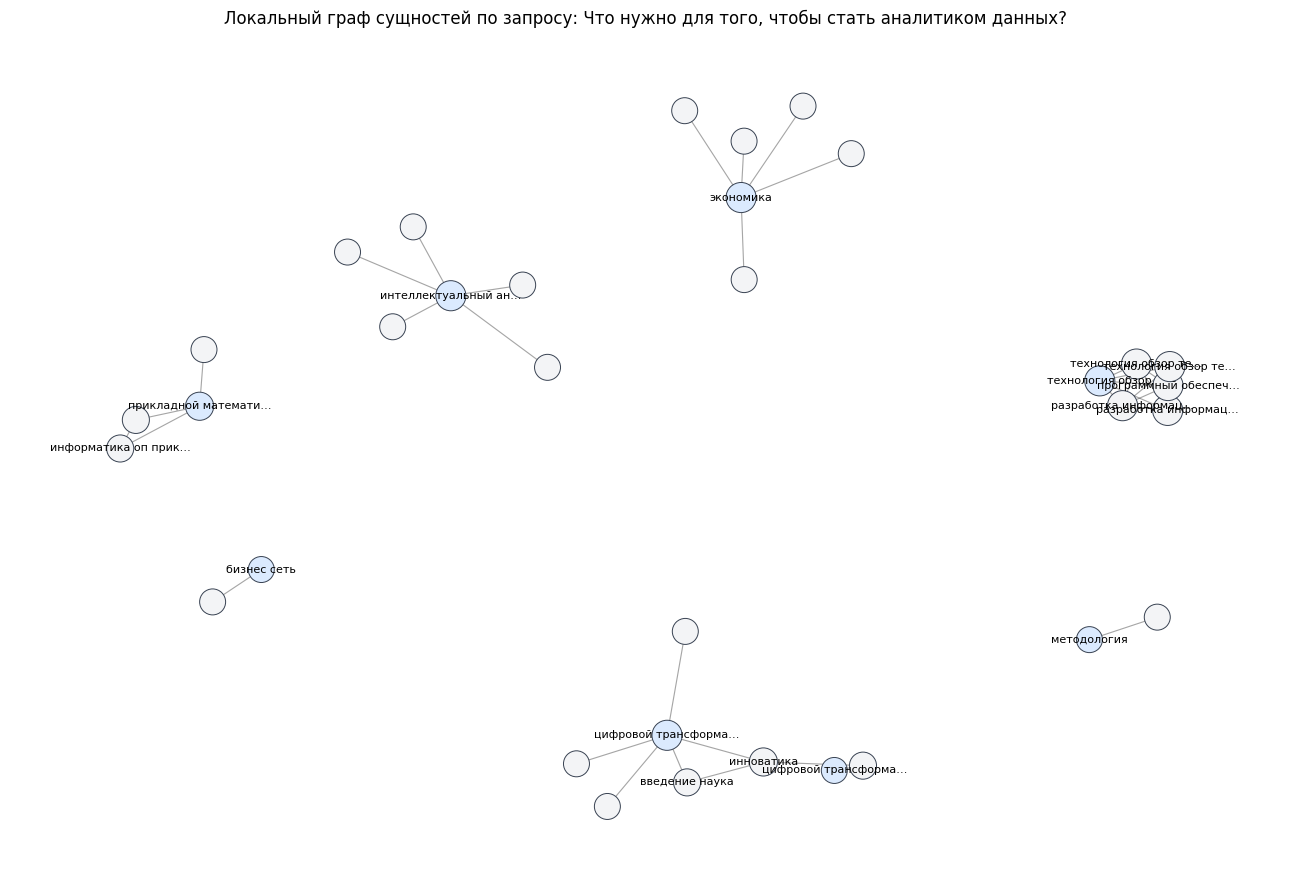

In [ ]:
q = ["Что нужно для того, чтобы стать аналитиком данных?"]
answer_questions(q, is_visualize_graph=True)


Q: Что конкретно мне нужно знать, чтобы перевестись с направления прикладная информатика на направление бизнес-информатика?
AUDIENCE: student
INTENT: general
REASONING MODE: off
ANSWER:
Чтобы перевестись с направления "прикладная информатика" на "бизнес-информатика", вам нужно будет освоить дисциплины, которые входят в программу направления "бизнес-информатика". В частности, вам следует обратить внимание на следующие дисциплины: 1. **Информационные технологии в профессиональной деятельности*-
- эта дисциплина включена в учебный план направления "бизнес-информатика" и поможет вам получить необходимые навыки работы с информационными технологиями. 2. **Производственная практика: преддипломная практика*-
- это практика, которая также входит в программу направления "бизнес-информатика". Она поможет вам применять теоретические знания на практике. 3. **Информационно-технологическая инфраструктура организации*-
- эта дисциплина также входит в программу направления "бизнес-информатика" и помож

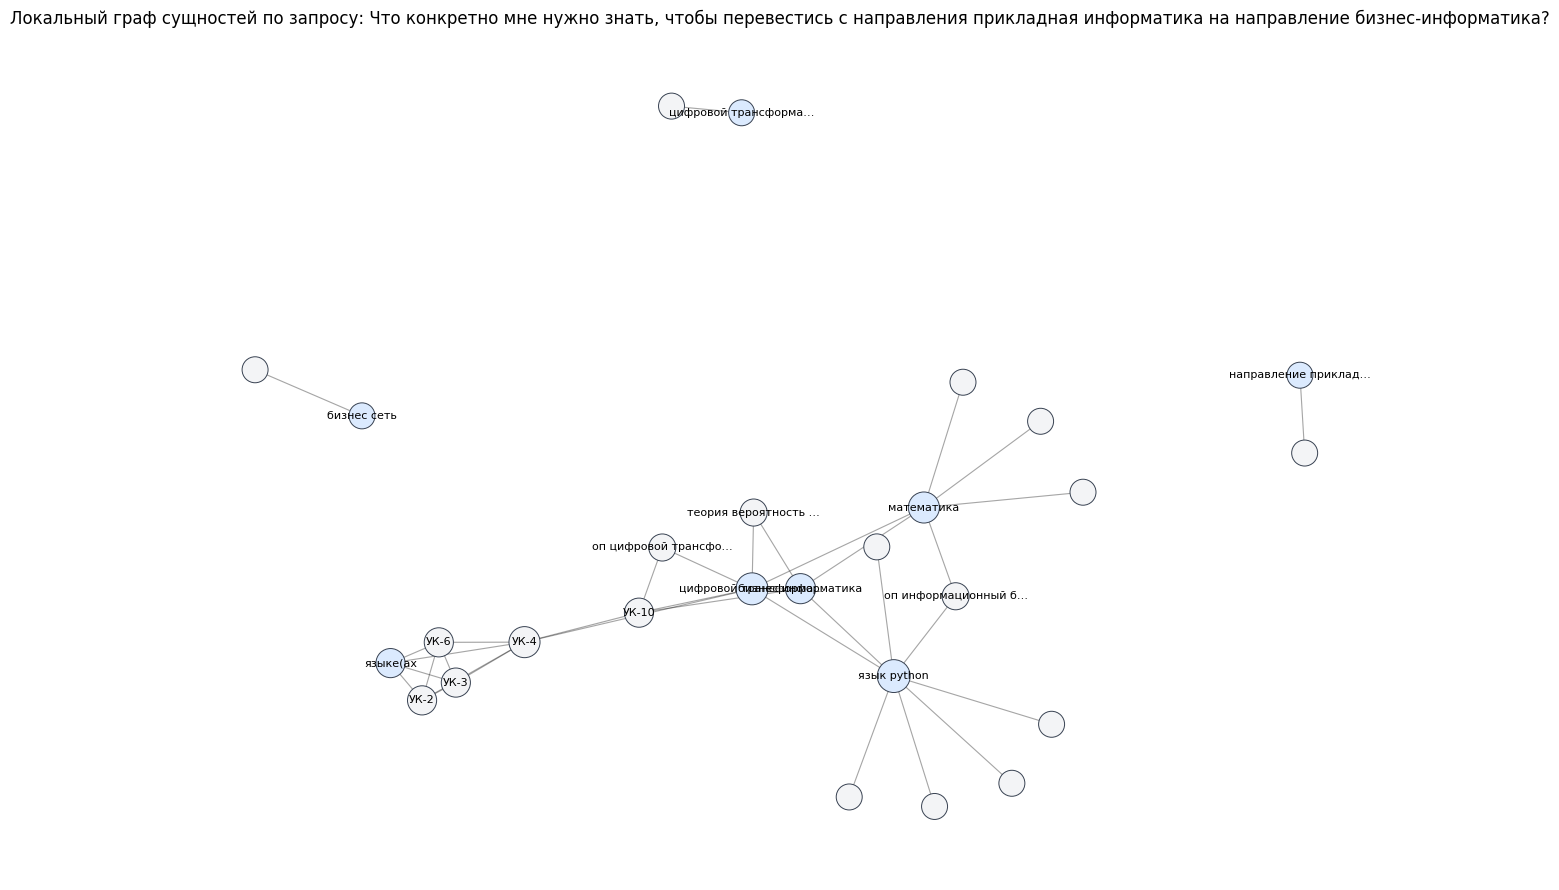

In [ ]:
q = ["Что конкретно мне нужно знать, чтобы перевестись с направления прикладная информатика на направление бизнес-информатика?"]
answer_questions(q, is_visualize_graph=True)


Q: Какие ключевые методы изучаются на технологиях глубокого обучения?
AUDIENCE: student
INTENT: general
REASONING MODE: off
ANSWER:
На курсе глубокого обучения изучаются ключевые методы, такие как персептрон, обратное распространение ошибки, регуляризация, инициализация весов, функции активации и схемы оптимизации. Также обсуждаются современные техники глубокого обучения, такие как автоматическое дифференцирование, минибатчи, инициализация Ксавье, архитектуры модуля LSTM и модели CBOW в Word2Vec. Кроме того, в курсе рассматриваются основы построения моделей ИНС в PyTorch, а также различные методы машинного обучения и глубокого обучения в обнаружении объектов и сегментации изображений.
CITATIONS:
{"id": "1bfe36c7-3dc5-45da-bd8f-047b5d39b7df", "doc_id": "Глубокое обучение, 2021.docx", "title": "6. 2. Перечень вопросов, заданий, тем для подготовки к текущему контролю", "score": 0.016666666666666666, "is_table": false, "meta": {"path": "Глубокое обучение, 2021.docx", "section_path": ["6. 

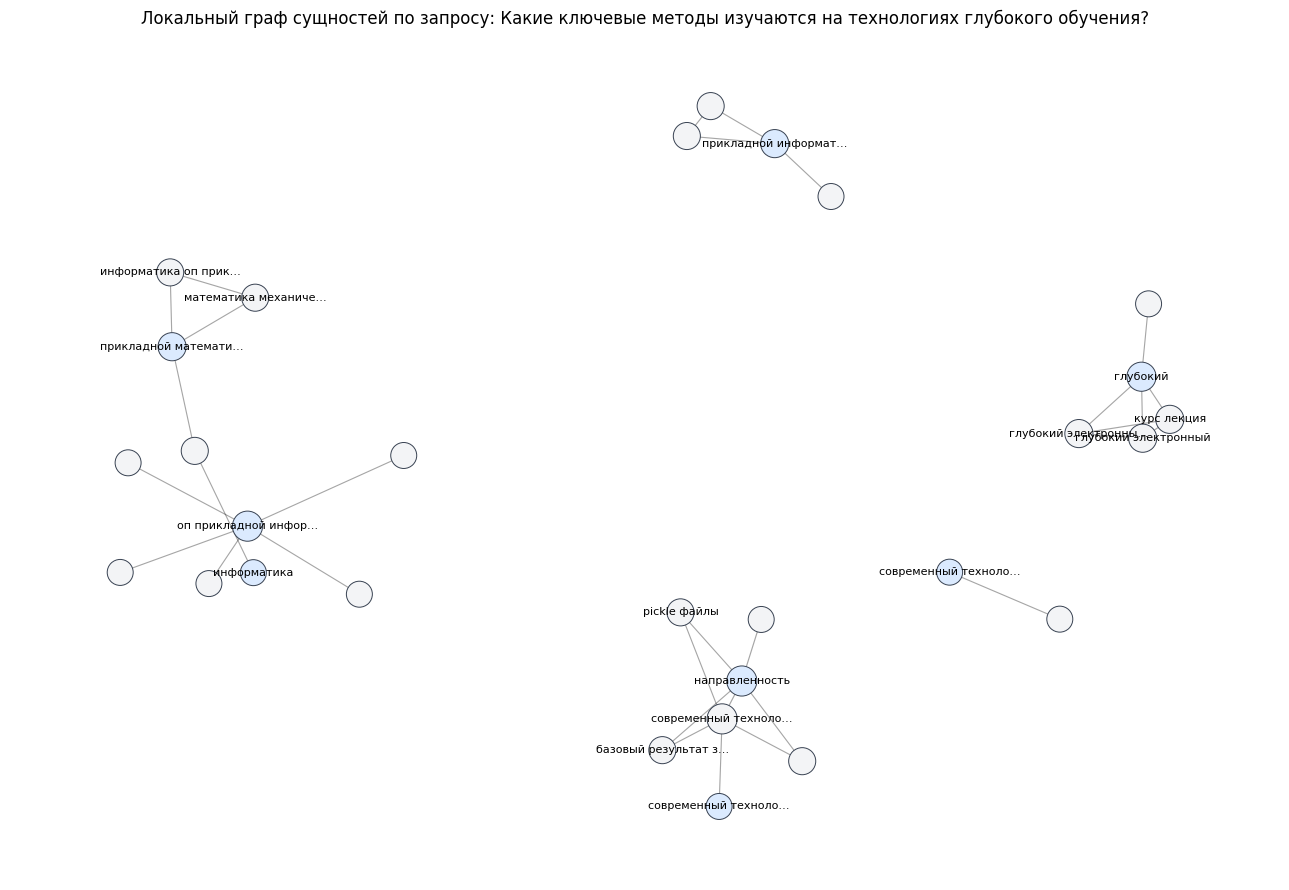

In [ ]:
q = ["Какие ключевые методы изучаются на технологиях глубокого обучения?"]
answer_questions(q, is_visualize_graph=True)